In [ ]:
To do list:
ESM2 server
PTM-mamba server:
DisoFlag server:

# 1.	14-3-3 binding Proteins Show Distinct Properties in Biomolecular Condensates and Phase Separation

task 1: compiled a dataset of known 14-3-3 docking sites and proteins (Table 1), collect an independent dataset, which have not been seen by previous model. 

In [1]:
# download the dataset (bioinformatics_31_14_2276_s1.zip)used in 14-3-3-pre
# https://academic.oup.com/bioinformatics/article/31/14/2276/254687#supplementary-data
# bioinformatics_31_14_2276_s1.zip
import zipfile
import os

# Define the zip file name and the folder to extract to
zip_file_name = 'data/bioinformatics_31_14_2276_s1.zip'
extract_folder = 'data/bioinformatics_31_14_2276_s1'

# Check if the folder exists, if not, create it
if not os.path.exists(extract_folder):
    os.makedirs(extract_folder)

# Open the zip file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    # Extract all the contents into the specified folder
    zip_ref.extractall(extract_folder)

print(f'Extracted {zip_file_name} into {extract_folder}')

Extracted data/bioinformatics_31_14_2276_s1.zip into data/bioinformatics_31_14_2276_s1


In [2]:
# download the dataset (NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx) used in 14-3-3 finder
# https://pmc.ncbi.nlm.nih.gov/articles/PMC10099770/#SM1
# save as NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx

In [3]:
# to establish a independent dataset, we will extract the data point in the dataset (20240518final_merge_data_with_high_1433pre_mapped_to_human.csv) but not 14-3-3 pred and 14-3-3 finder dataset
import pandas as pd
pred_dataset_name = 'data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx'
finder_dataset_name = "data/NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx"
curated_dataset_name = "data/20240518final_merge_data_with_high_1433pre_mapped_to_human.csv"

In [4]:
# the data in data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx have 4 tab, combine them into one
file_path = pred_dataset_name
excel_file = pd.ExcelFile(file_path)

# Let's get the sheet names
sheet_names = excel_file.sheet_names

# Create an empty list to hold dataframes
dfs = []

# Loop through the sheet names and read each sheet into a dataframe
for sheet in sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    # Optionally, you can add a column indicating the sheet name, useful for tracking the data source
    df['Source_Sheet'] = sheet
    dfs.append(df)

# Concatenate all the dataframes
pred_dataset_df = pd.concat(dfs, ignore_index=True)
pred_dataset_df = pred_dataset_df[pred_dataset_df['PMID'] != '*Likely NEG sites ']
pred_dataset_df = pred_dataset_df[["Uniprot ID","Site","Residue"]]
pred_dataset_df["Site"] = pred_dataset_df["Site"].astype(int)
pred_dataset_df.head(2)

/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Uniprot ID,Site,Residue
0,P78314,225,S
1,P78314,278,S


In [5]:
# 14-3-3 finder dataset preprocess
finder_dataset_df = pd.read_excel(finder_dataset_name)
finder_dataset_df = finder_dataset_df[["Uniprot ID", 'Site',"Residue"]]
finder_dataset_df.head(2)

,Uniprot ID,Site,Residue
0,A7KAX9,1796,S
1,O00159,736,S


In [6]:
import re
previous_datset_df = pd.concat([pred_dataset_df, finder_dataset_df], ignore_index=True)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(str)

# Define the replacement function
def replace_value(value):
    matches = re.findall(r'\(([^)]+)\)', value)    
    if matches:
        return matches[0]  # Replace with the number within parentheses
    else:
        return value


# Apply the function to the 'Site' column
previous_datset_df['Site'] = previous_datset_df['Site'].apply(replace_value)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(int)

# remove duplicates
previous_datset_df = previous_datset_df.drop_duplicates(subset=["Uniprot ID", "Site"], keep='first')

previous_datset_df["uniqueID"] = (
    previous_datset_df["Uniprot ID"].str.strip() + "_" +
    previous_datset_df["Residue"].str.strip().str.upper() +
    previous_datset_df["Site"].astype(str).str.strip() +
    previous_datset_df["Residue"].str.strip().str.lower()
)

# put the uniqueID into a set
uniqueid_dict = set(previous_datset_df["uniqueID"])

has_duplicates = previous_datset_df["uniqueID"].duplicated().any()
print(f"Are there duplicates in column uniqueID? {has_duplicates}")

Are there duplicates in column uniqueID? False


In [7]:
# preprocess the curated dataset
curated_dataset_df = pd.read_csv(curated_dataset_name)
curated_dataset_df["uniqueID"] = (
    curated_dataset_df["human homology accession"].str.strip() + "_" +
    curated_dataset_df['human Site and Mutation'].str.strip()
)
curated_dataset_df = curated_dataset_df.drop_duplicates(subset=["uniqueID"], keep="first")

# save table 1 as the supplement for the paper
table1_df = curated_dataset_df[["human homology accession","human homology site without letter", "human Site and Mutation", "label", "PMID"]]
table1_df.to_csv("data/Table 1.csv", index=False)

In [8]:
independent_dataset_df = curated_dataset_df[~curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
independent_dataset_df["label"].value_counts()

label
0    182
1    181
Name: count, dtype: int64

In [9]:
used_dataset_df =  curated_dataset_df[curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
used_dataset_df["label"].value_counts()

label
0    309
1    276
Name: count, dtype: int64

In [10]:
# we have too much independent data here, some of the indepnedent data will also be used for training.

In [11]:
# check how many of the independent data are come from the mutation of a positive site sample
# those data should be exclude from the training dataset to avoid overfitting
# add more previous not see protein in the training dataset
# independent_dataset_df[independent_dataset_df['uniqueID'].str.contains('/')].head(2)

taks 2: In the curated dataset, we have observed that the proteins containing positive and negative samples largely overlap 

In [12]:
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df.head()

,human homology accession,human homology site without letter,human Site and Mutation,label,PMID
0,P43681,467,S467s,1,20141511
1,P11362,779,S779s,1,23564461
2,P98177,32,T32t,1,20141511
3,P14136,8,S8s,1,20141511
4,P08151,640,S640s,1,20141511


In [13]:
# !conda install conda-forge::matplotlib-venn

Label 0 unique proteins: 153
Label 1 unique proteins: 288
Overlapping proteins: 142


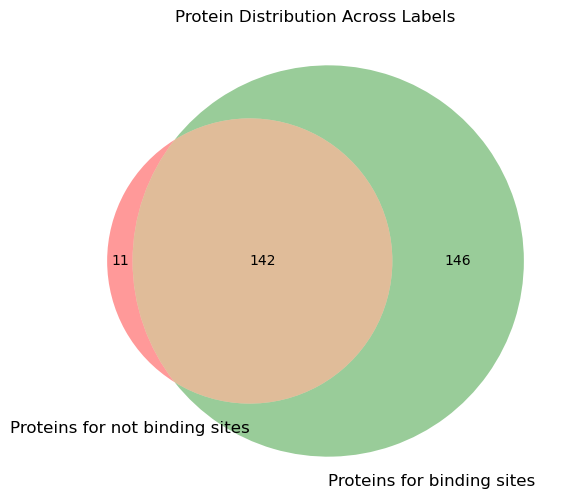

In [14]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import pandas as pd

def plot_protein_venn(df, protein_col='human homology accession', label_col='label'):
    # Get sets of proteins for each label
    label_0_proteins = set(df[df[label_col] == 0][protein_col])
    label_1_proteins = set(df[df[label_col] == 1][protein_col])
    
    # Create Venn diagram
    plt.figure(figsize=(10, 6))
    venn2([label_0_proteins, label_1_proteins], 
          set_labels=('Proteins for not binding sites', 'Proteins for binding sites'))
    plt.title('Protein Distribution Across Labels')
    
    # Display counts
    print(f"Label 0 unique proteins: {len(label_0_proteins)}")
    print(f"Label 1 unique proteins: {len(label_1_proteins)}")
    print(f"Overlapping proteins: {len(label_0_proteins.intersection(label_1_proteins))}")
    
    plt.show()
    
plot_protein_venn(curated_dataset_df, protein_col='human homology accession', label_col='label')

In [15]:
import pandas as pd

# Load the dataset
curated_dataset_df = pd.read_csv("data/Table 1.csv")

# Filter the dataset to include only positive labels
curated_dataset_df_positive = curated_dataset_df[curated_dataset_df["label"] == 1]

# Group by "human homology accession" and calculate the count of each unique protein ID
protein_counts = curated_dataset_df_positive.groupby("human homology accession").size().reset_index(name='count')

protein_counts["count"].value_counts()

count
1    166
2     88
3     24
4      7
5      3
Name: count, dtype: int64

task 3: we curated a dataset from BioGrid (ref), which collected all 14-3-3 binding proteins reported in the literature. 

In [16]:
# 1.1 get all the human protein which interaction with 14-3-3

# download protein protein interaction dataset from Biogrid
# Read the tab-separated file into a DataFrame

file_path = "data/BIOGRID-ALL-4.4.237.mitab.zip"

biogrid = pd.read_csv(file_path, delimiter='\t', encoding='utf-8')

# Display the DataFrame
biogrid.head(2)

,#ID Interactor A,ID Interactor B,Alt IDs Interactor A,Alt IDs Interactor B,Aliases Interactor A,Aliases Interactor B,Interaction Detection Method,Publication 1st Author,Publication Identifiers,Taxid Interactor A,Taxid Interactor B,Interaction Types,Source Database,Interaction Identifiers,Confidence Values
0,entrez gene/locuslink:6416,entrez gene/locuslink:2318,biogrid:112315|entrez gene/locuslink:MAP2K4|un...,biogrid:108607|entrez gene/locuslink:FLNC|unip...,entrez gene/locuslink:JNKK(gene name synonym)|...,entrez gene/locuslink:ABP-280(gene name synony...,"psi-mi:""MI:0018""(two hybrid)",Marti A (1997),pubmed:9006895,taxid:9606,taxid:9606,"psi-mi:""MI:0407""(direct interaction)","psi-mi:""MI:0463""(biogrid)",biogrid:103,-
1,entrez gene/locuslink:84665,entrez gene/locuslink:88,biogrid:124185|entrez gene/locuslink:MYPN|unip...,biogrid:106603|entrez gene/locuslink:ACTN2|uni...,entrez gene/locuslink:CMD1DD(gene name synonym...,entrez gene/locuslink:CMD1AA(gene name synonym),"psi-mi:""MI:0018""(two hybrid)",Bang ML (2001),pubmed:11309420,taxid:9606,taxid:9606,"psi-mi:""MI:0407""(direct interaction)","psi-mi:""MI:0463""(biogrid)",biogrid:117,-


In [17]:
# select all the interaction happening between human proteins
biogrid = biogrid[(biogrid['Taxid Interactor A'] == "taxid:9606")&(biogrid['Taxid Interactor B'] == "taxid:9606")]
import pandas as pd
import re
def extract_and_clean_uniprot_id(text):
    # Regex pattern to match 'uniprot/swiss-prot:P45985'
    match = re.search(r'uniprot/swiss-prot:([\w\d]+)', text)
    return match.group(1) if match else None
# Apply the function to the DataFrame columns

biogrid['Uniprot ID A'] = biogrid['Alt IDs Interactor A'].apply(extract_and_clean_uniprot_id)
biogrid['Uniprot ID B'] = biogrid['Alt IDs Interactor B'].apply(extract_and_clean_uniprot_id)
biogrid_interactions = biogrid[['Uniprot ID A','Uniprot ID B']]
biogrid_interactions.head(2)

,Uniprot ID A,Uniprot ID B
0,P45985,Q14315
1,Q86TC9,P35609


In [18]:
Protins_1433 = ["P62258", "P27348", "Q04917", "P61981", "P31946", "P31947", "P63104"]
Protein_1433_interactome_df = biogrid_interactions[biogrid_interactions["Uniprot ID A"].isin(Protins_1433)]
Protein_1433_interactome = set(Protein_1433_interactome_df["Uniprot ID B"])
len(Protein_1433_interactome)

1760

In [19]:
# there are totally 1760 human protein interaction with human 14-3-3s

In [20]:
# save the 1433_interactome as a dataset

task 4: Using Gene Ontology (GO) analysis, we discovered that these proteins are associated with several GO terms related to condensation, including non-membrane-bounded organelles 

In [21]:
df = pd.read_csv("data/Table 1.csv")
df_1433 = df[df["label"]==1]
Protein_1433_interactome_known_motif = set(df_1433["human homology accession"]) 
len(Protein_1433_interactome_known_motif)

288

In [22]:
# Gene Ontology (GO) analysis
# # Install gprofiler-official
# !pip install gprofiler-official

In [23]:
from gprofiler import GProfiler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to transform p-values to -log10(p-value)
def transform_pvalues(df):
    df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
    return df

def go_analysis(uniprot_ids):
    # Initialize g:Profiler
    gp = GProfiler(return_dataframe=True)

    # Convert UniProt IDs to Gene Symbols (using g:Convert)
    converted_ids = gp.convert(organism='hsapiens', query=uniprot_ids, target_namespace='ENTREZGENE_ACC')

    # Extract the gene symbols
    gene_symbols = converted_ids['converted'].tolist()
#     print("Converted Gene Symbols:", gene_symbols)

    # Perform GO enrichment analysis using the converted gene symbols
    BP_go_results = gp.profile(organism='hsapiens', query=gene_symbols, sources=['GO:BP'])
    MF_go_results = gp.profile(organism='hsapiens', query=gene_symbols, sources=['GO:MF'])
    CC_go_results = gp.profile(organism='hsapiens', query=gene_symbols, sources=['GO:CC'])

    # Display results
#     print(go_results.head())

    # Optional: Visualize the top 10 GO terms
    import matplotlib.pyplot as plt
    import seaborn as sns
    
#     print(BP_go_results)
    # Select top terms
    BP_top_go_terms = BP_go_results.head(20)
    MF_top_go_terms = MF_go_results.head(20)
    CC_top_go_terms = CC_go_results.head(20)

    # Transform p-values to -log10(p-value)
    BP_top_go_terms = transform_pvalues(BP_top_go_terms)
    MF_top_go_terms = transform_pvalues(MF_top_go_terms)
    CC_top_go_terms = transform_pvalues(CC_top_go_terms)

    # Combine data into a single DataFrame
    BP_top_go_terms['Category'] = 'Biological Process'
    MF_top_go_terms['Category'] = 'Molecular Function'
    CC_top_go_terms['Category'] = 'Cellular Component'

    combined_df = pd.concat([BP_top_go_terms, MF_top_go_terms, CC_top_go_terms])

    # Create a plot
    plt.figure(figsize=(14, 12))

    # Create a bar plot with custom width
    sns.barplot(
        data=combined_df,
        y='name',
        x='-log10(p-value)',
        hue='Category',
        palette={'Biological Process': 'skyblue', 'Molecular Function': 'lightgreen', 'Cellular Component': 'salmon'},
        dodge=False  # This ensures that bars are not split by hue
    )

    # Adjust bar width by setting the aspect ratio
    plt.gca().set_aspect('auto', adjustable='box')

    # Title and labels
    plt.title('Top GO Terms by Category')
    plt.xlabel('-log10(p-value)')
    plt.ylabel('GO Term')

#     # Invert y-axis
#     plt.gca().invert_yaxis()

    # Add a legend
    plt.legend(title='GO Category')

    # Show the plot
    plt.tight_layout()
    plt.show()

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/431369735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/431369735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
/var/folders/jl/gnkp_hvs3zqb957750yc

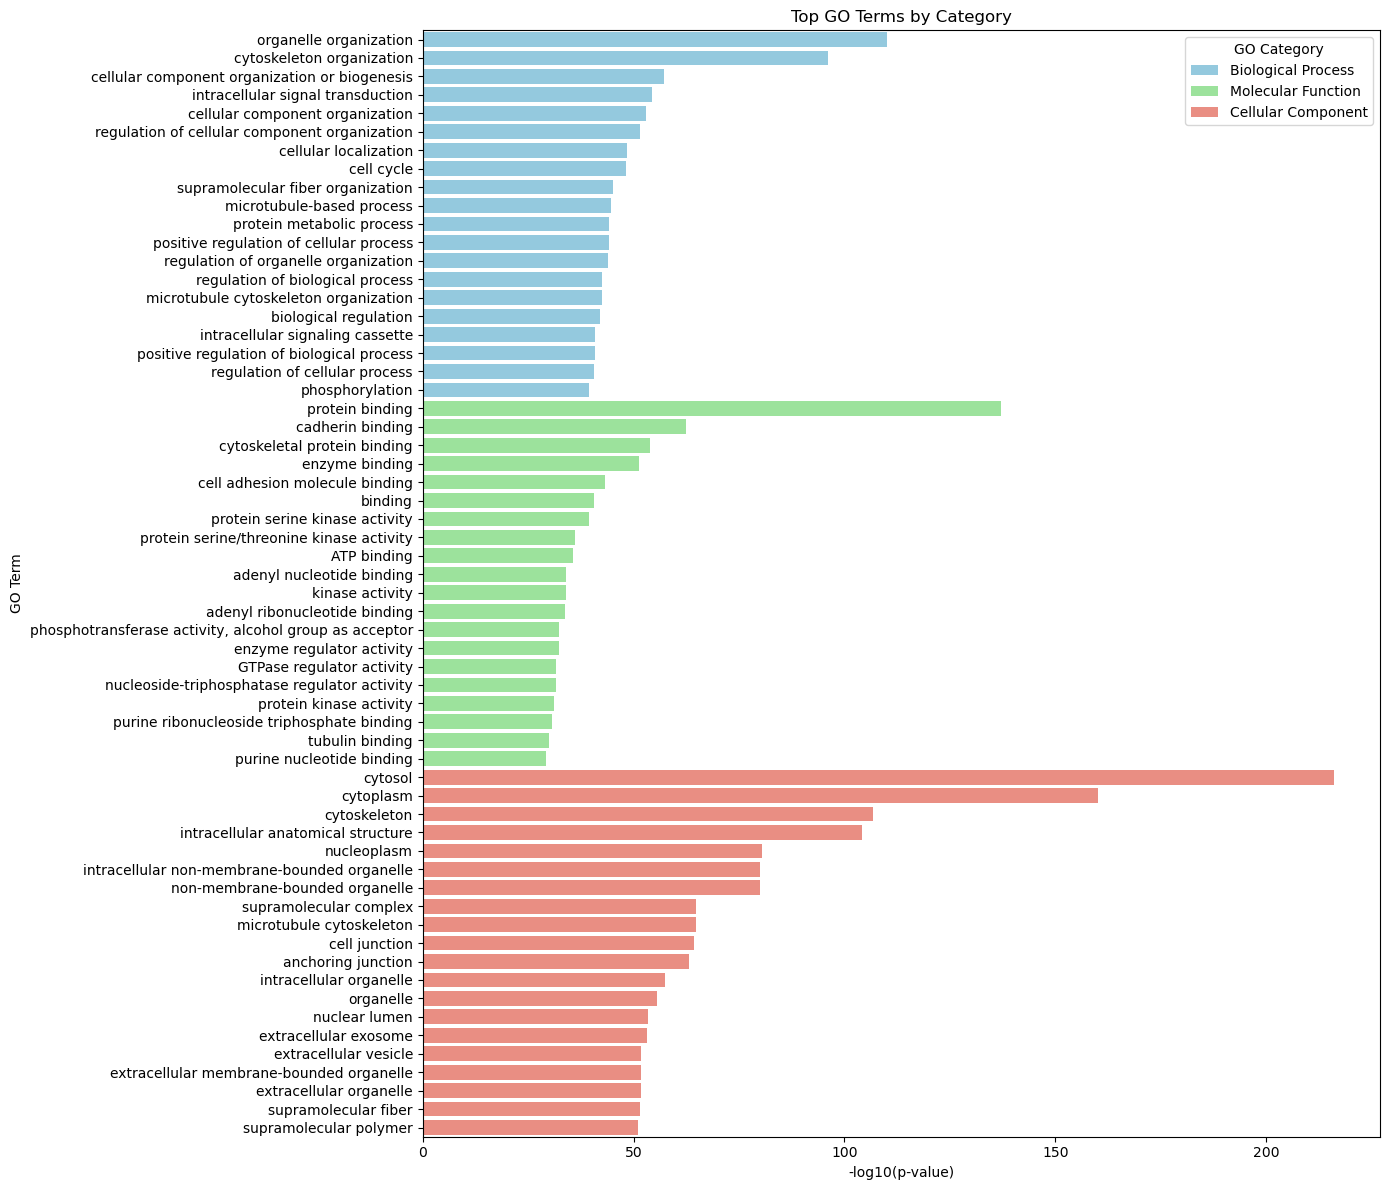

In [24]:
go_analysis(list(Protein_1433_interactome))

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/431369735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/431369735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
/var/folders/jl/gnkp_hvs3zqb957750yc

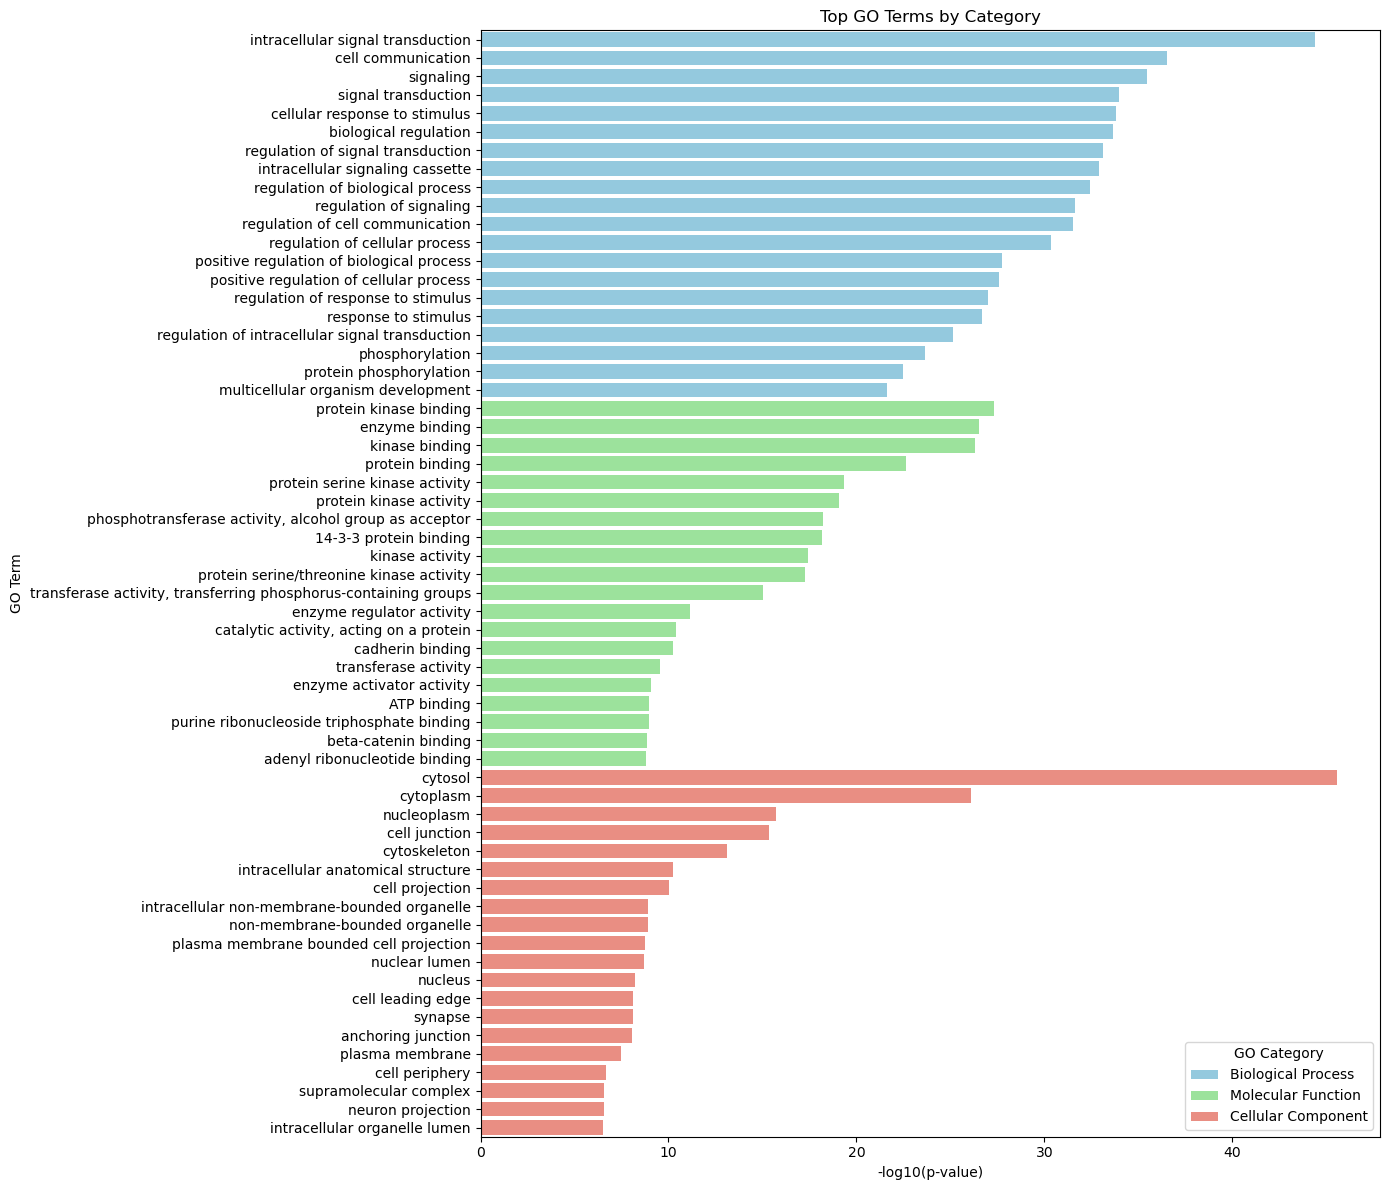

In [25]:
go_analysis(list(Protein_1433_interactome_known_motif))

task 5: We also performed KEGG analysis of 14-3-3 binding proteins and BioGrid 14-3-3 binding proteins to support the above analysis. 

In [26]:
# Initialize GProfiler
gp = GProfiler(return_dataframe=True)

# Perform enrichment for your own proteins and BioGrid proteins separately
results_my_proteins = gp.profile(
    organism='hsapiens',  # Homo sapiens. Change based on your organism.
    query=list(Protein_1433_interactome_known_motif),
    sources=['KEGG'])  # Specify to use KEGG pathways

# Ensure the results are DataFrame
if not isinstance(results_my_proteins, pd.DataFrame):
    raise TypeError('Expected the results of my_proteins to be a DataFrame.')

results_biogrid_proteins = gp.profile(
    organism='hsapiens',
    query=list(Protein_1433_interactome),
    sources=['KEGG'])

# Ensure the results are DataFrame
if not isinstance(results_biogrid_proteins, pd.DataFrame):
    raise TypeError('Expected the results of biogrid_proteins to be a DataFrame.')
    

# Function to convert list columns to strings
def convert_list_columns_to_string(df, columns):
    for col in columns:
        if col in df.columns and df[col].apply(lambda x: isinstance(x, list)).any():
            df[col] = df[col].apply(lambda x: ','.join(map(str, x)) if isinstance(x, list) else x)
    return df

# Columns to convert
columns_to_convert = ['native', 'parents']

# Convert list columns to strings in both DataFrames
results_my_proteins = convert_list_columns_to_string(results_my_proteins, columns_to_convert)
results_biogrid_proteins = convert_list_columns_to_string(results_biogrid_proteins, columns_to_convert)

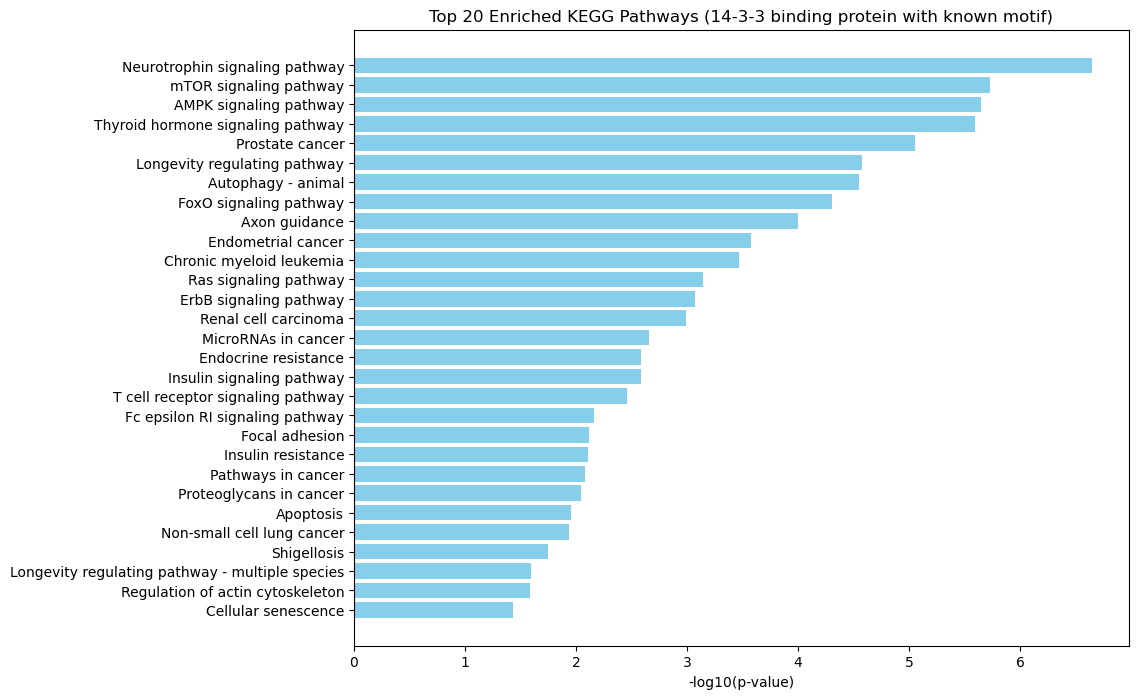

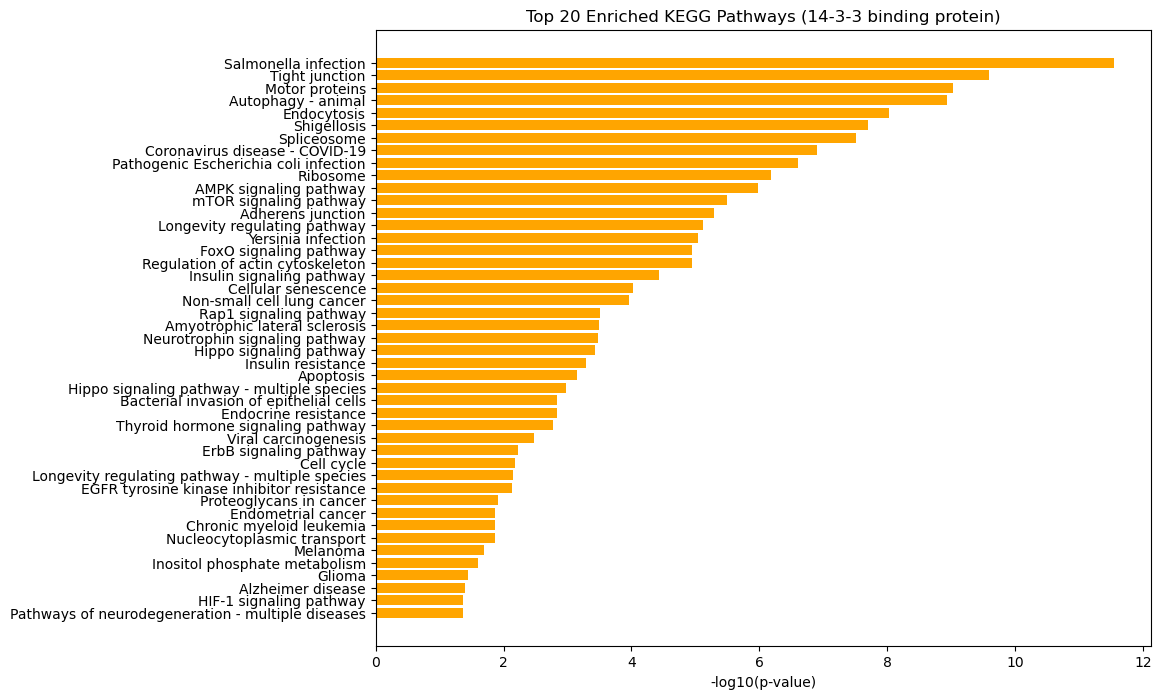

In [27]:
# Select top pathways based on adjusted p-value
top_my_proteins = results_my_proteins.sort_values(by='p_value').head(50)
top_biogrid_proteins = results_biogrid_proteins.sort_values(by='p_value').head(50)

# Plot the results for my_proteins
plt.figure(figsize=(10, 8))
plt.barh(top_my_proteins['name'], -np.log10(top_my_proteins['p_value']), color='skyblue')
plt.xlabel('-log10(p-value)')
plt.title('Top 20 Enriched KEGG Pathways (14-3-3 binding protein with known motif)')
plt.gca().invert_yaxis()
plt.show()

# Plot the results for biogrid_proteins
plt.figure(figsize=(10, 8))
plt.barh(top_biogrid_proteins['name'], -np.log10(top_biogrid_proteins['p_value']), color='orange')
plt.xlabel('-log10(p-value)')
plt.title('Top 20 Enriched KEGG Pathways (14-3-3 binding protein)')
plt.gca().invert_yaxis()
plt.show()

In [28]:
# common pathway in 14-3-3 binding and 14-3-3 binding with known motif dataset
set(top_my_proteins['name'])&set(top_biogrid_proteins['name'])

{'AMPK signaling pathway',
 'Apoptosis',
 'Autophagy - animal',
 'Cellular senescence',
 'Chronic myeloid leukemia',
 'Endocrine resistance',
 'Endometrial cancer',
 'ErbB signaling pathway',
 'FoxO signaling pathway',
 'Insulin resistance',
 'Insulin signaling pathway',
 'Longevity regulating pathway',
 'Longevity regulating pathway - multiple species',
 'Neurotrophin signaling pathway',
 'Non-small cell lung cancer',
 'Proteoglycans in cancer',
 'Regulation of actin cytoskeleton',
 'Shigellosis',
 'Thyroid hormone signaling pathway',
 'mTOR signaling pathway'}

task 6/7: 

## Analysis of Protein Condensation Potential and Phase Separation Properties

taks 8: download the predicted condensation score from Picnic(ref), DeePhase(ref), and PhaSePred(ref) 

In [29]:
# download picnic data from https://picnic.cd-code.org/download/
# get the picnic value for each unique id
df_picnic = pd.read_csv('data/PICNIC-9606-data.csv')
df_picnic.head()

,ID,PICNIC score,PICNIC GO score,Uniprot ID,Proteins,Genes,Organism,Organism ID,CD-Code included
0,A0A024R1R8,0.851484,0.771362,A0A024R1R8,Translation machinery-associated protein 7 (Co...,LOC112268293 hCG_2014768,Homo sapiens (Human),9606,False
1,A0A024RBG1,0.689599,0.770870,A0A024RBG1,Diphosphoinositol polyphosphate phosphohydrola...,NUDT4B,Homo sapiens (Human),9606,False
2,A0A024RCN7,0.026301,NaN,A0A024RCN7,"Chromosome 6 open reading frame 48, isoform CR...",SNHG32 C6orf48 hCG_43697,Homo sapiens (Human),9606,False
3,A0A075B6H5,0.179640,0.240242,A0A075B6H5,T cell receptor beta variable 20/OR9-2 (non-fu...,TRBV20OR9-2,Homo sapiens (Human),9606,False
4,A0A075B6H7,0.038747,0.070939,A0A075B6H7,Probable non-functional immunoglobulin kappa v...,IGKV3-7,Homo sapiens (Human),9606,False


In [30]:
# download DeePhase dataset
# import pandas as pd
# import requests
# import os

# # URL of the raw file
# url = 'https://github.com/kadiliissaar/DeePhase/raw/main/Paper_code/Predictions/Swissprot/all_predictions.csv'

# # Define the filename and the path to save it
# filename = 'all_predictions.csv'
# save_path = os.path.join('data', filename)

# # Create the 'data' directory if it does not exist
# os.makedirs('data', exist_ok=True)

# # Download the file
# response = requests.get(url)
# response.raise_for_status()  # Ensure we notice bad responses

# # Save the content of the response to a file in the data directory
# with open(save_path, 'wb') as f:
#     f.write(response.content)

# print(f"Downloaded file: {save_path}")

# Read the CSV file into a DataFrame
df_DeePhase = pd.read_csv('data/all_predictions.csv')

# Display the first few rows of the DataFrame
df_DeePhase.head()

,prediction_phys_1,Sequence,Uniprot_ID,Category,prediction_phys_2,prediction_phys_multi,prediction_w2v_1,prediction_w2v_2,prediction_w2v_multi
0,0.20,MESNHKSGDGLSGTQKEAALRALVQRTGYSLVQENGQRKYGGPPPG...,Q9NQ94,Swiss-Prot,0.31,0.237093,0.562697,0.700156,0.529143
1,0.04,MWAQLLLGMLALSPAIAEELPNYLVTLPARLNFPSVQKVCLDLSPG...,A8K2U0,Swiss-Prot,0.45,0.105490,0.558333,0.732476,0.574357
2,0.00,MASTVEGGDTALLPEFPRGPLDAYRARASFSWKELALFTEGEGMLR...,O15254,Swiss-Prot,0.25,0.057632,0.464045,0.570464,0.372309
3,0.26,MEQDWQPGEEVTPGPEPCSKGQAPLYPIVHVTELKHTDPNFPSNSN...,P86434,Swiss-Prot,0.32,0.418428,0.582418,0.357474,0.518784
4,0.64,MVSRMVSTMLSGLLFWLASGWTPAFAYSPRTPDRVSEADIQRLLHG...,P05408,Swiss-Prot,0.34,0.584225,0.142324,0.423652,0.214775


In [31]:
# PhaSePred
# ### download the dataset    
# import pandas as pd
# import requests
# import os

# # URL of the raw file
# url = 'http://predict.phasep.pro/static/phasepred/database/human_reviewed.zip'

# # Define the filename and the path to save it
# zip_filename = 'human_reviewed.zip'
# save_path = os.path.join('data', zip_filename)

# # Create the 'data' directory if it does not exist
# os.makedirs('data', exist_ok=True)

# # Download the file
# response = requests.get(url)
# response.raise_for_status()  # Ensure we notice bad responses

# # Save the content of the response to a file in the data directory
# with open(save_path, 'wb') as f:
#     f.write(response.content)

# print(f"Downloaded file: {save_path}")

In [32]:
# human_reviewed.zip is a json file
import zipfile
import json
import pandas as pd
import os

# Specify the path to your zip file and the output directory
zip_file_path = 'data/human_reviewed.zip'

import pandas as pd
import json
from collections import defaultdict

def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

def process_data(data):
    flattened_data = defaultdict(dict)
    
    for key, value in data.items():
        flat = flatten_dict(value)
        for k, v in flat.items():
            flattened_data[k][key] = v
    
    return pd.DataFrame(flattened_data)


# Define the output directory (can be the same directory as the zip file or any other)
output_directory = os.path.splitext(zip_file_path)[0]  # This will remove the .zip extension

#
print(output_directory)

# Ensure the output directory exists
os.makedirs(output_directory, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_directory)

# Read JSON file
json_file_path = os.path.join(output_directory, 'human_reviewed.json')  # adjust according to your actual file name

with open(json_file_path, 'r') as file:
    data = json.load(file)

# Process the data and create DataFrame
df_PhaSePred = process_data(data)

# Display the first few rows of the DataFrame
df_PhaSePred.head()

data/human_reviewed


,Entry name,Status,Gene names,Organism,Sequence,catGRANULE_residue,catGRANULE_single,catGRANULE_start,catGRANULE_end,catGRANULE_rnk,...,PhaSePred_SaPS-10fea,PhaSePred_PdPS-10fea,PhaSePred_SaPS-8fea_rnk,PhaSePred_PdPS-8fea_rnk,PhaSePred_SaPS-10fea_rnk,PhaSePred_PdPS-10fea_rnk,InterPro_PfamID,InterPro_domain,InterPro_start,InterPro_end
Q9H553,ALG2_HUMAN,reviewed,ALG2 UNQ666/PRO1298,Homo sapiens (Human),MAEEQGRERDSVPKPSVLFLHPDLGVGGAERLVLDAALALQARGCS...,"-5.0075,-4.3359,-3.8836,-3.6662,-3.655,-3.6775...",-0.131076,[],[],0.298061,...,0.068929,0.099901,0.156564,0.200098,0.426748,0.433865,"[PF13439, PF00534]","[Glycosyltransferase subfamily 4-like, N-termi...","[26, 216]","[189, 392]"
Q96QF7,ACRC_HUMAN,reviewed,GCNA ACRC,Homo sapiens (Human),MDGCKKELPRLQEPEEDEDCYILNVQSSSDDTSGSSVARRAPKRQA...,"-6.6667,-6.0269,-5.7194,-5.5569,-5.4324,-5.405...",1.051820,"[140, 172, 449, 522]","[159, 222, 505, 535]",0.906454,...,0.213236,0.362276,0.871264,0.967362,0.742773,0.705521,[PF10263],[SprT-like],[523],[625]
Q13023,AKAP6_HUMAN,reviewed,AKAP6 AKAP100 KIAA0311,Homo sapiens (Human),MLTMSVTLSPLRSQDLDPMATDASPMAINMTPTVEQGEGEEAMKDM...,"-10.7361,-9.8149,-9.053,-8.5031,-8.1557,-7.901...",1.161600,"[388, 477, 496, 533, 1040, 1247, 1340, 1362, 1...","[404, 482, 528, 539, 1051, 1255, 1358, 1367, 1...",0.932613,...,0.066812,0.316707,0.882012,0.753521,0.395730,0.675387,[],[],[],[]
Q8WTP8,AEN_HUMAN,reviewed,AEN ISG20L1 SBBI58,Homo sapiens (Human),MVPREAPESAQCLCPSLTIPNAKDVLRKRHKRRSRQHQRFMARKAL...,"-9.7623,-8.8363,-8.1812,-7.8205,-7.6766,-7.821...",-0.002401,[],[],0.357791,...,0.055431,0.056909,0.647067,0.497129,0.199951,0.300761,[PF00929],"[Exonuclease, RNase T/DNA polymerase III]",[111],[266]
Q7Z7M1,AGRD2_HUMAN,reviewed,ADGRD2 GPR144 PGR24,Homo sapiens (Human),MDAPWGAGERWLHGAAVDRSGVSLGPPPTPQVNQGTLGPQVAPVAA...,"-1.3081,-0.3783,0.5501,1.3293,1.6232,1.6099,1....",-0.033896,"[29, 214]","[43, 266]",0.343411,...,0.071706,0.030409,0.379828,0.041178,0.458552,0.054577,"[PF01825, PF00354, PF00002]","[GPS motif, Pentraxin-related, GPCR, family 2,...","[611, 136, 657]","[642, 305, 897]"


In [33]:
df_PhaSePred.columns

Index(['Entry name', 'Status', 'Gene names', 'Organism', 'Sequence',
       'catGRANULE_residue', 'catGRANULE_single', 'catGRANULE_start',
       'catGRANULE_end', 'catGRANULE_rnk', 'PLAAC_residue', 'PLAAC_NLLR',
       'PLAAC_start', 'PLAAC_end', 'PLAAC_rnk', 'PScore_residue',
       'PScore_single', 'PScore_start', 'PScore_end', 'PScore_rnk',
       'ESpritz-DisProt_residue', 'ESpritz-DisProt_label',
       'ESpritz-DisProt_single', 'ESpritz-DisProt_start',
       'ESpritz-DisProt_end', 'ESpritz-DisProt_rnk', 'Hydropathy_residue',
       'Hydropathy_single', 'Hydropathy_start', 'Hydropathy_end',
       'Hydropathy_rnk', 'DeepCoil_coiled-coil', 'DeepCoil_sharpen',
       'DeepCoil_single', 'DeepCoil_start', 'DeepCoil_end', 'SEG_label',
       'SEG_single', 'SEG_start', 'SEG_end', 'SEG_rnk',
       'Charged residue_label', 'Charged residue_FCR',
       'Charged residue_POS_pos', 'Charged residue_POS_neg',
       'Charged residue_rnk', 'Phos_Phos', 'Phos_POS', 'Phos_single',
       'Pho

In [34]:
score_columns = ['uniprot_id','Sequence',
                 'catGRANULE_single','PLAAC_NLLR',
       'PScore_single', 
       'ESpritz-DisProt_single',
       'Hydropathy_single',
       'DeepCoil_single',
       'SEG_single',
       'Charged residue_FCR', 'Phos_single','PhaSePred_SaPS-8fea', 'PhaSePred_PdPS-8fea',
       'PhaSePred_SaPS-10fea', 'PhaSePred_PdPS-10fea',
       'PhaSePred_SaPS-8fea_rnk', 'PhaSePred_PdPS-8fea_rnk',
       'PhaSePred_SaPS-10fea_rnk', 'PhaSePred_PdPS-10fea_rnk']

df_PhaSePred['uniprot_id'] = df_PhaSePred.index

df_PhaSePred = df_PhaSePred[score_columns]

task 9: predict the condensation propensity of 14-3-3 binding proteins and compared with entire proteome condensation propensities. 
task 10: comparison of the condensation propensity scores of proteins in BioGrid dataset with proteins in the human proteome 

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def distribution_go(gene_list, listname, df, score, ID):
    # Filter scores for the specific list of genes
    df_list_genes = df[df[ID].isin(gene_list)]
    
    # Create a figure with a specific style
    plt.figure(figsize=(16, 9))
    sns.set_style("whitegrid")
    
    # Plot the score distribution for the entire gene set
    sns.histplot(df[score], color='#FFA07A', label='Whole Human Proteome', 
                 kde=True, bins=40, alpha=0.6, stat='density')
    
    # Plot the score distribution for the specific list of genes
    sns.histplot(df_list_genes[score], color='#4682B4', label=listname, 
                 kde=True, bins=40, stat='density')
    
    # Title and labels with improved fonts
    plt.title(f'Score Distribution: {listname} vs Whole Human Proteome', 
              fontsize=20, fontweight='bold', pad=20)
    plt.xlabel(score, fontsize=14, fontweight='bold')
    plt.ylabel('Density', fontsize=14, fontweight='bold')
    
    # Improve tick labels
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Add a legend with improved appearance
    plt.legend(fontsize=12, loc='upper right', frameon=True, framealpha=0.9)
    
    # Add a text box with statistics
    stats_text = f"{listname} stats:\nMean: {df_list_genes[score].mean():.2f}\nMedian: {df_list_genes[score].median():.2f}"
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Improve layout and display
    plt.tight_layout()
    plt.show()

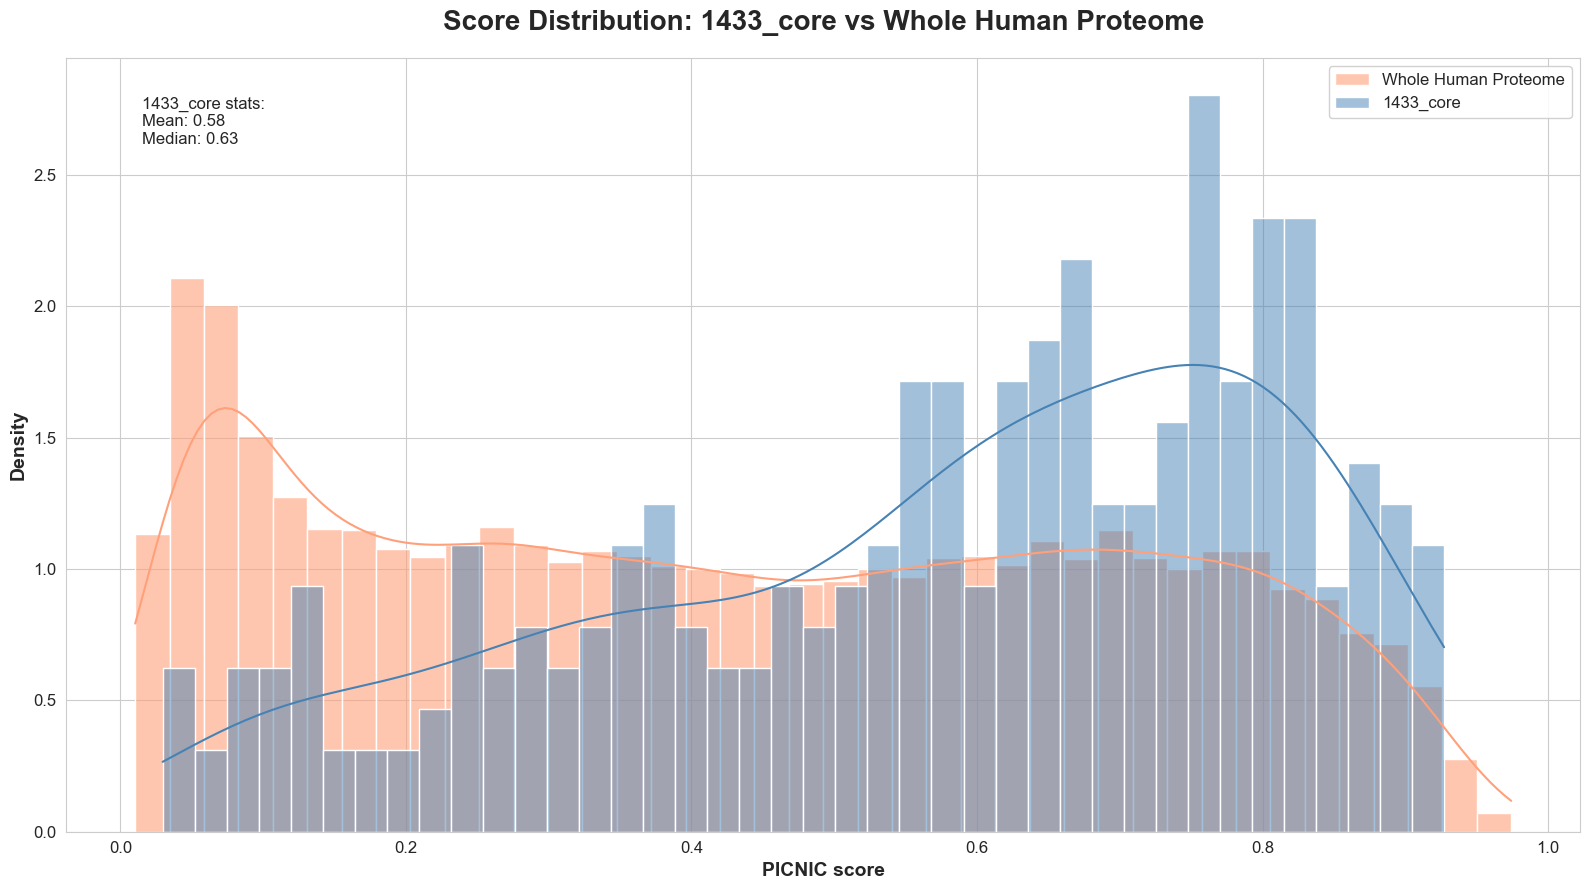

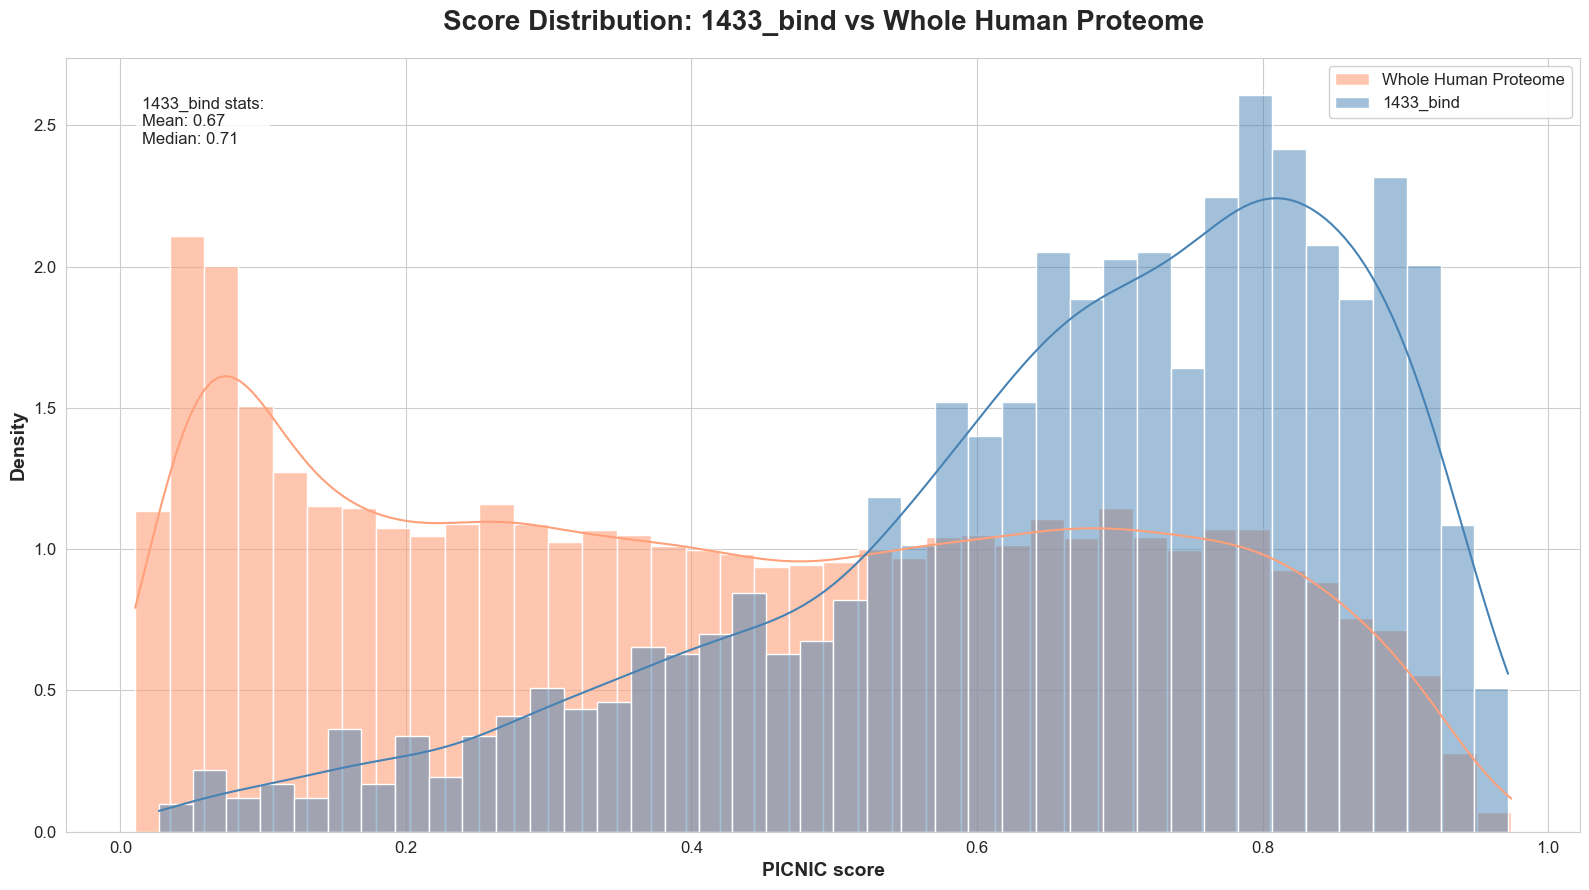

In [36]:
# picnic score
# two score using here: Picnic socre and picnic go score
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_picnic,"PICNIC score", 'Uniprot ID')
distribution_go(Protein_1433_interactome,"1433_bind",df_picnic, "PICNIC score", 'Uniprot ID')

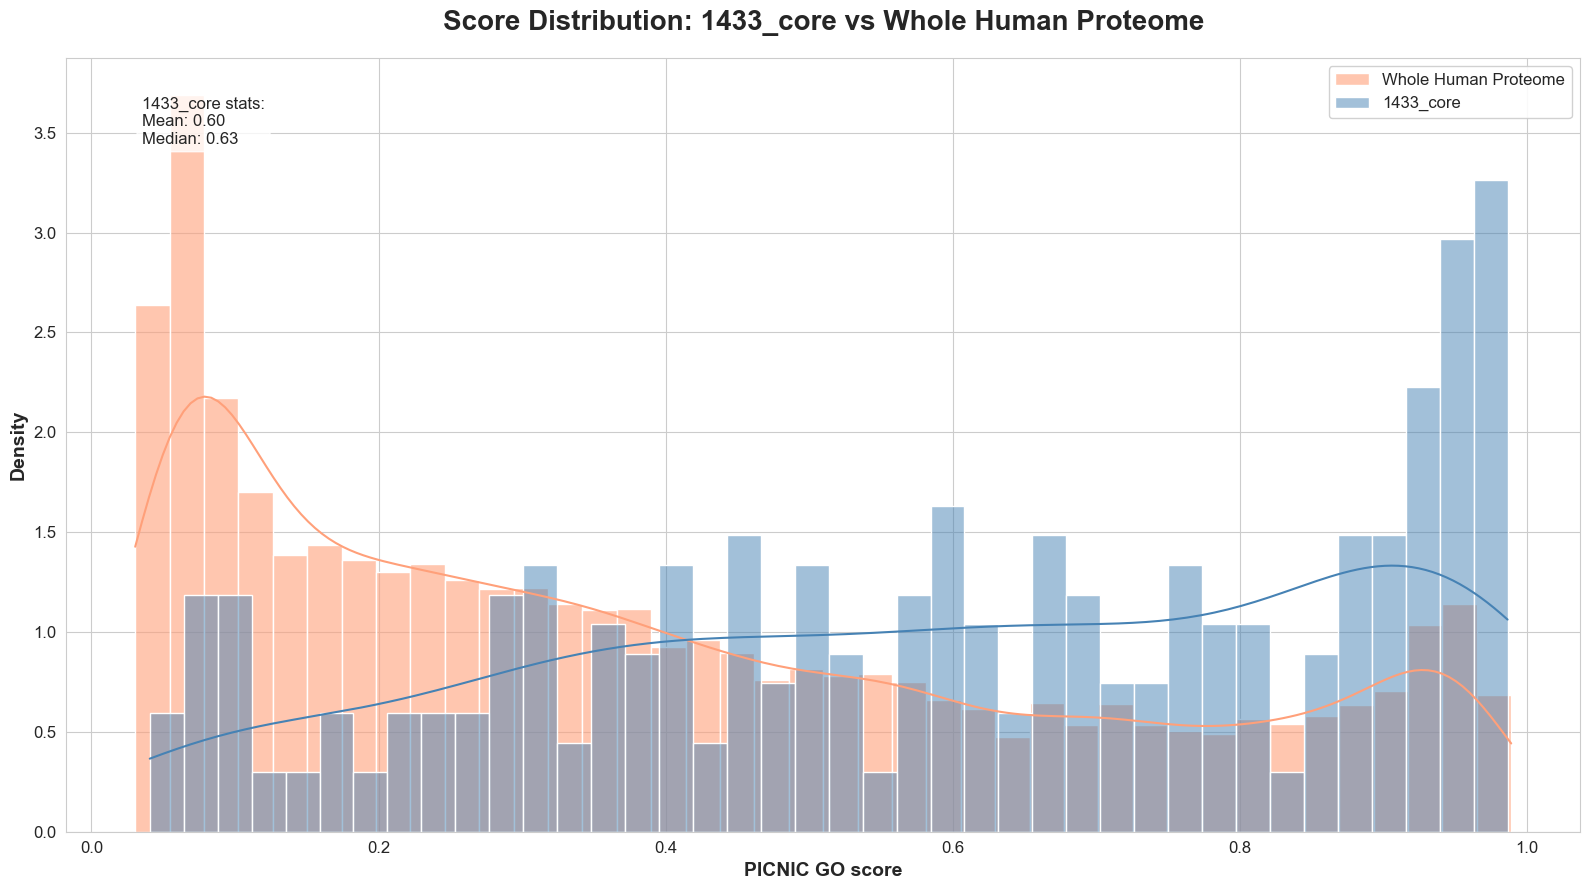

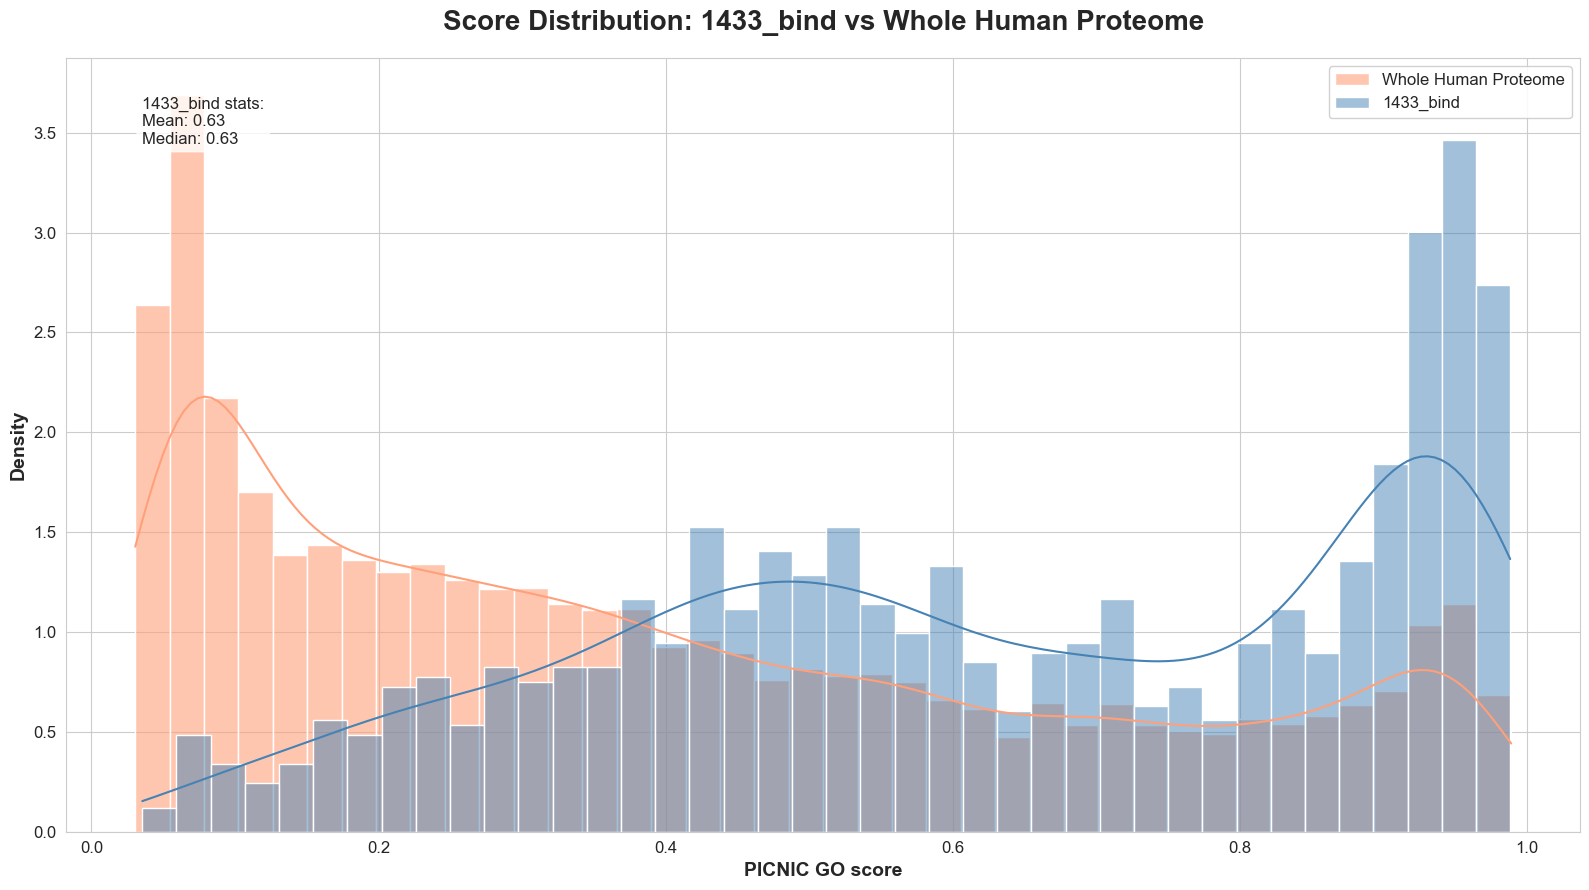

In [37]:
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_picnic,"PICNIC GO score", 'Uniprot ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_picnic, "PICNIC GO score", 'Uniprot ID')

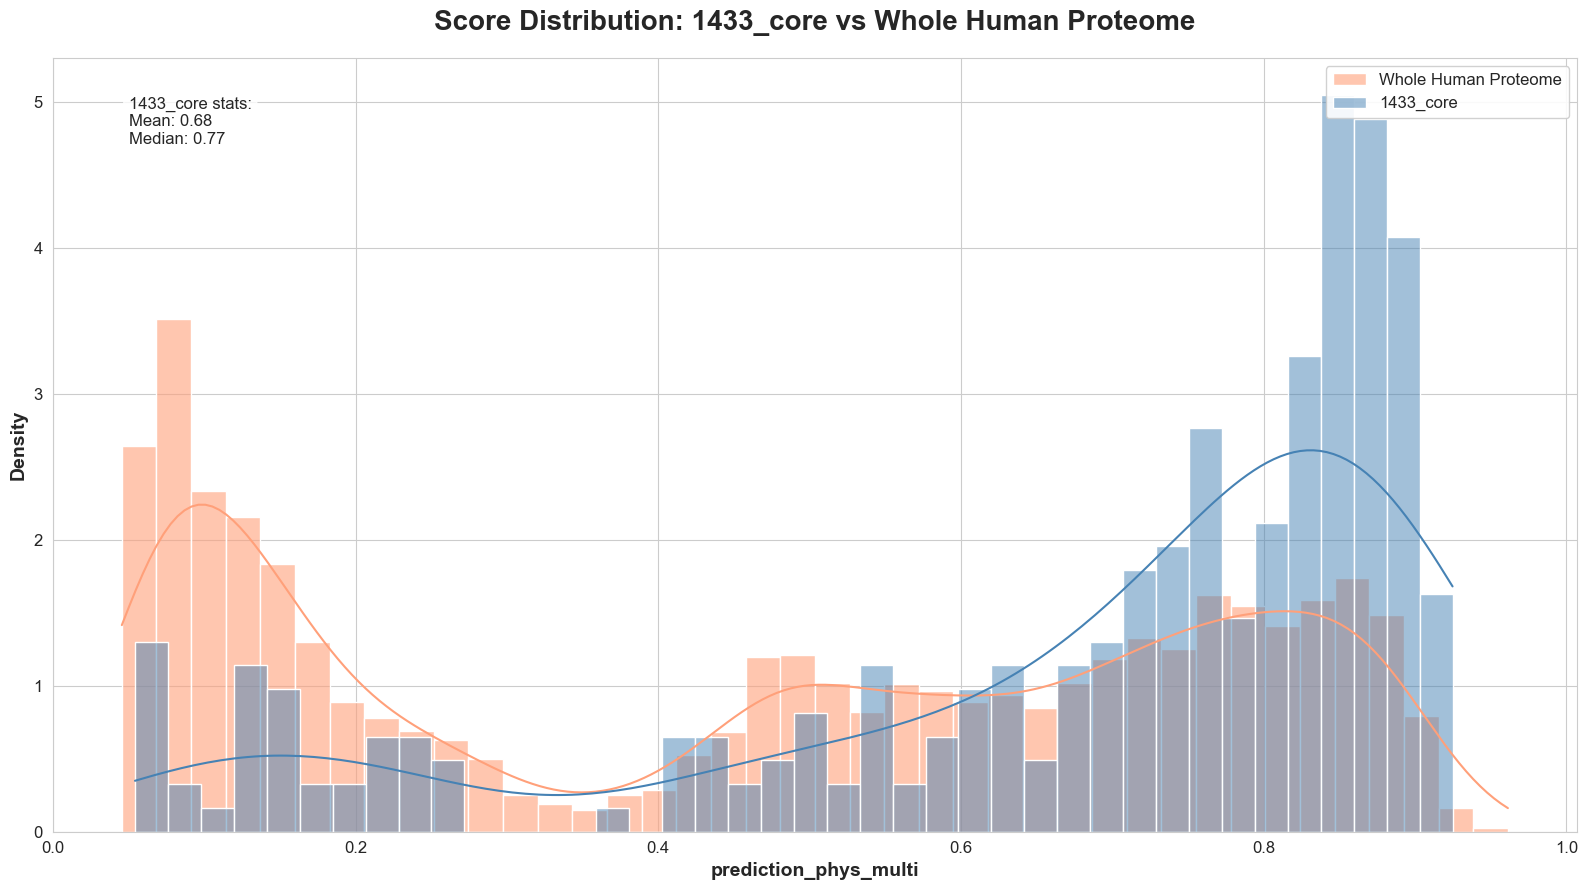

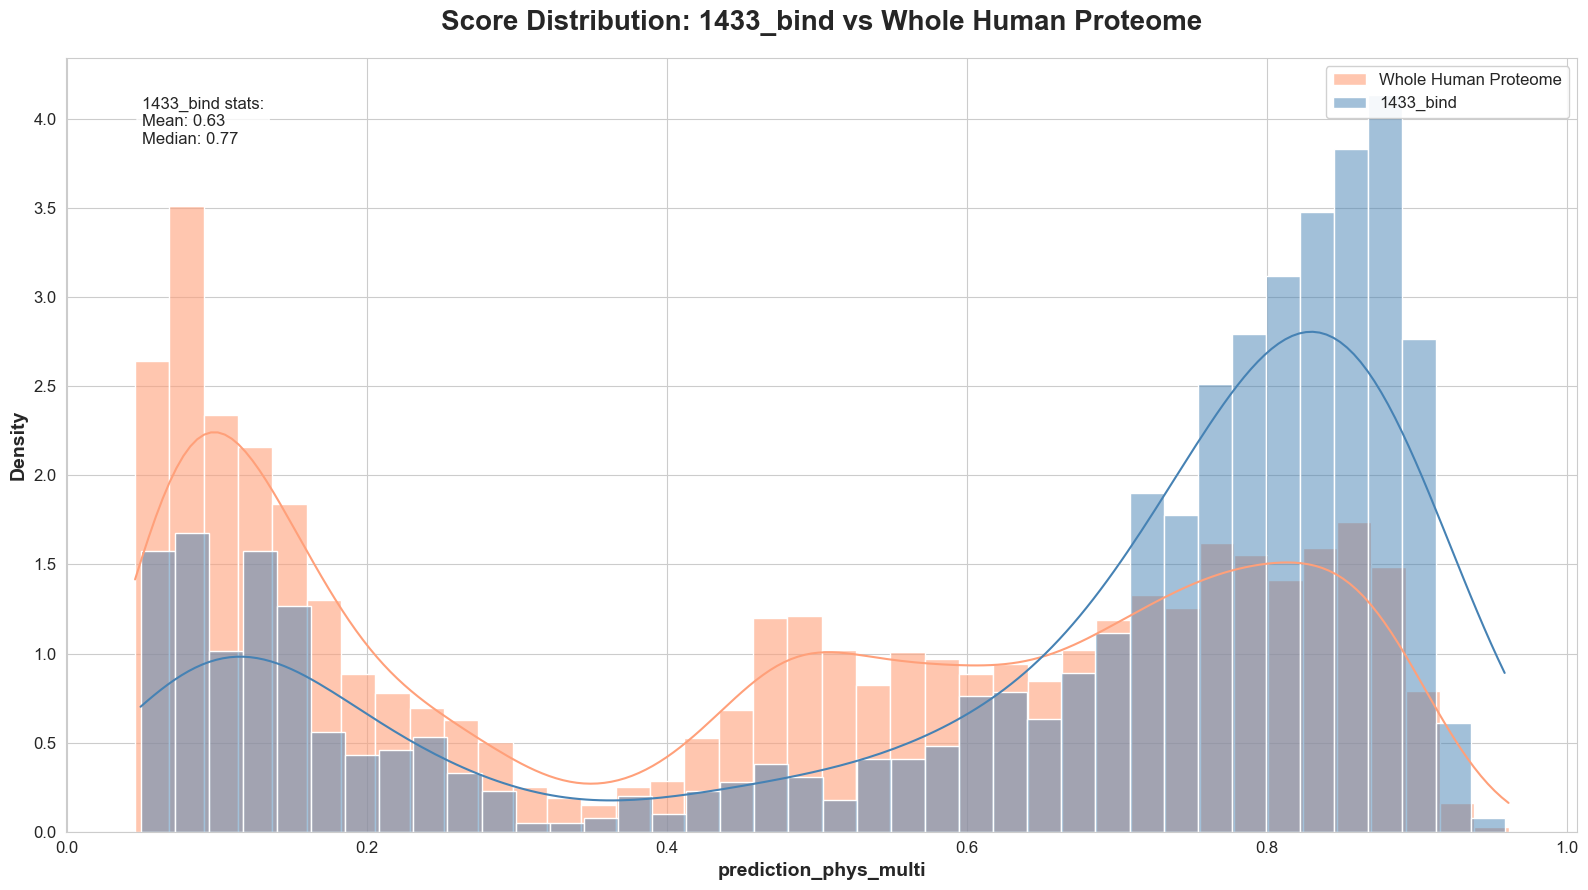

In [38]:
# deephase score
# two score using here: prediction_phys_multi socre and prediction_w2v_multi score
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_DeePhase,"prediction_phys_multi", 'Uniprot_ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_DeePhase,"prediction_phys_multi", 'Uniprot_ID')

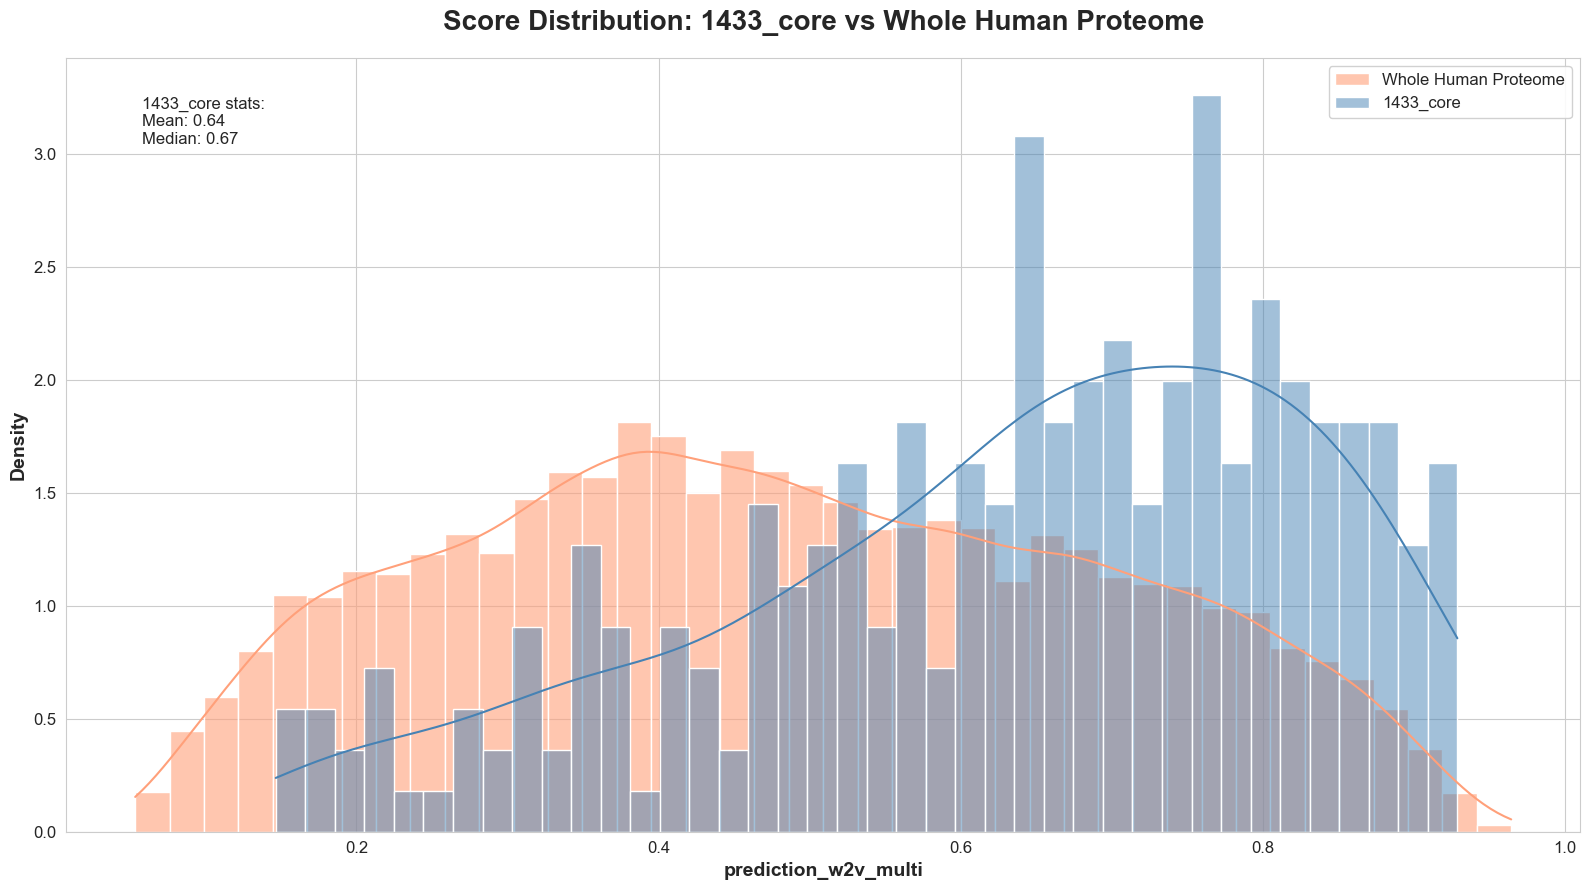

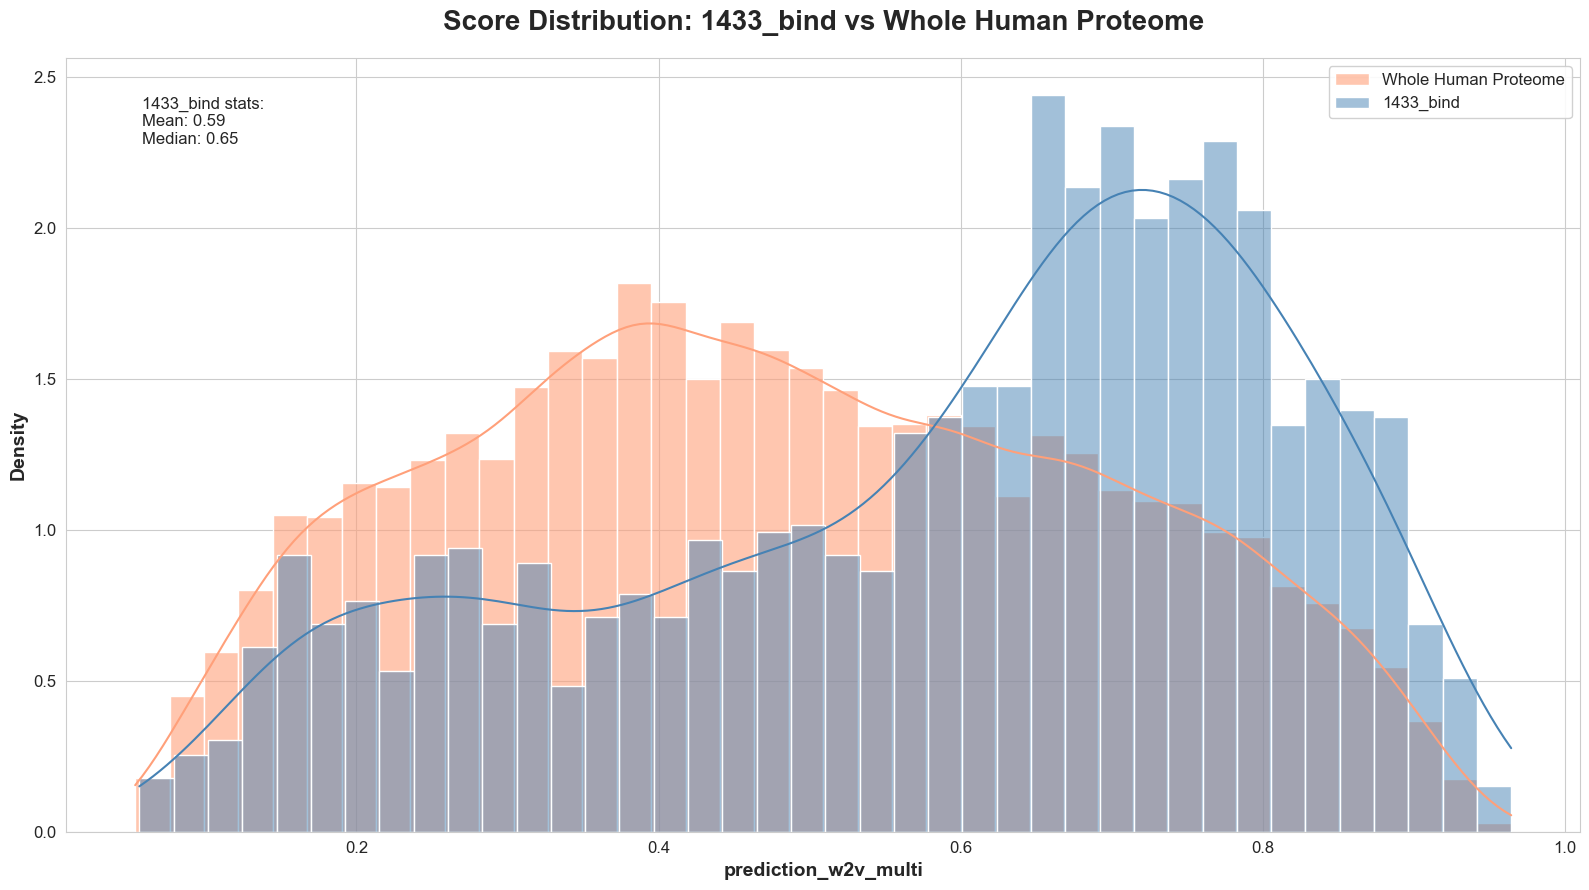

In [39]:
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_DeePhase,"prediction_w2v_multi", 'Uniprot_ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_DeePhase,"prediction_w2v_multi", 'Uniprot_ID')

In [40]:
# PhaSePred score
# a list score using here
phasepred_score_columns = ['PhaSePred_SaPS-8fea', 'PhaSePred_PdPS-8fea','PhaSePred_SaPS-10fea', 'PhaSePred_PdPS-10fea',
       'PhaSePred_SaPS-8fea_rnk', 'PhaSePred_PdPS-8fea_rnk',
       'PhaSePred_SaPS-10fea_rnk', 'PhaSePred_PdPS-10fea_rnk']

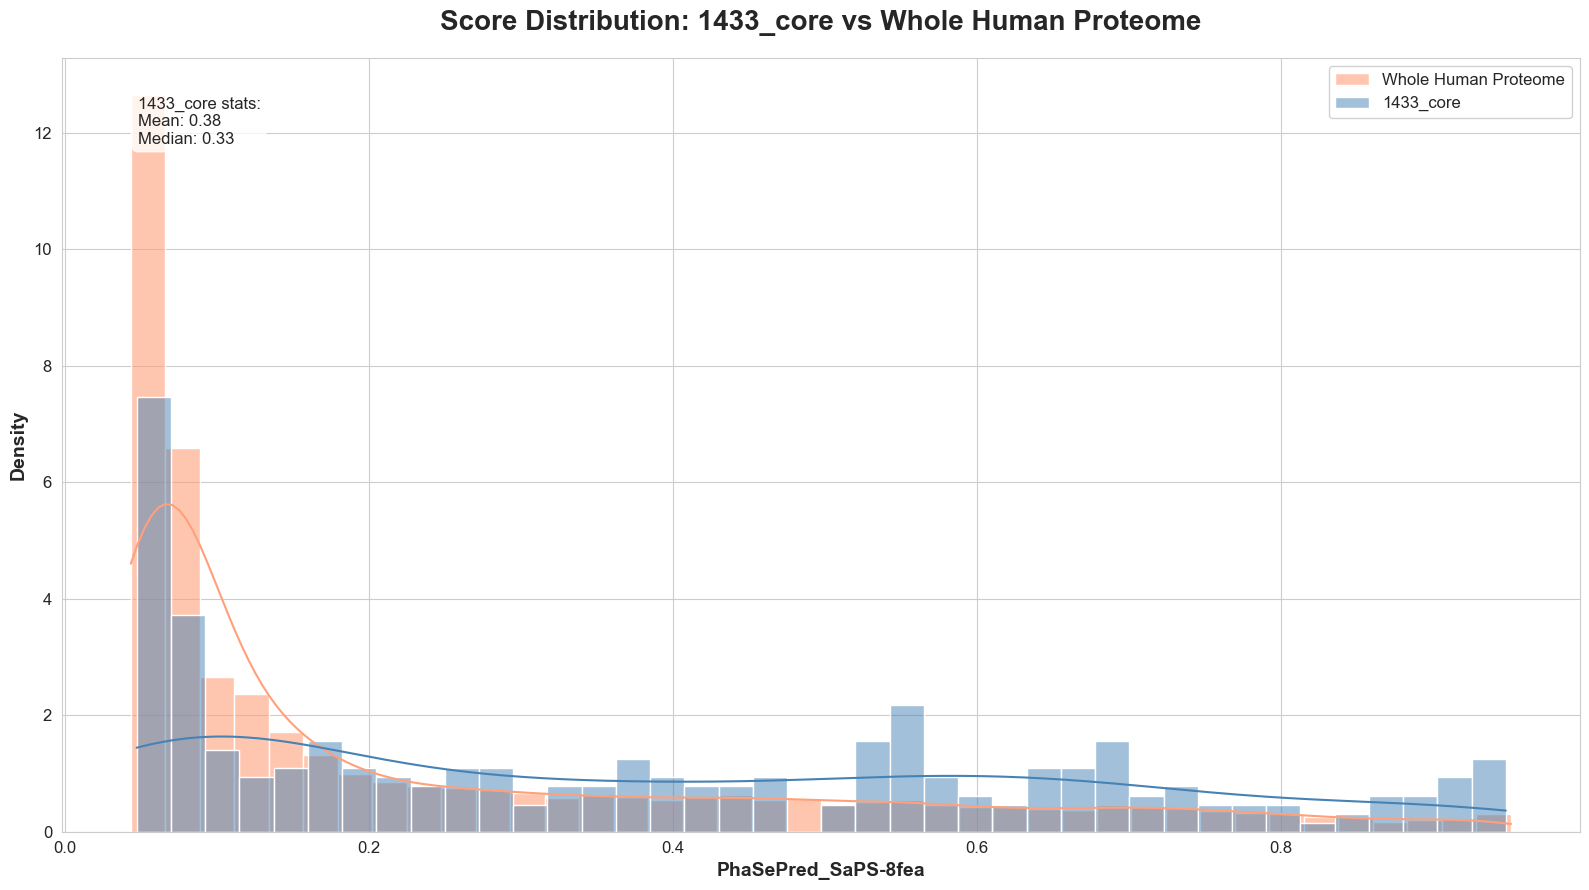

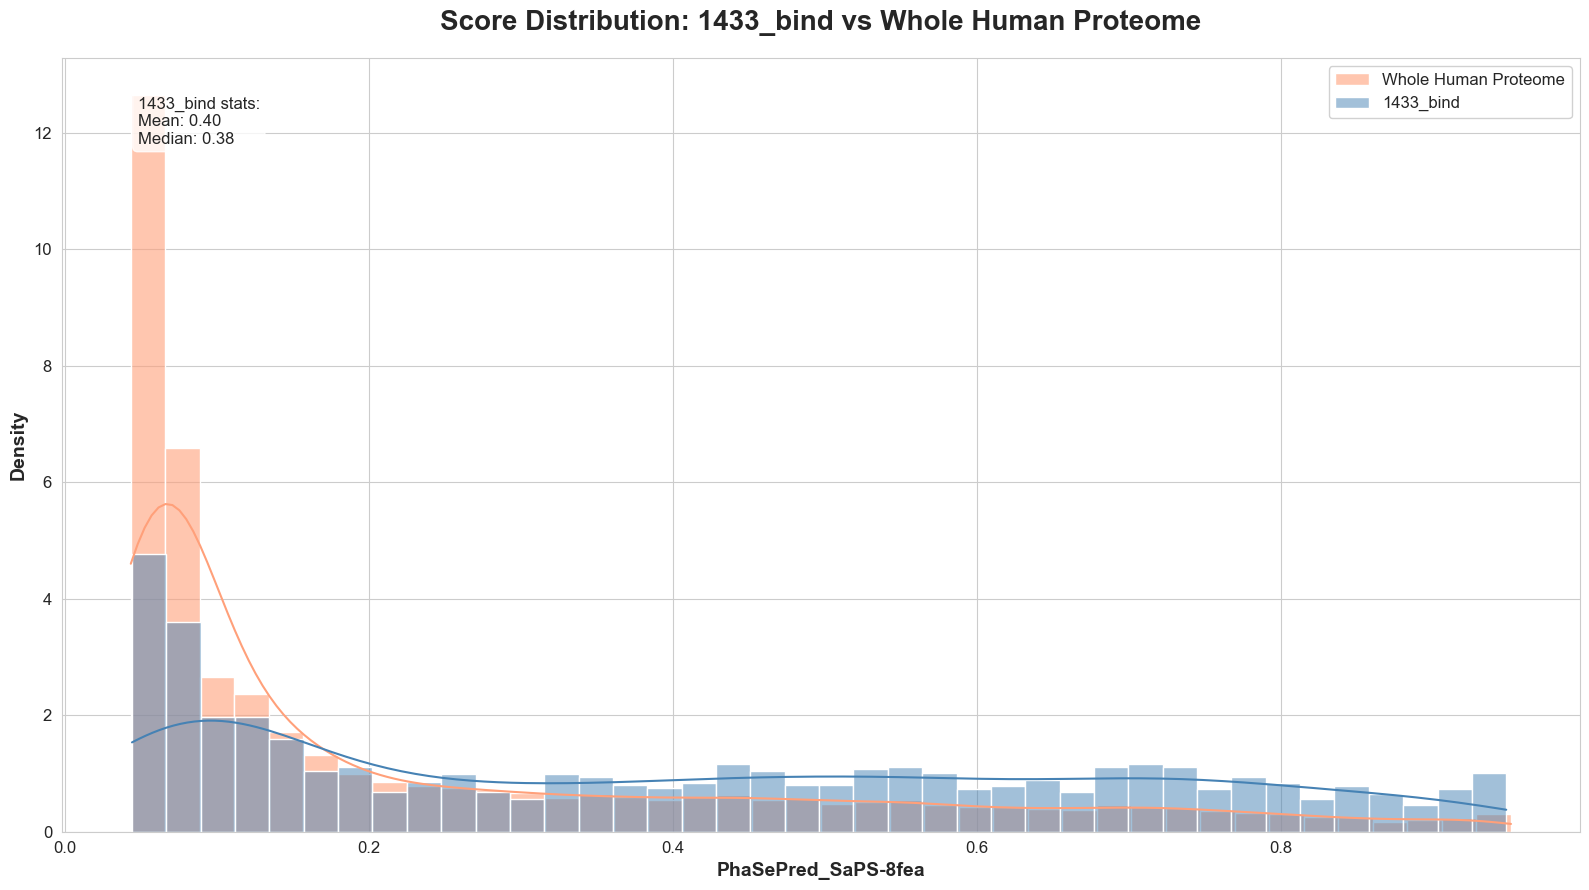

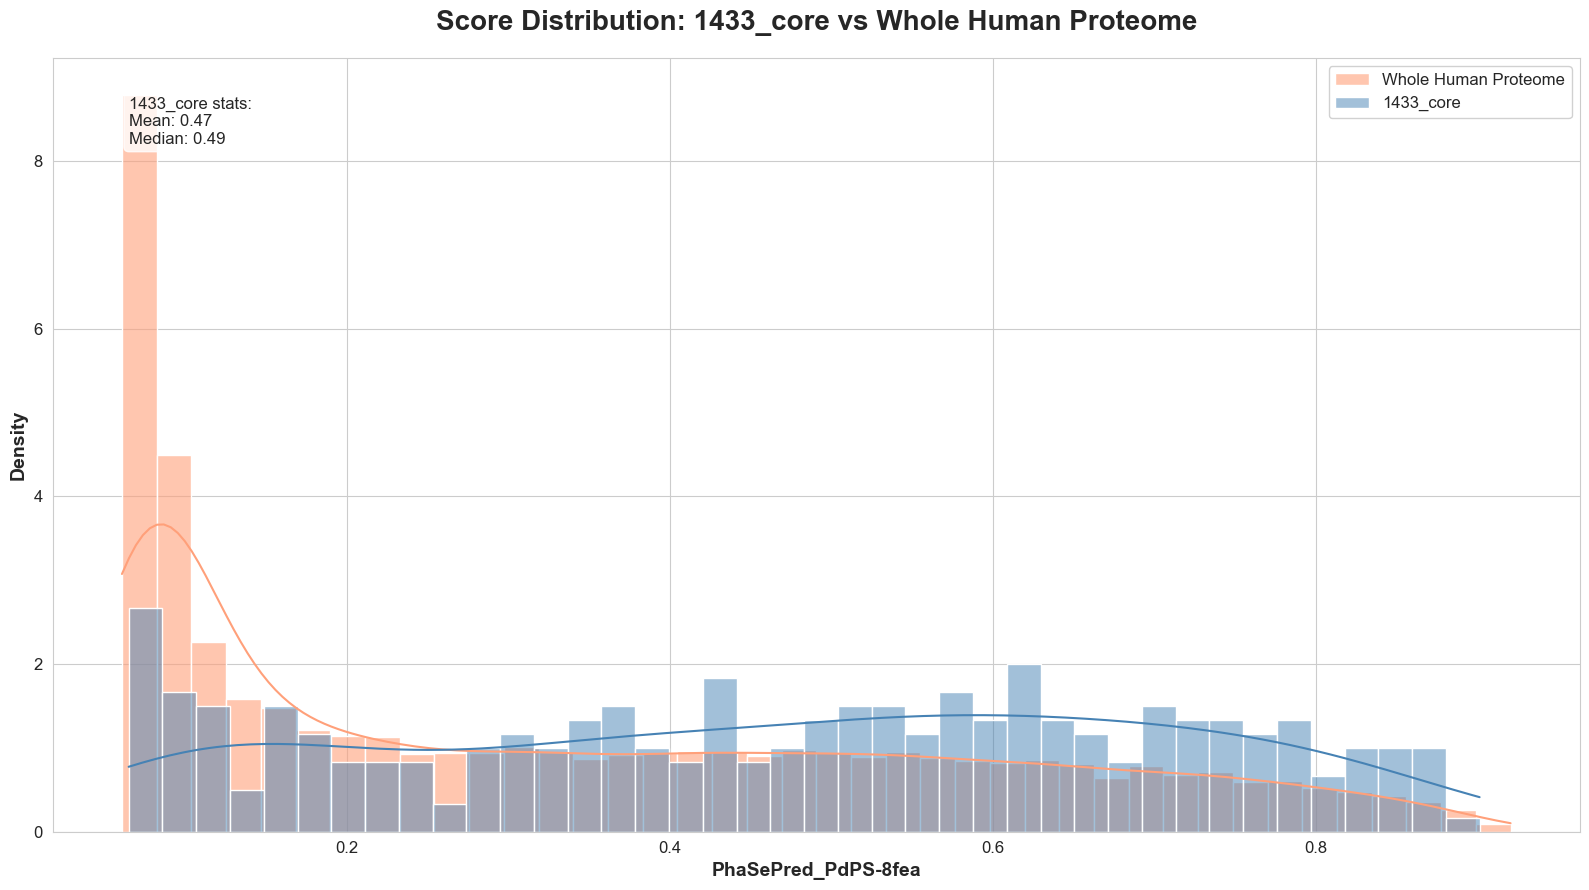

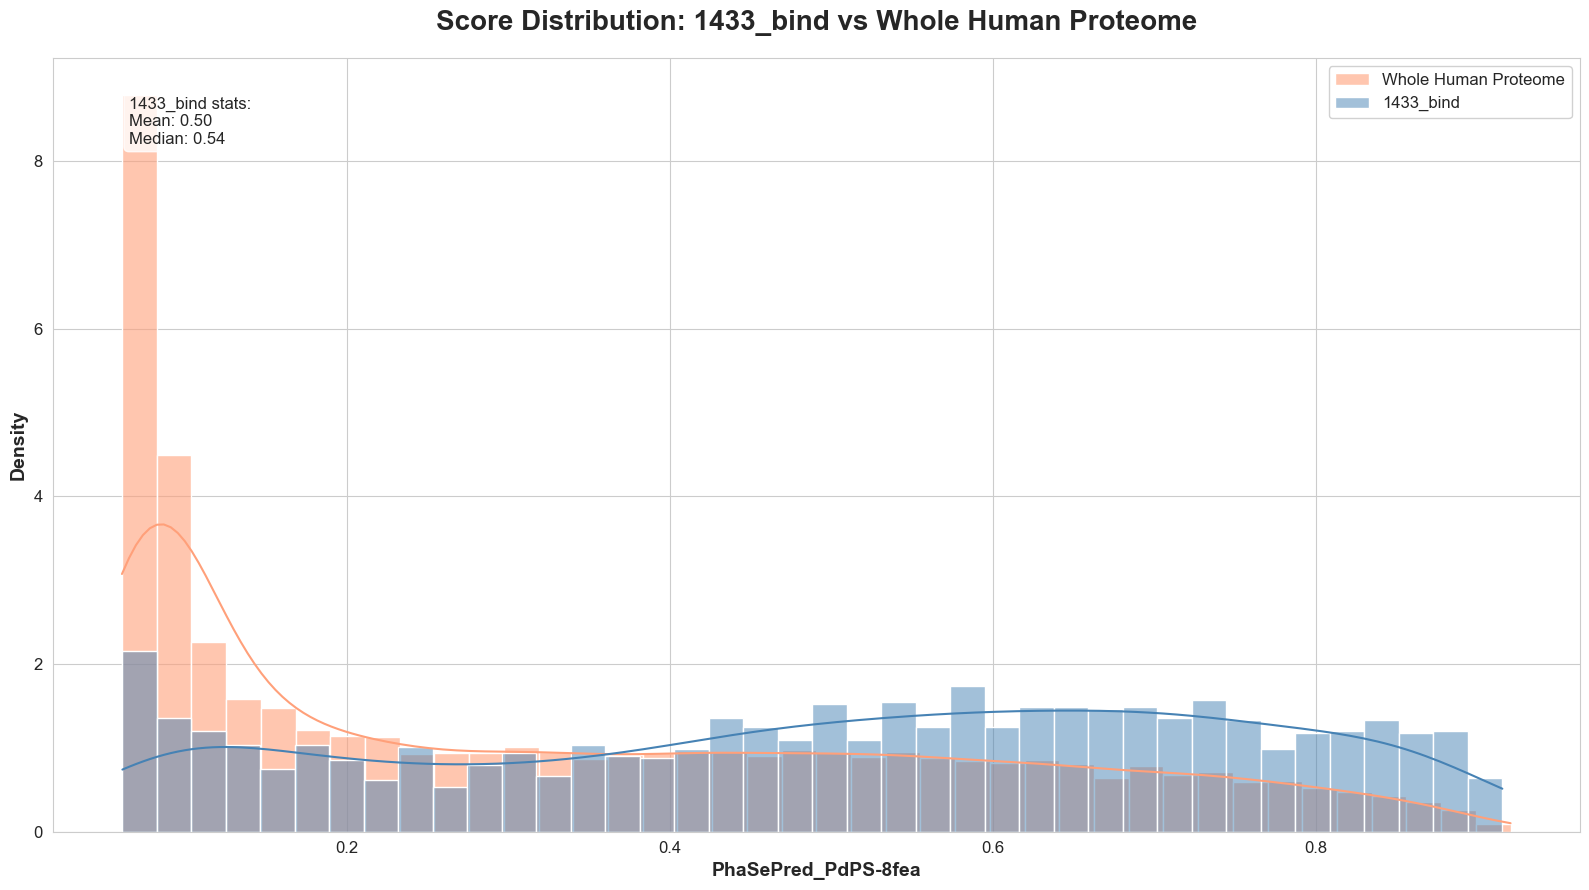

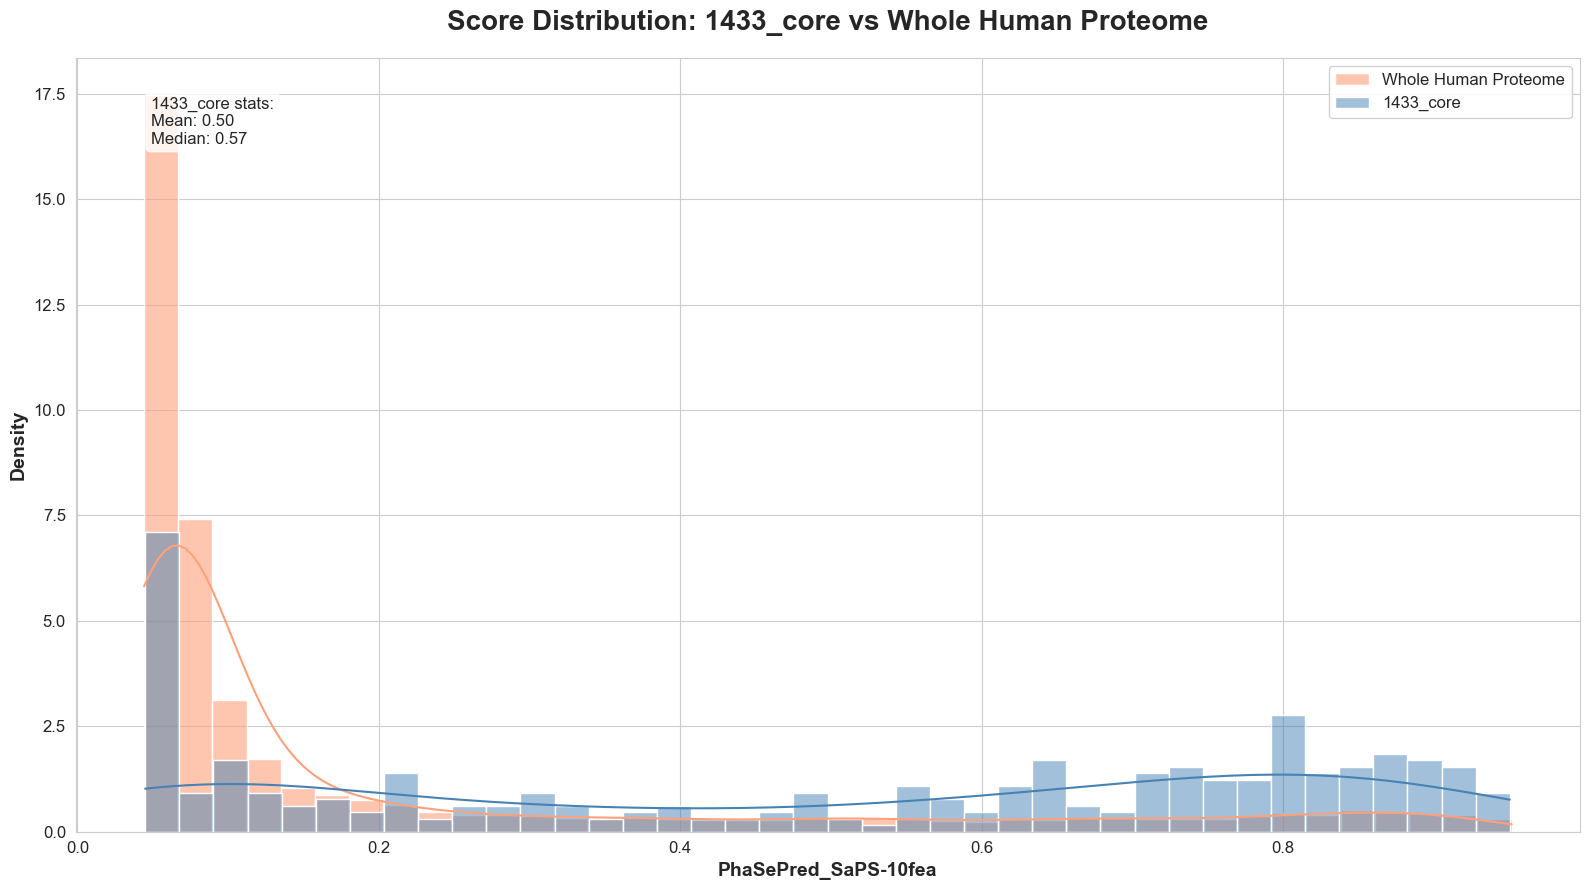

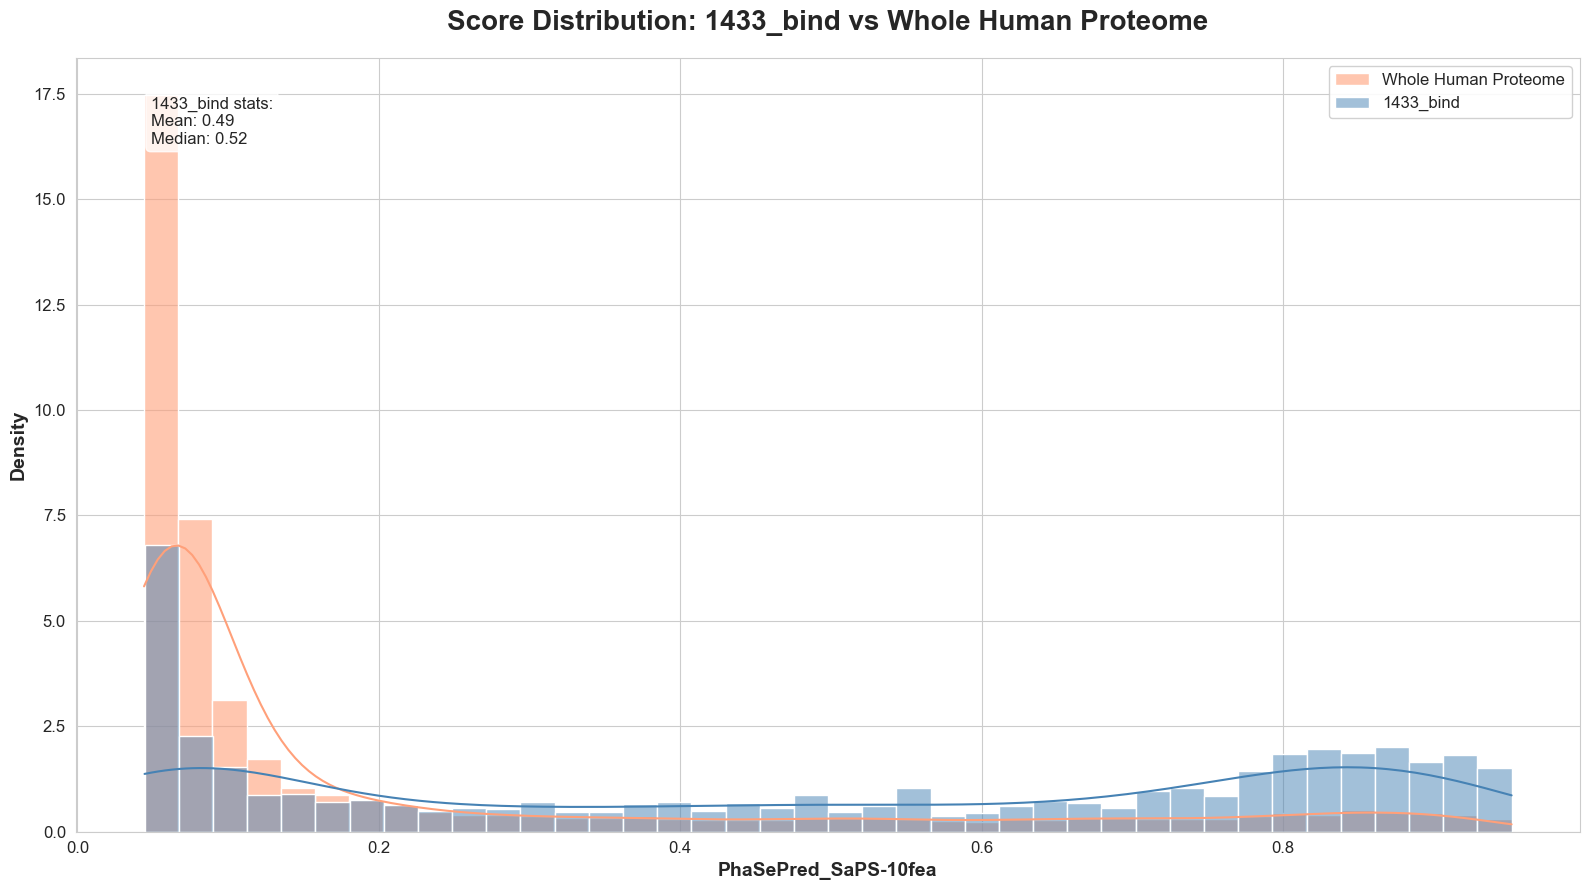

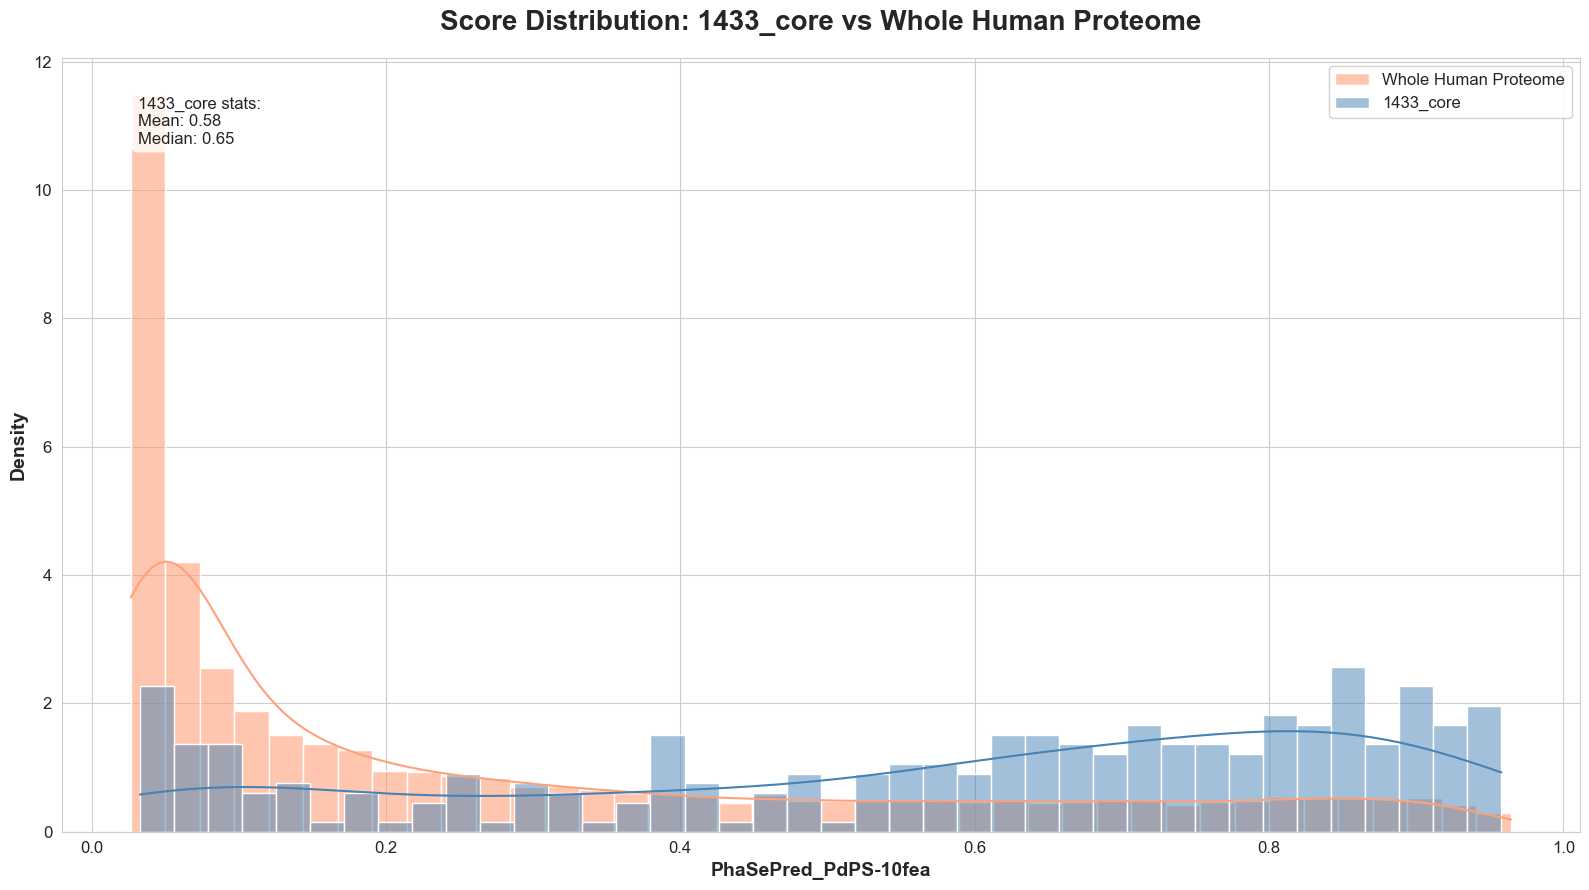

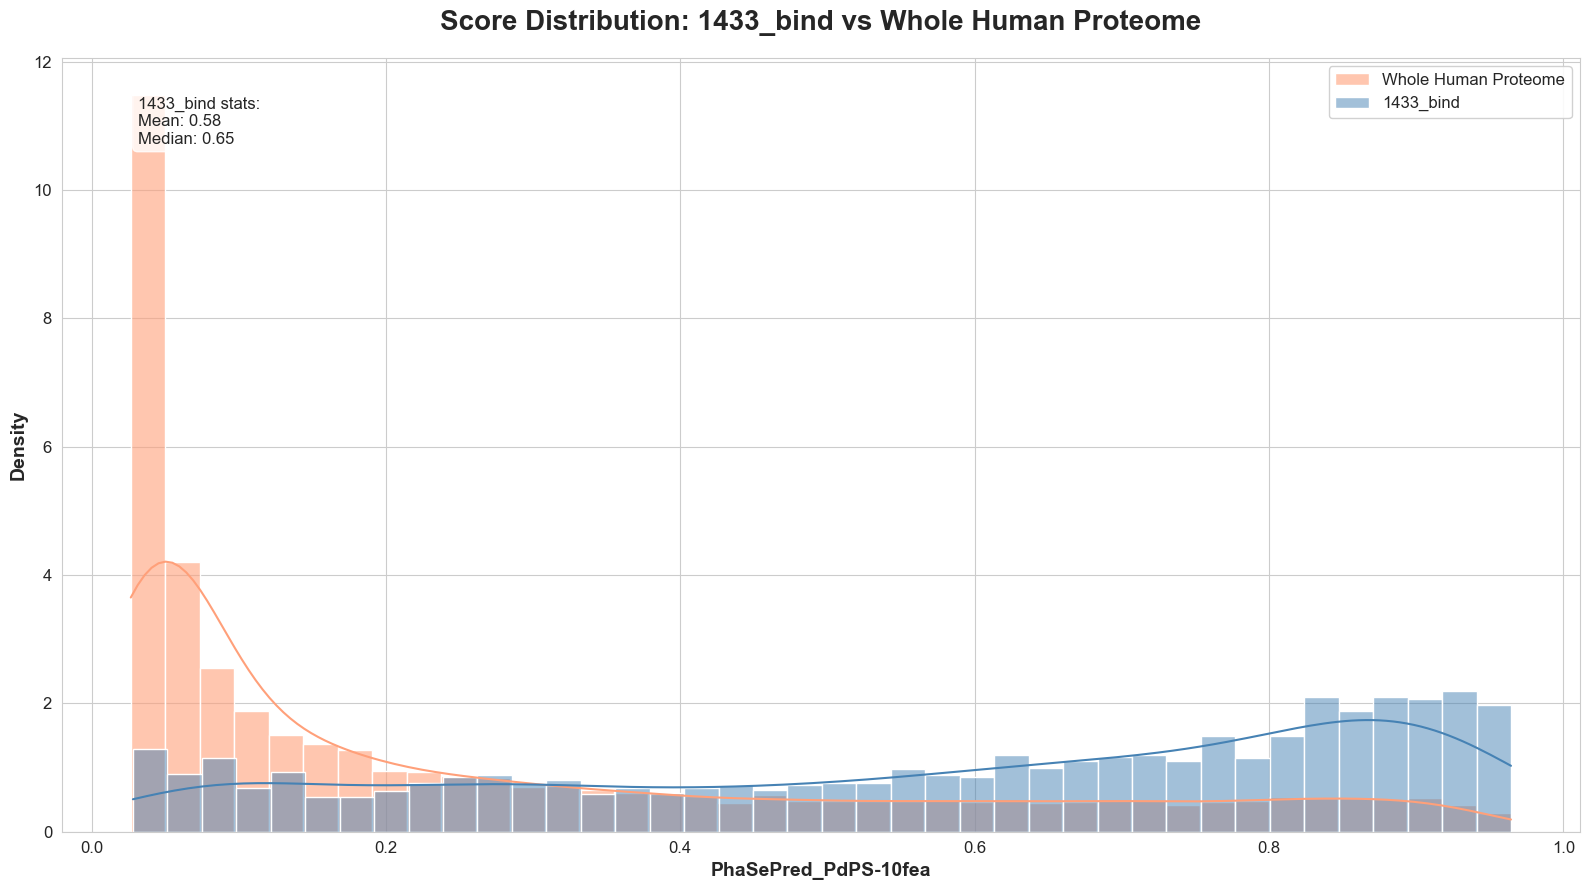

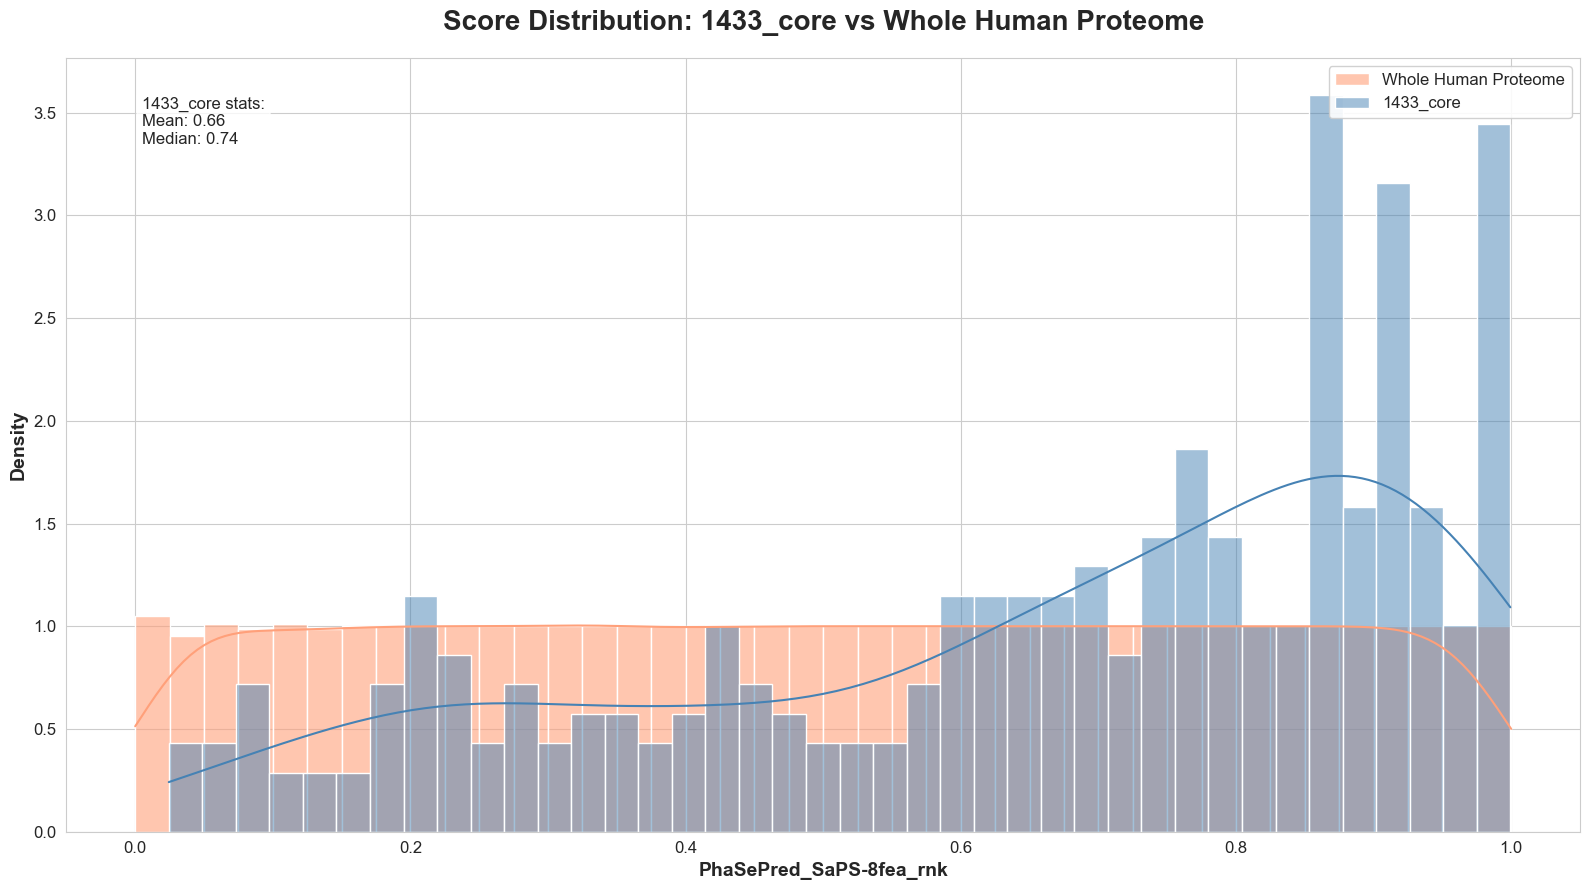

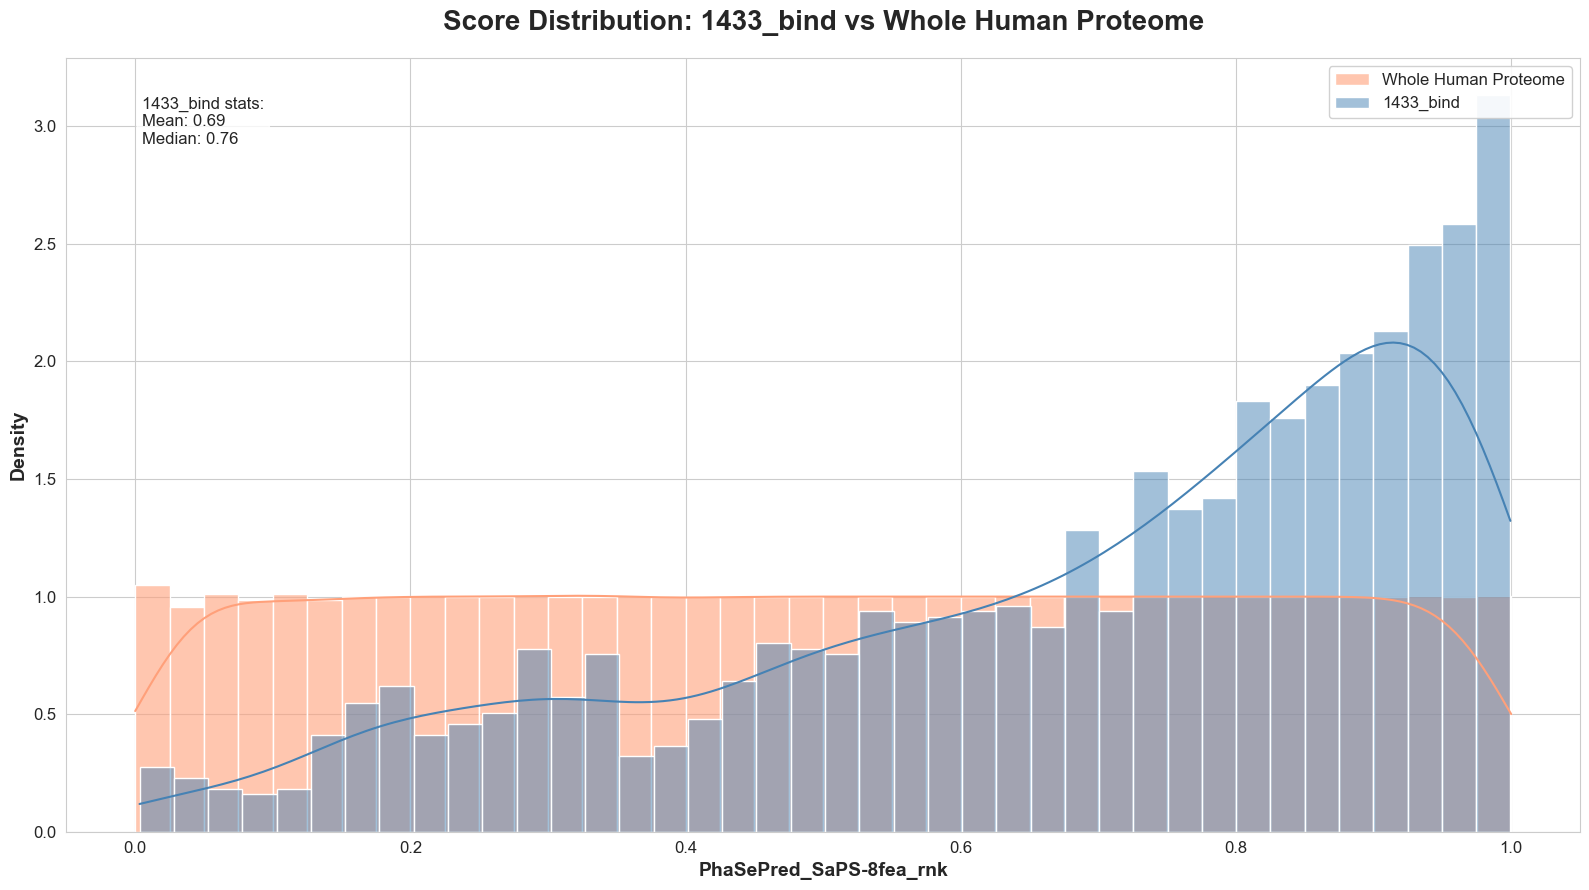

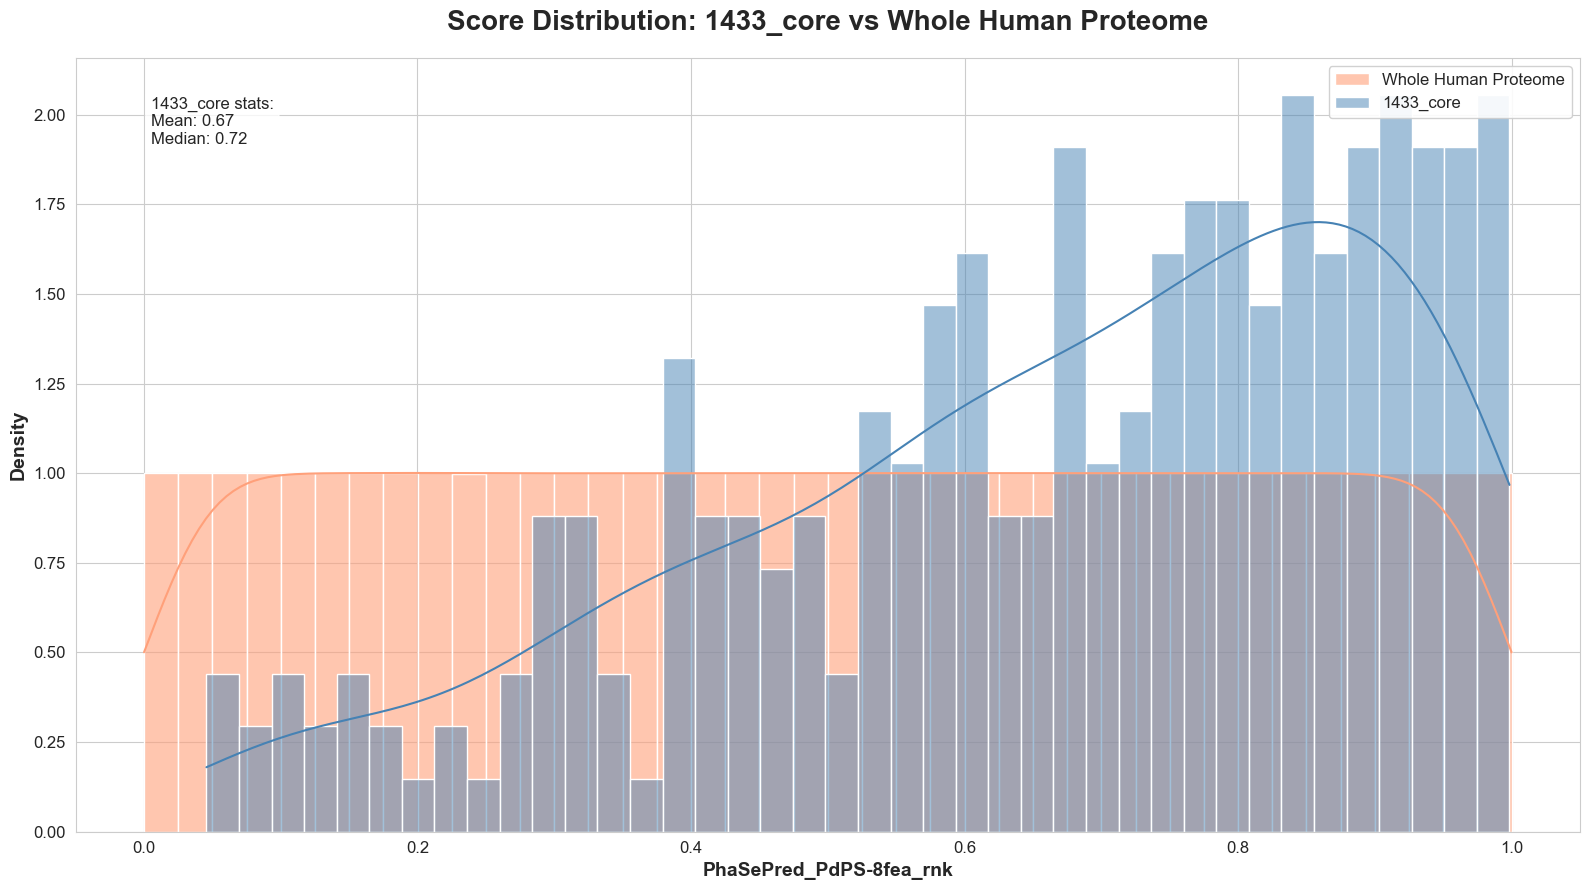

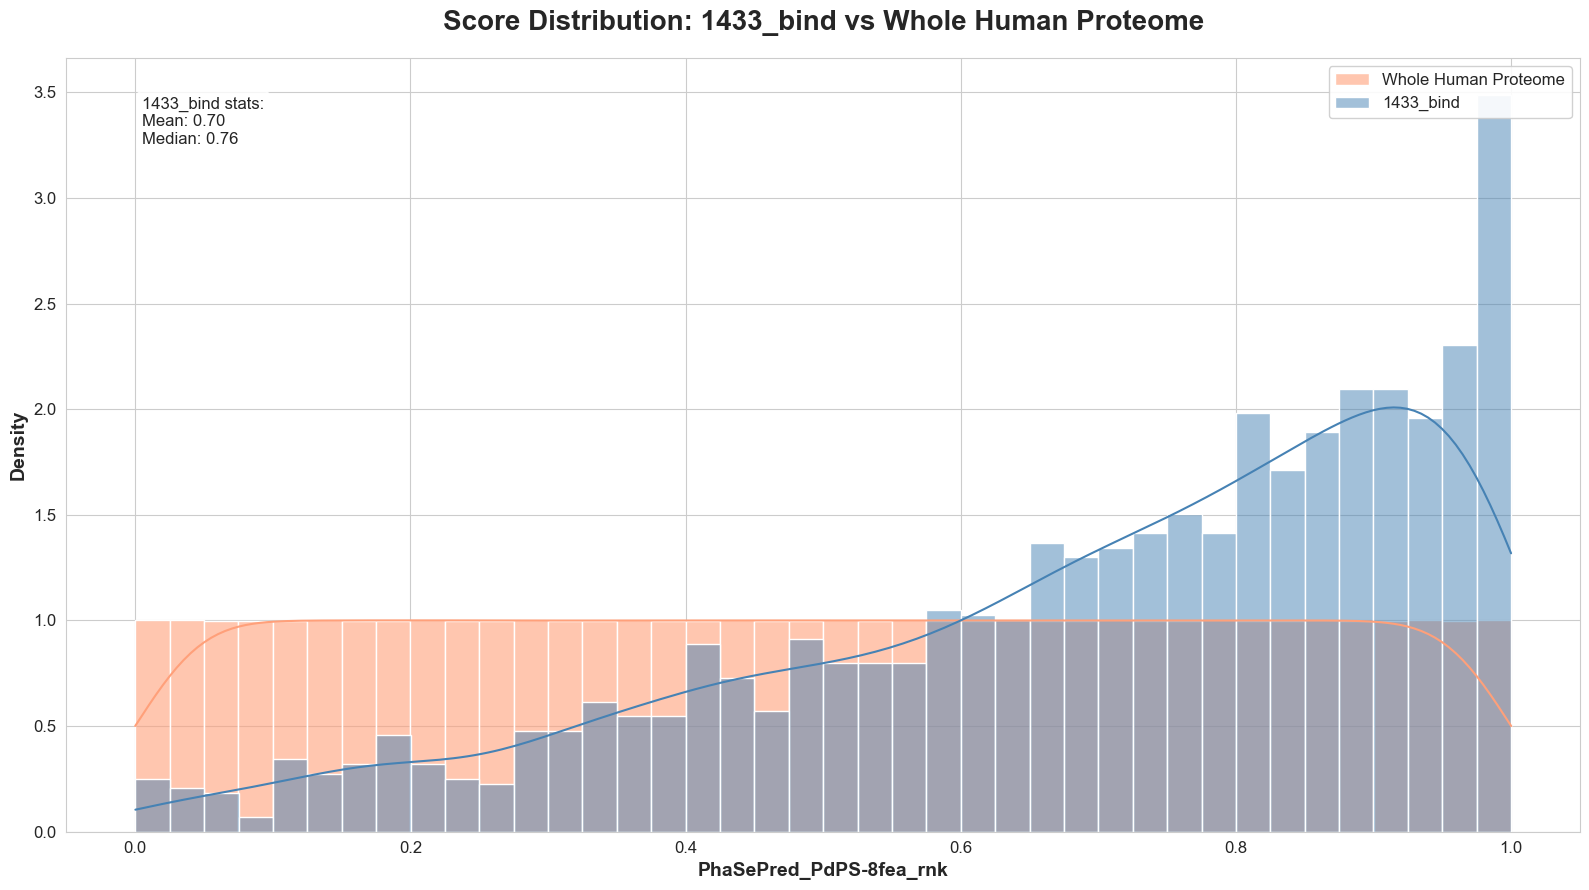

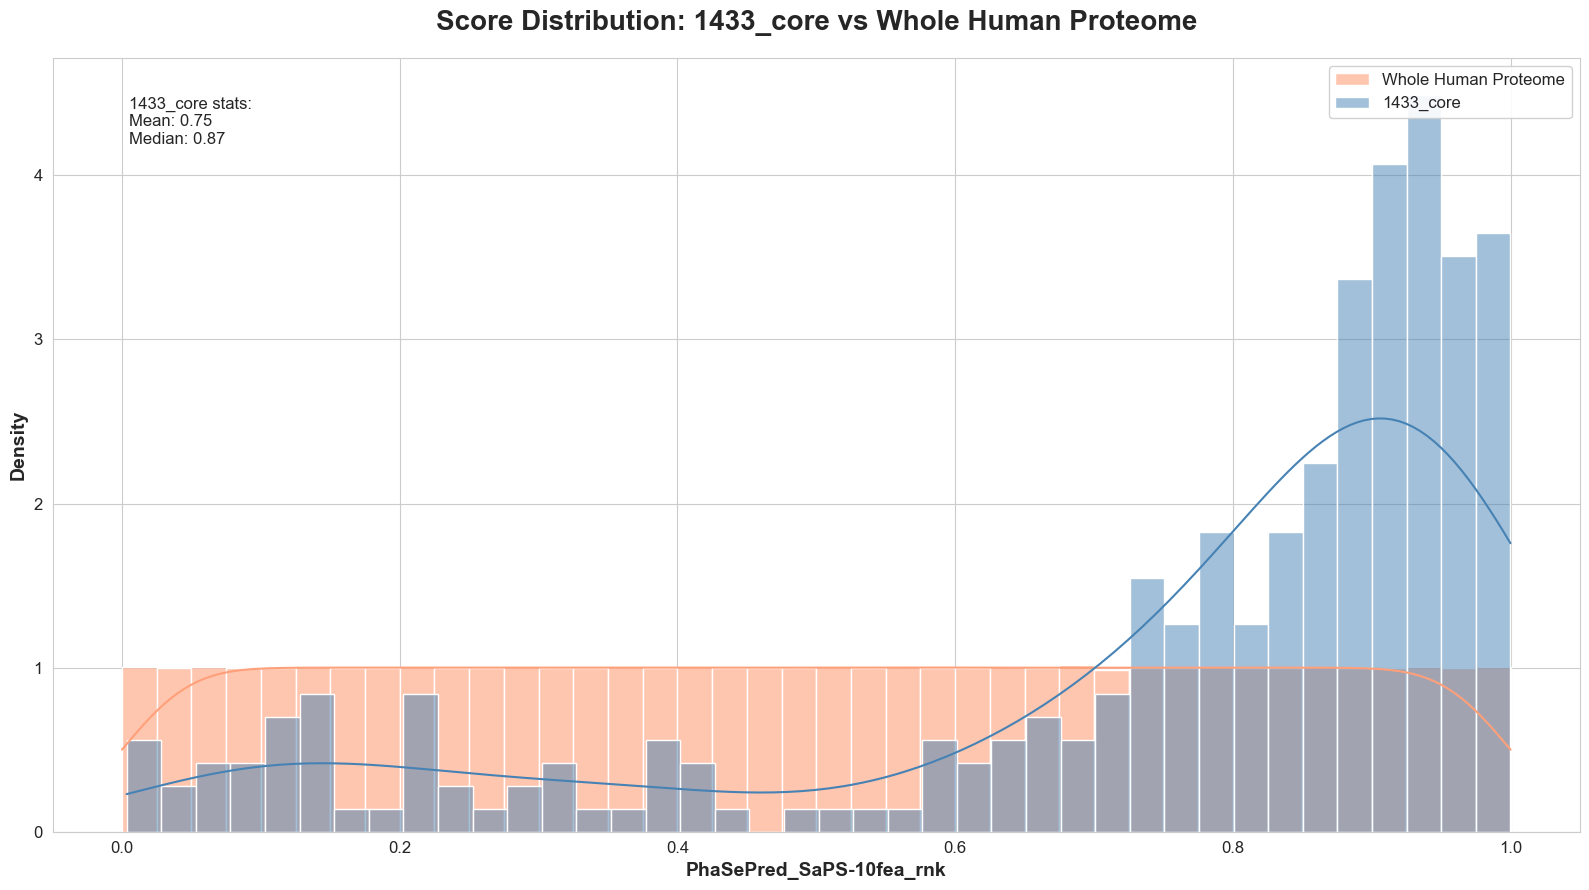

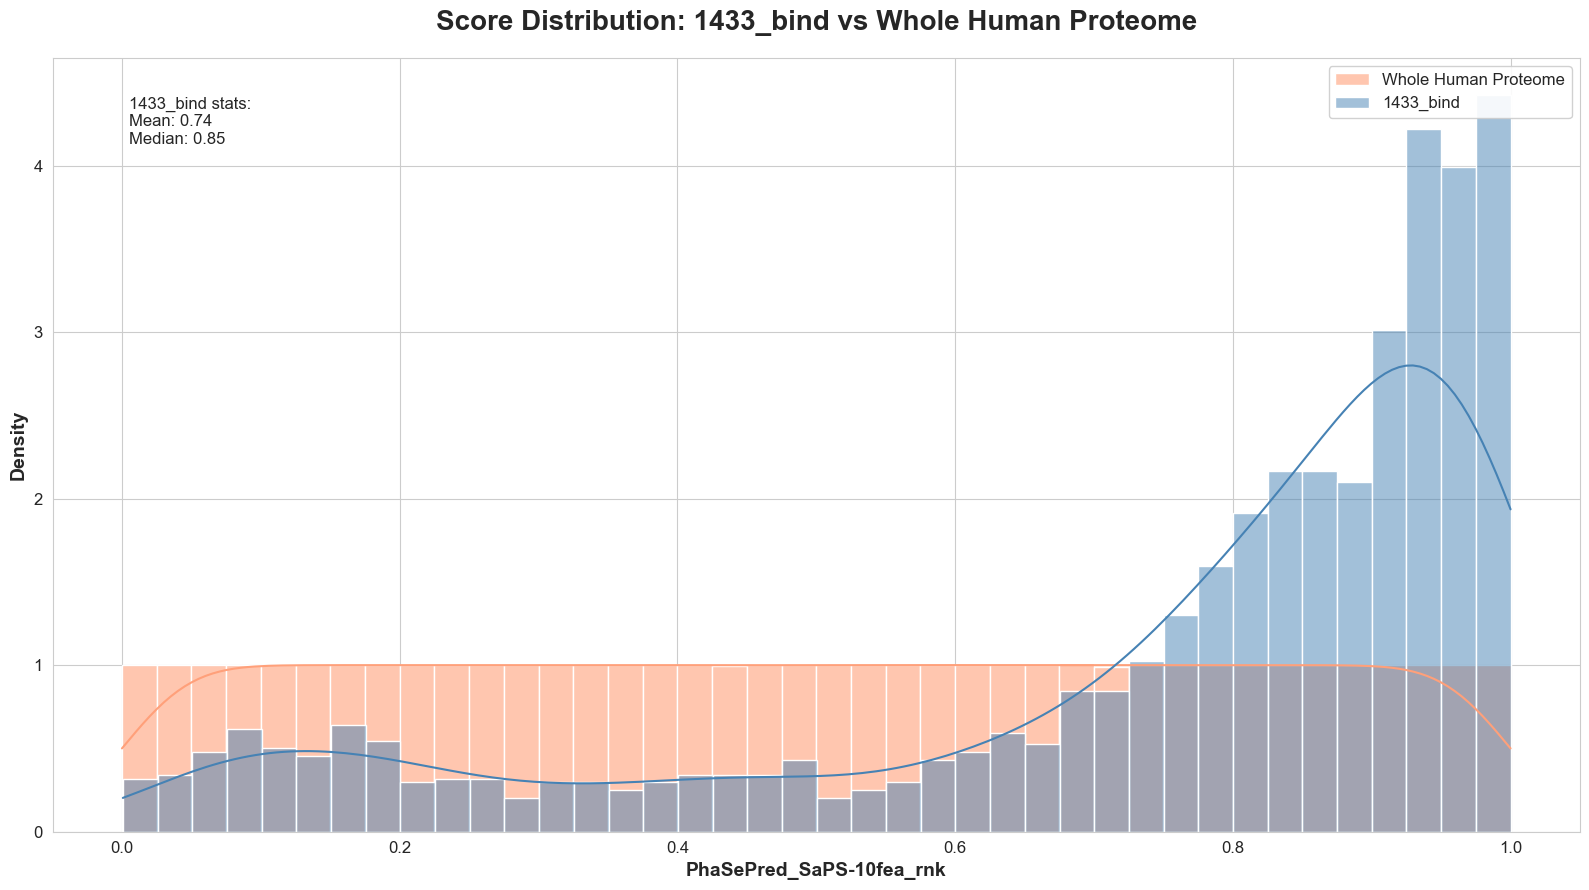

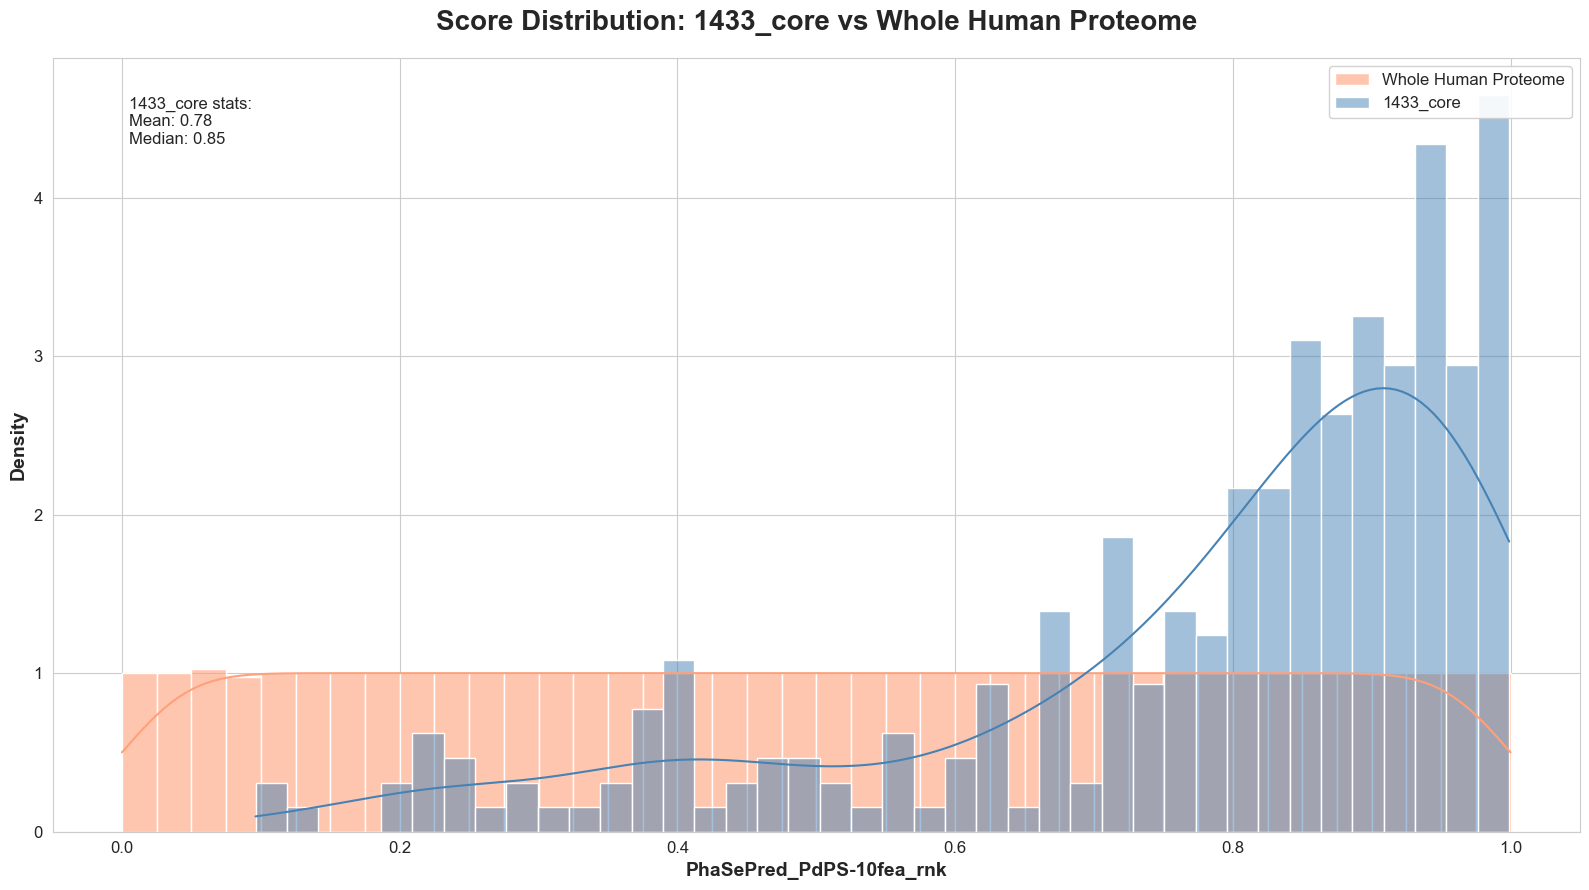

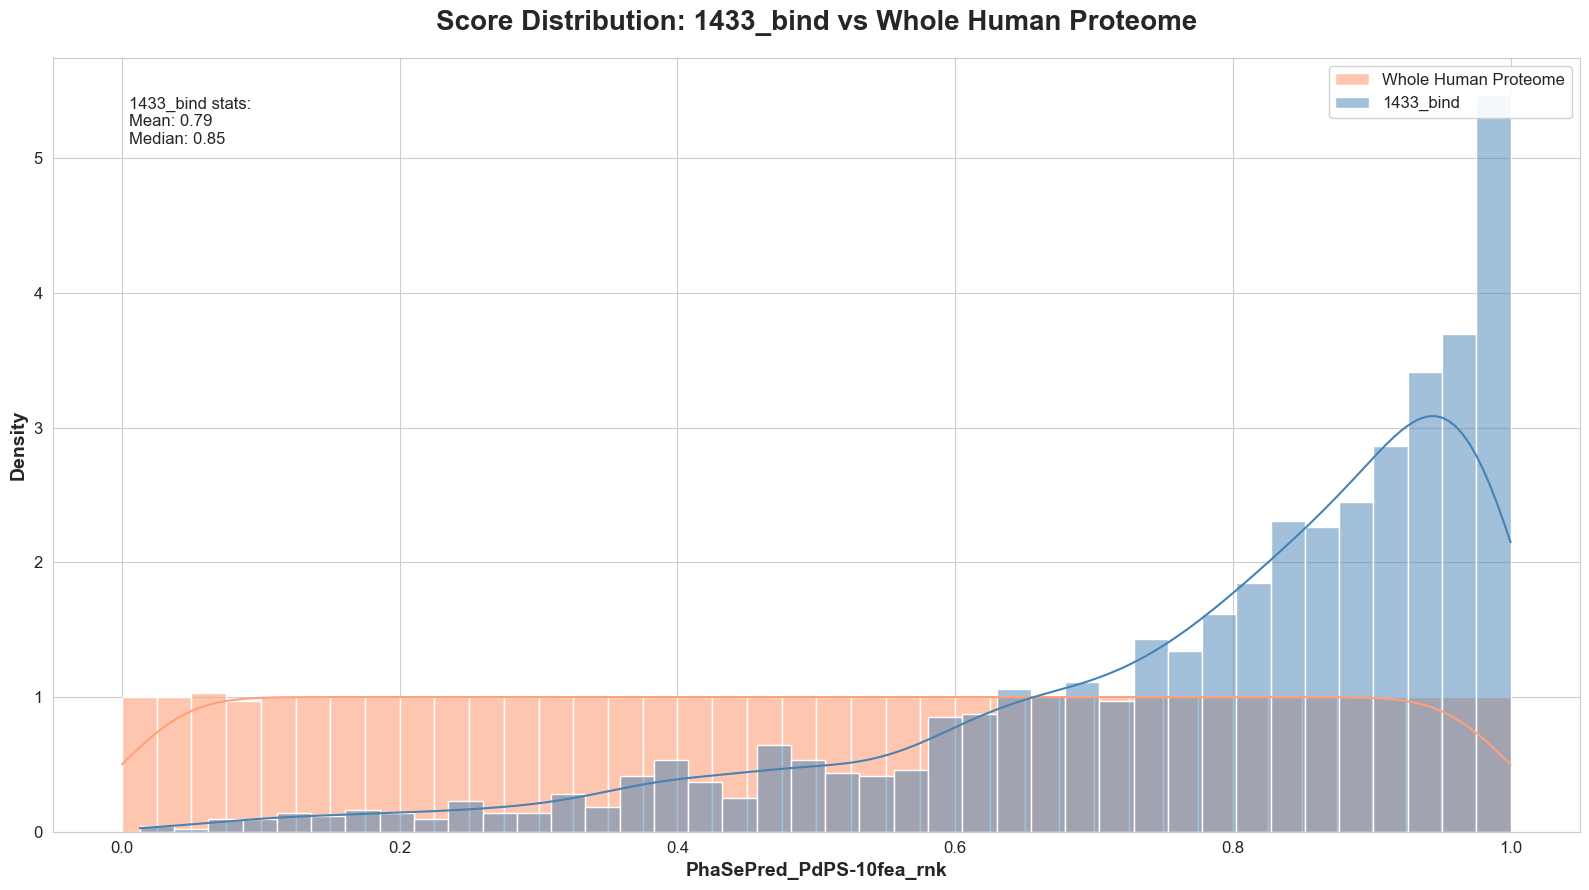

In [41]:
for column in score_columns:
    if column not in ['uniprot_id','Sequence']:
        if column in phasepred_score_columns:
            distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_PhaSePred,column, 'uniprot_id')
            distribution_go(Protein_1433_interactome,"1433_bind", df_PhaSePred,column, 'uniprot_id')

task 11: we further compared phase separation-related physicochemical properties between the entire human proteome and 14-3-3 binding proteins, including FCR, IDR, LCR, catGRANULE, PLAAC, Pscore, Hydropathy, DeepCoil , SEG, Charged Residue, Phos and protein length  

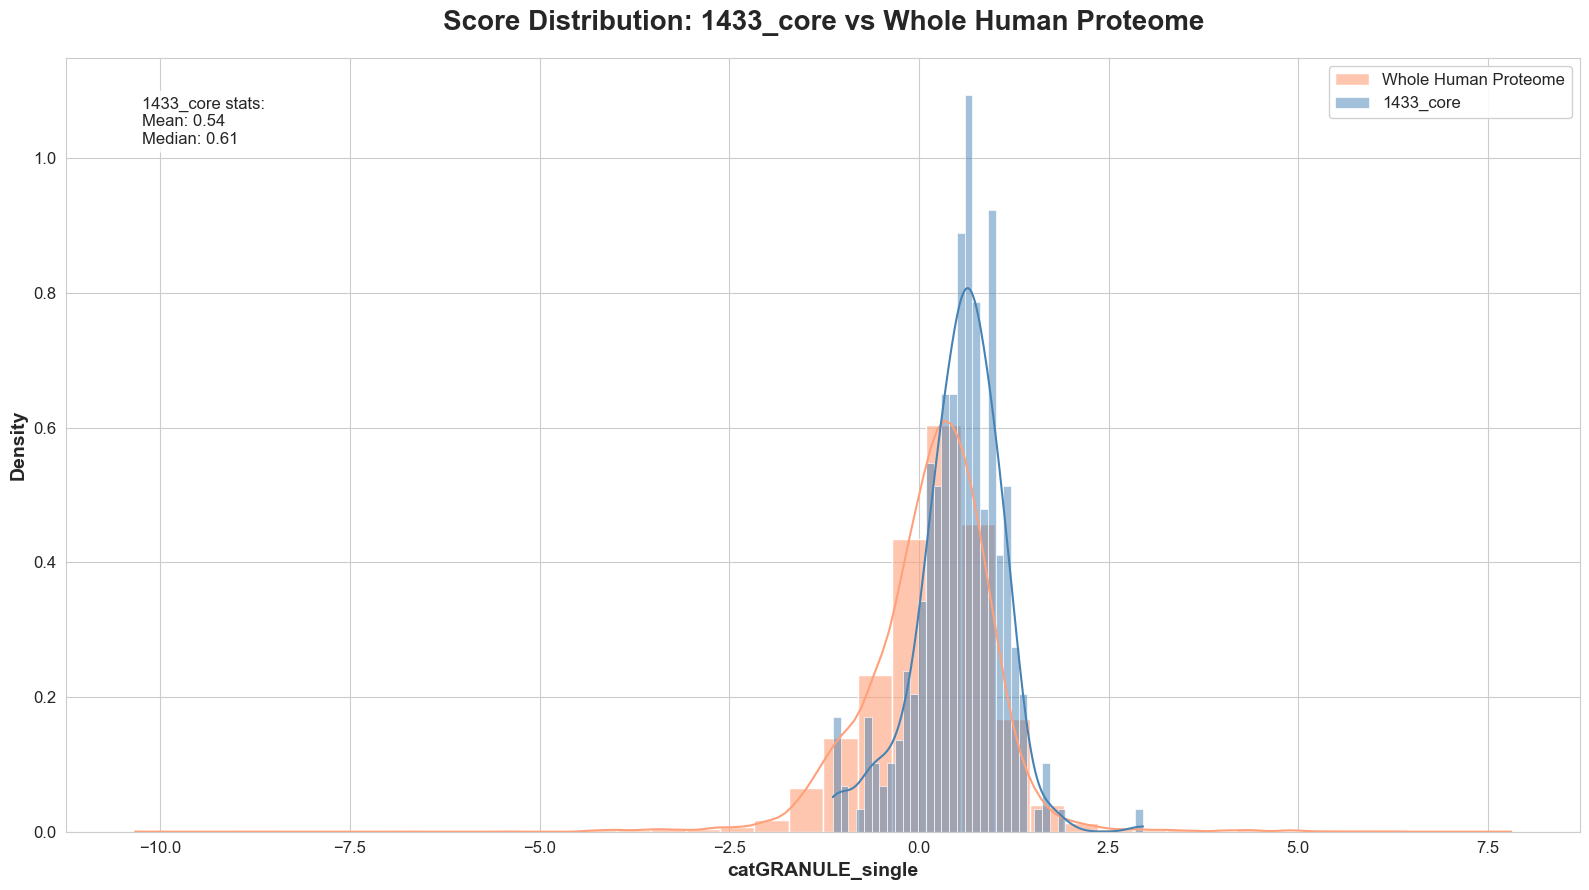

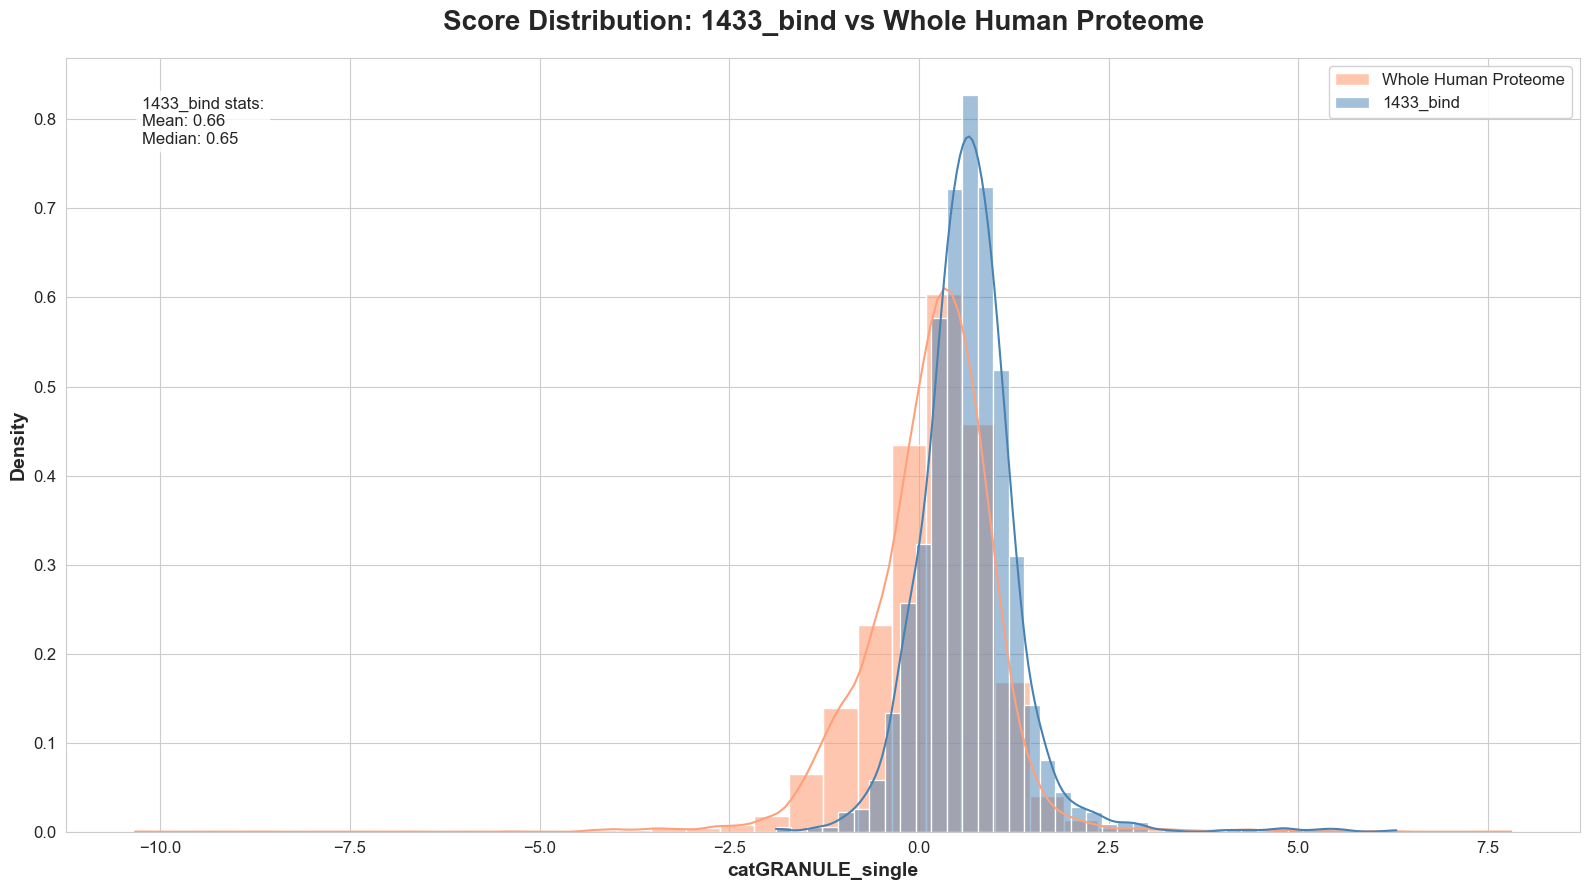

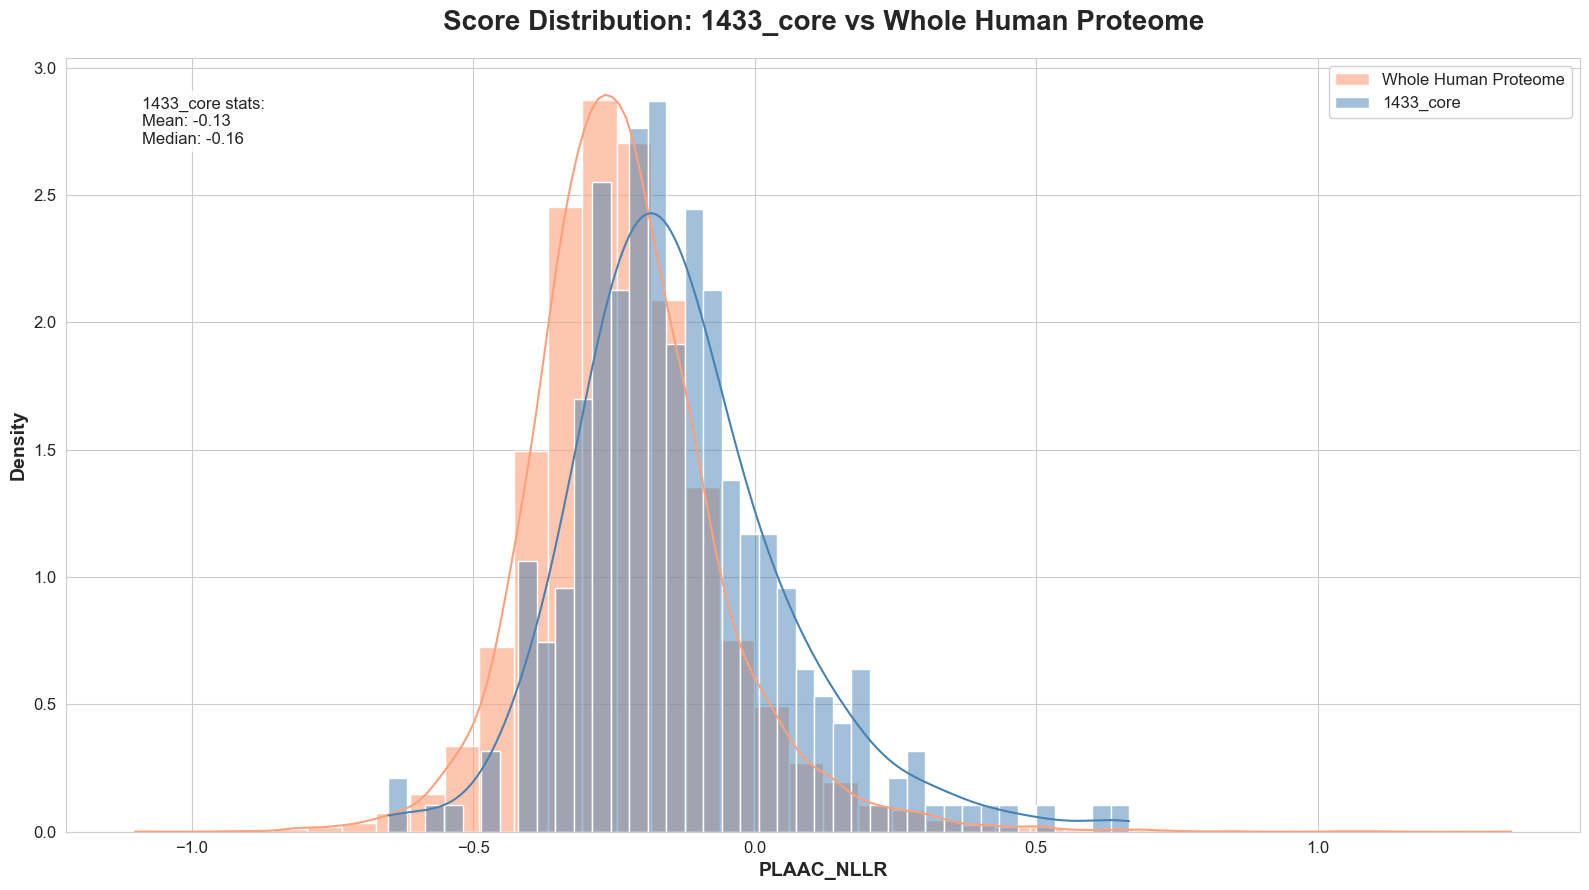

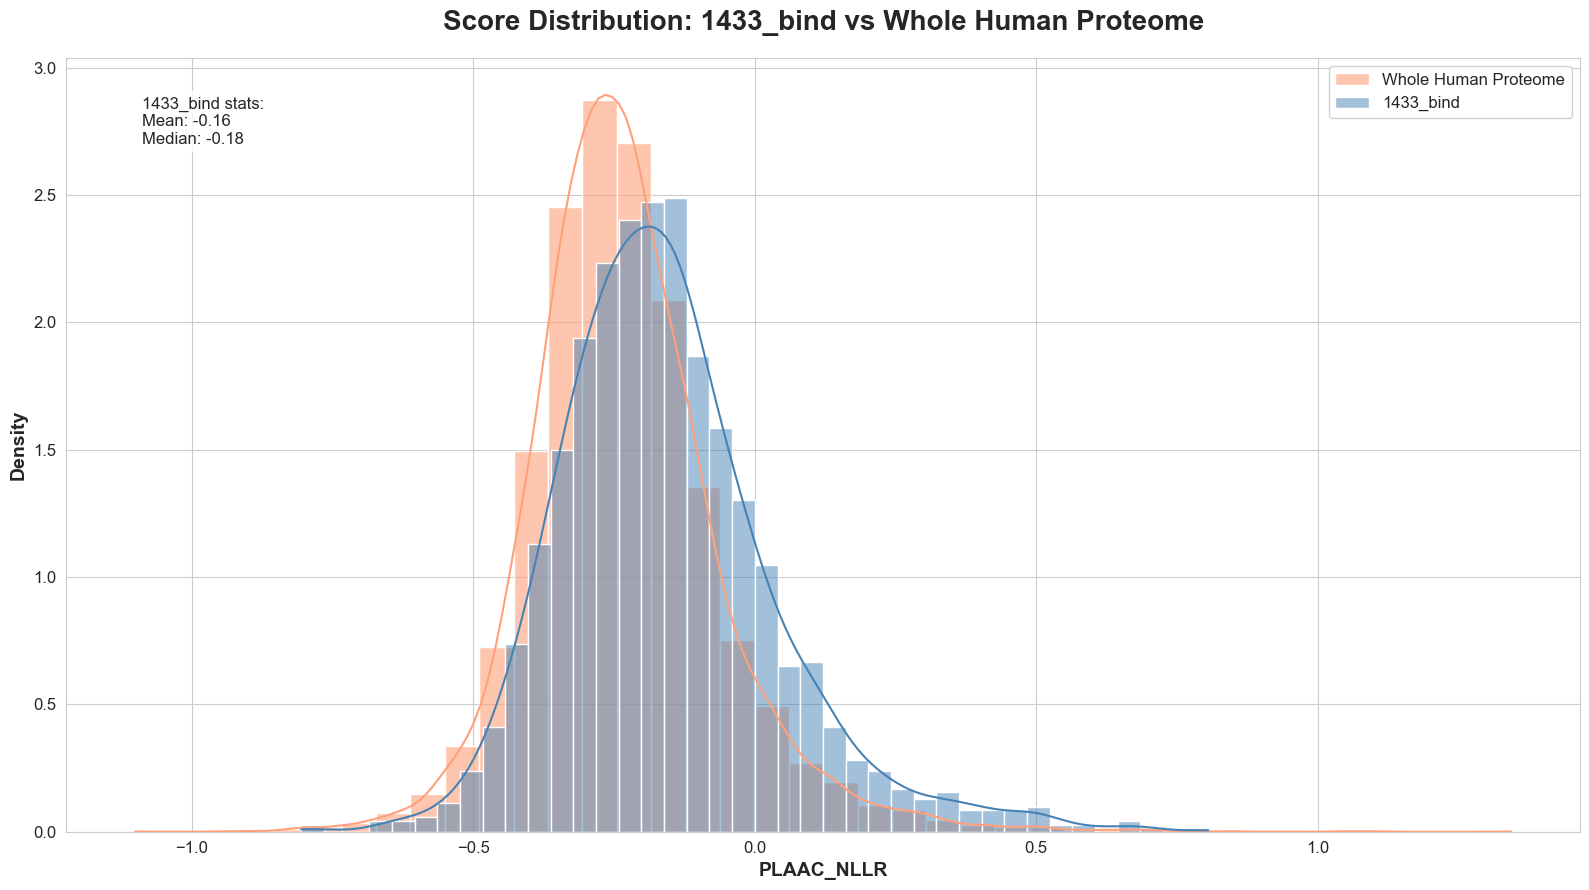

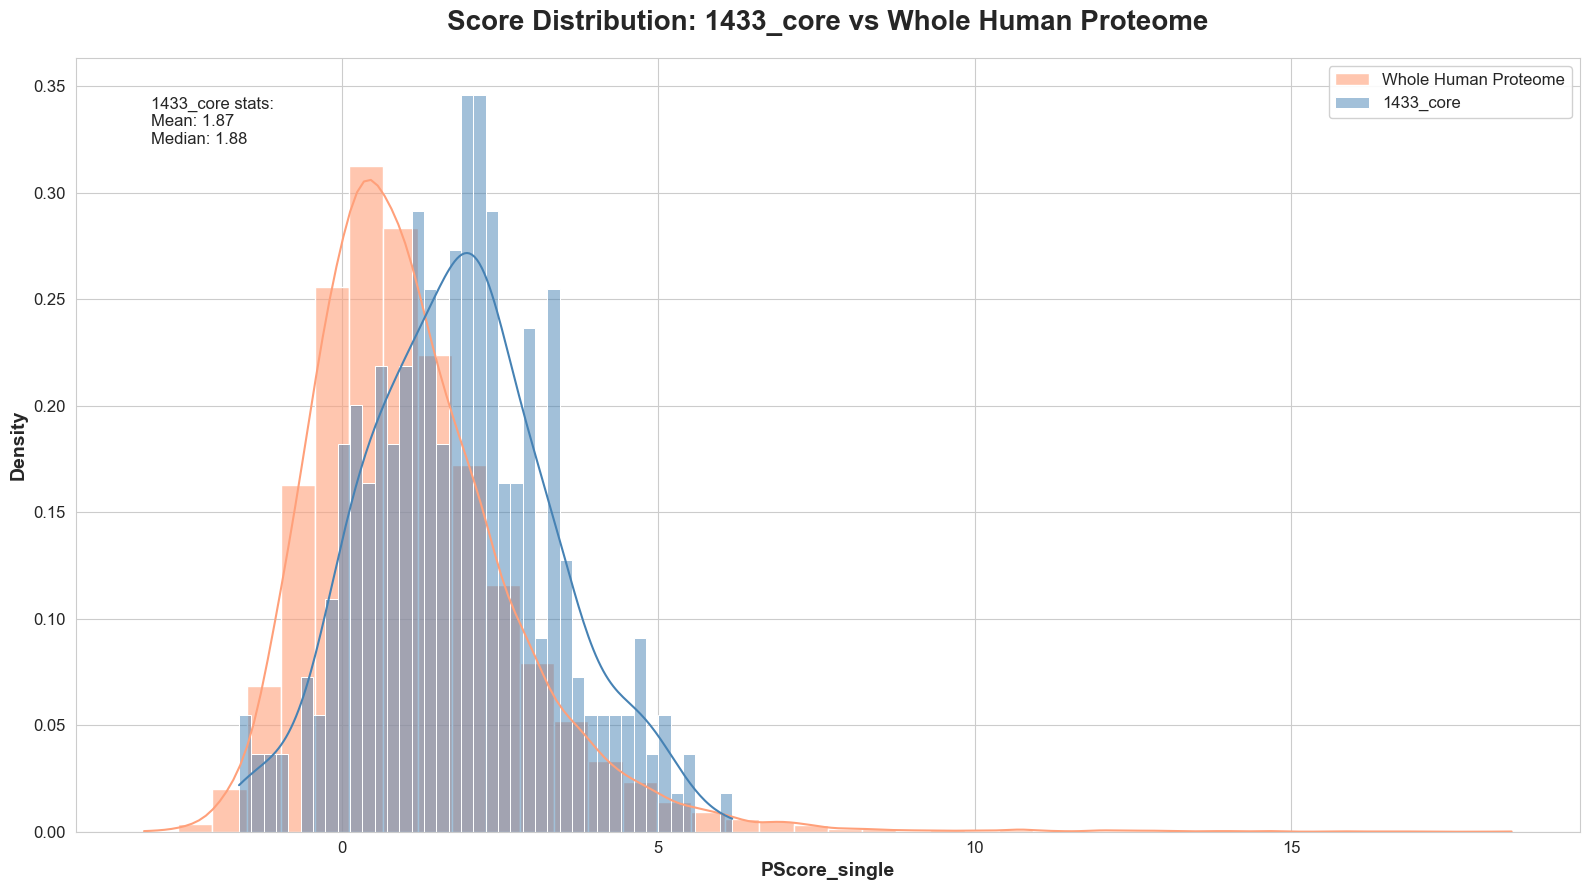

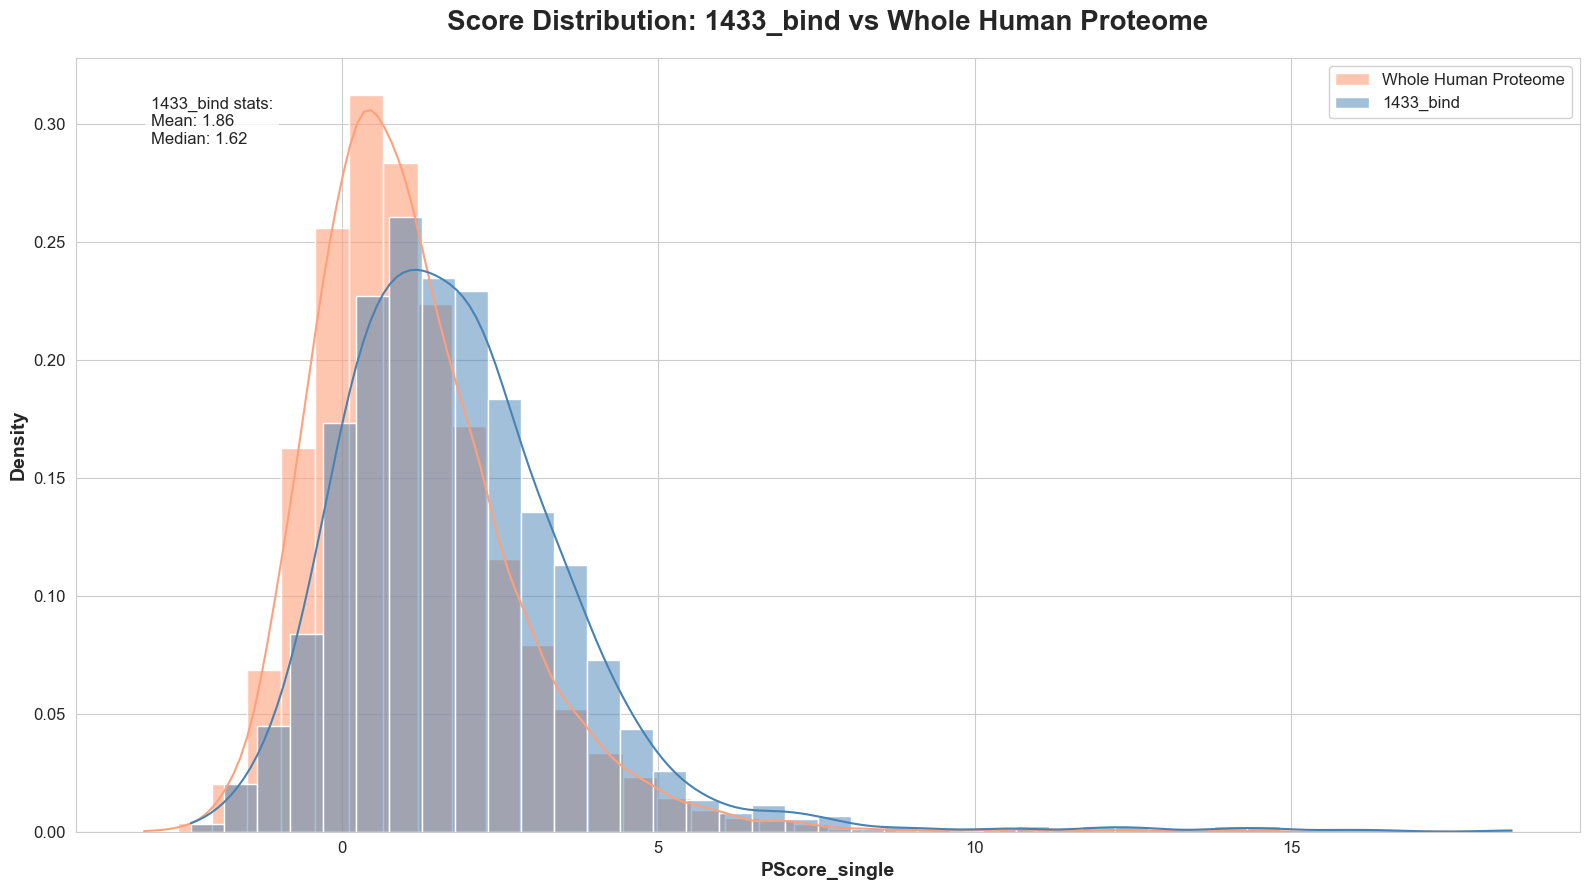

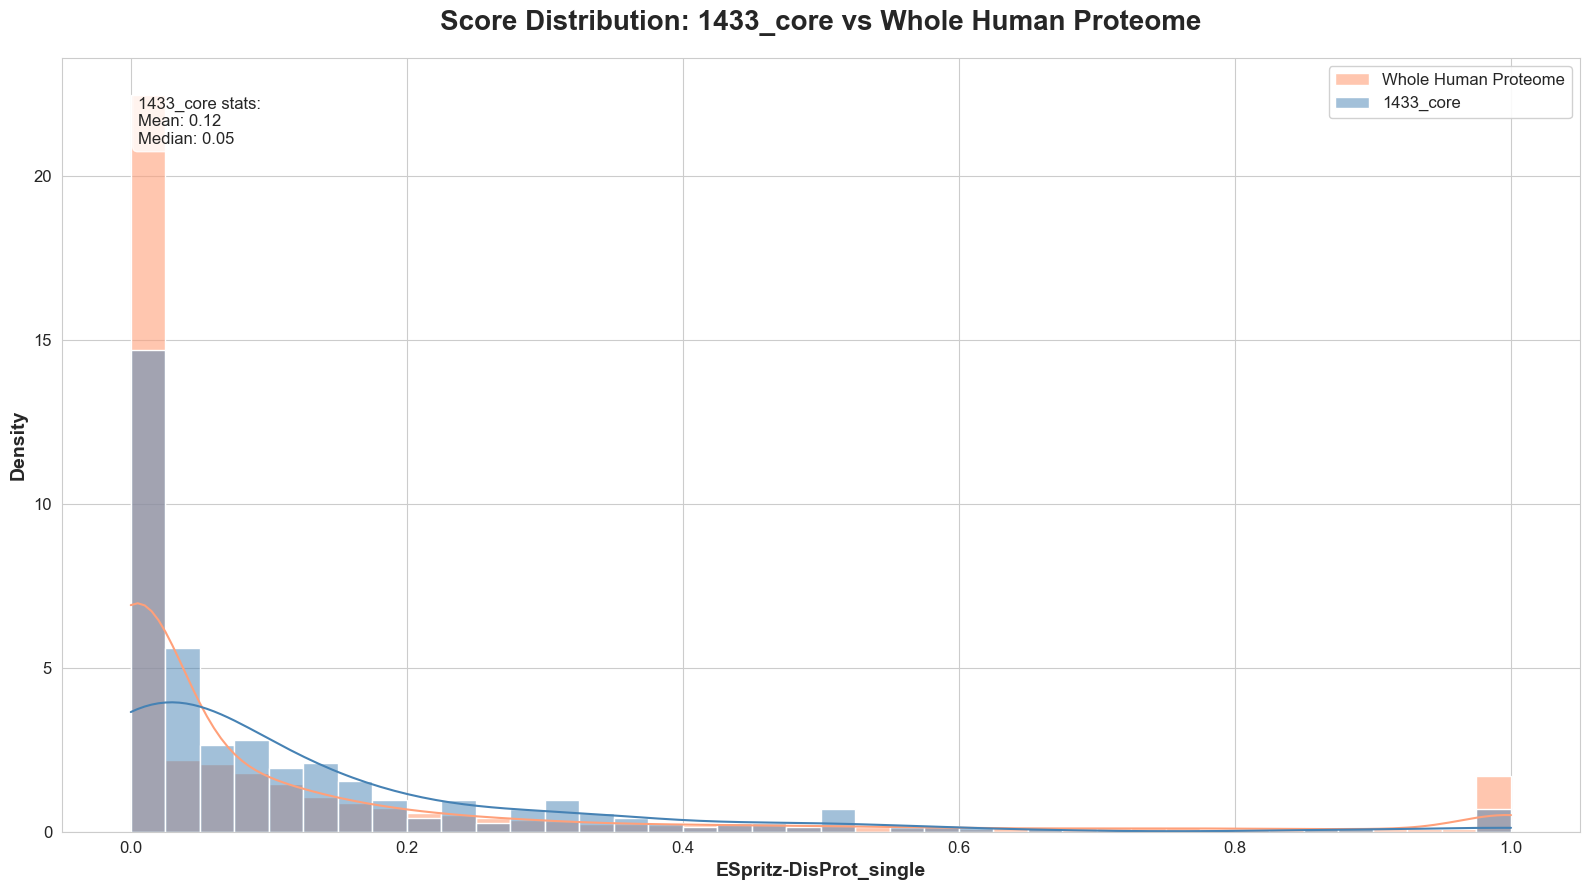

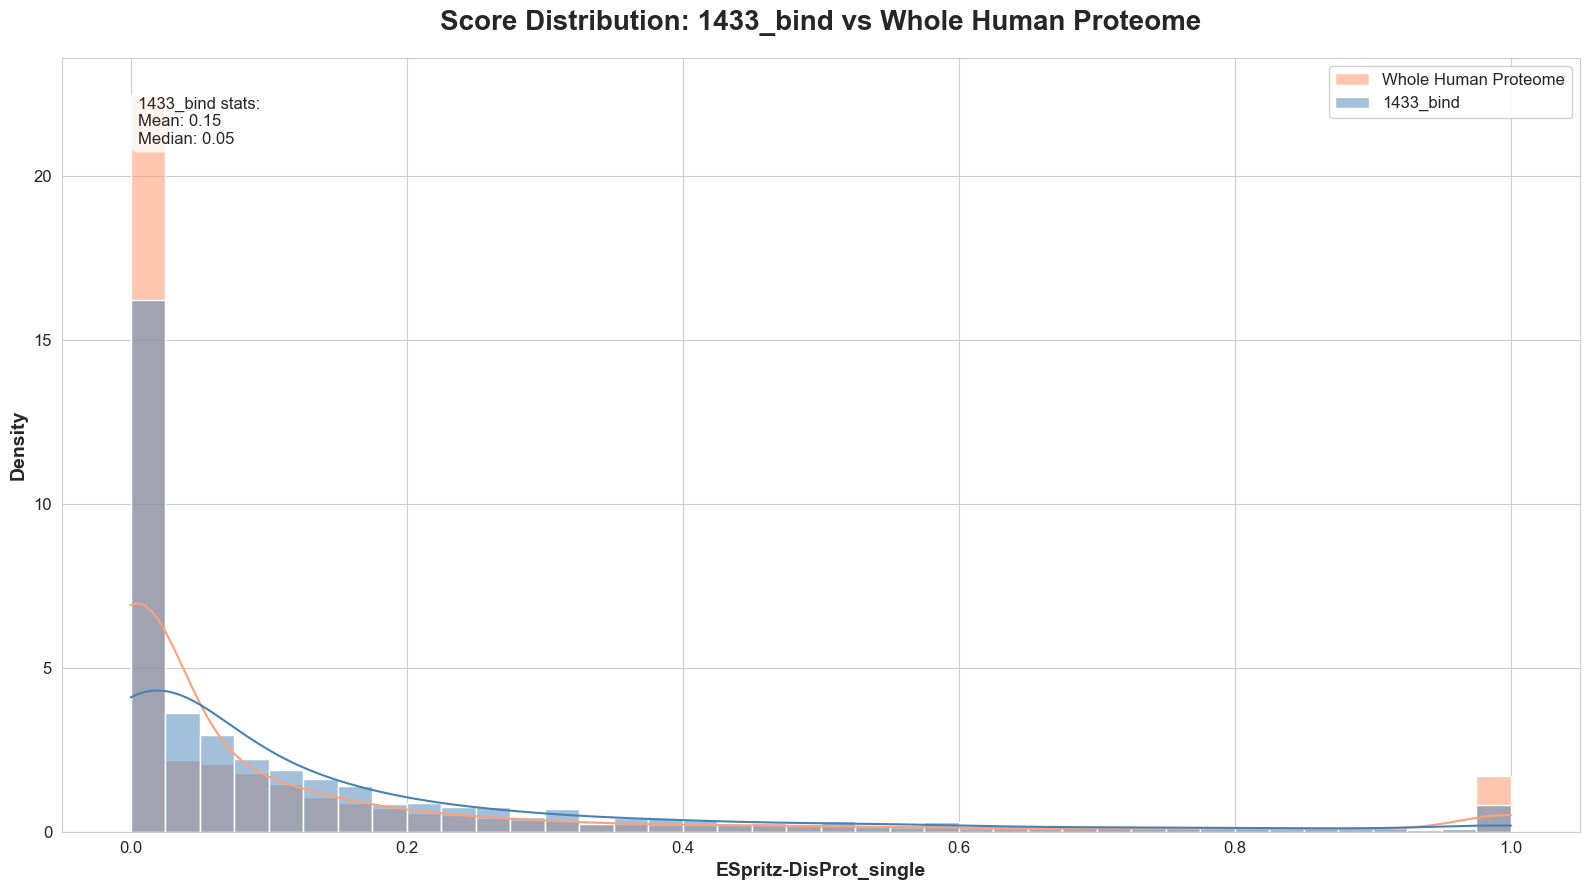

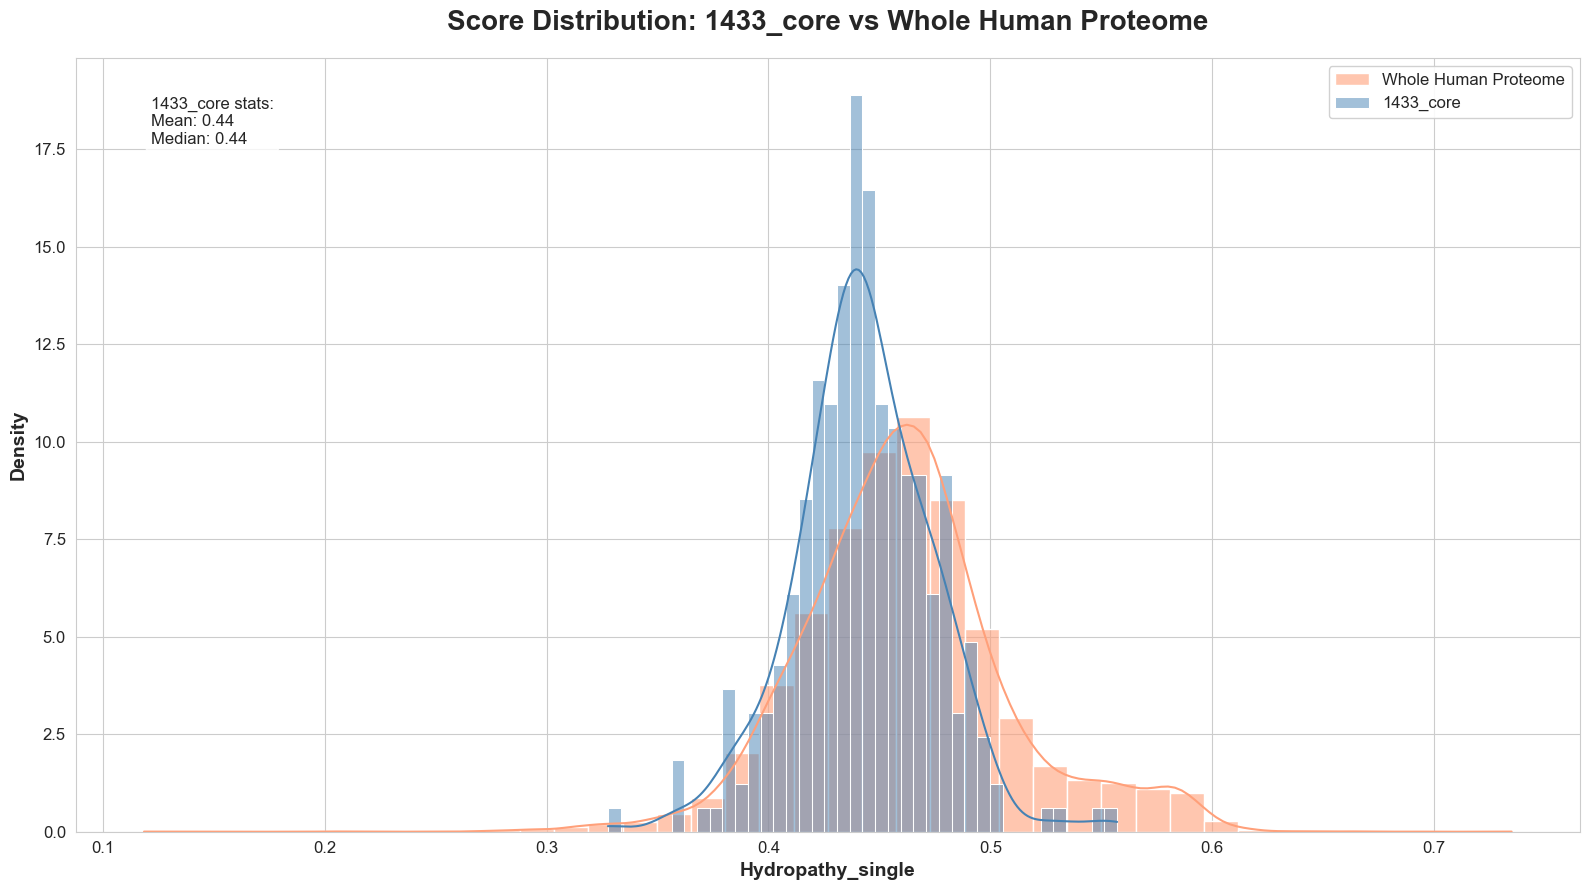

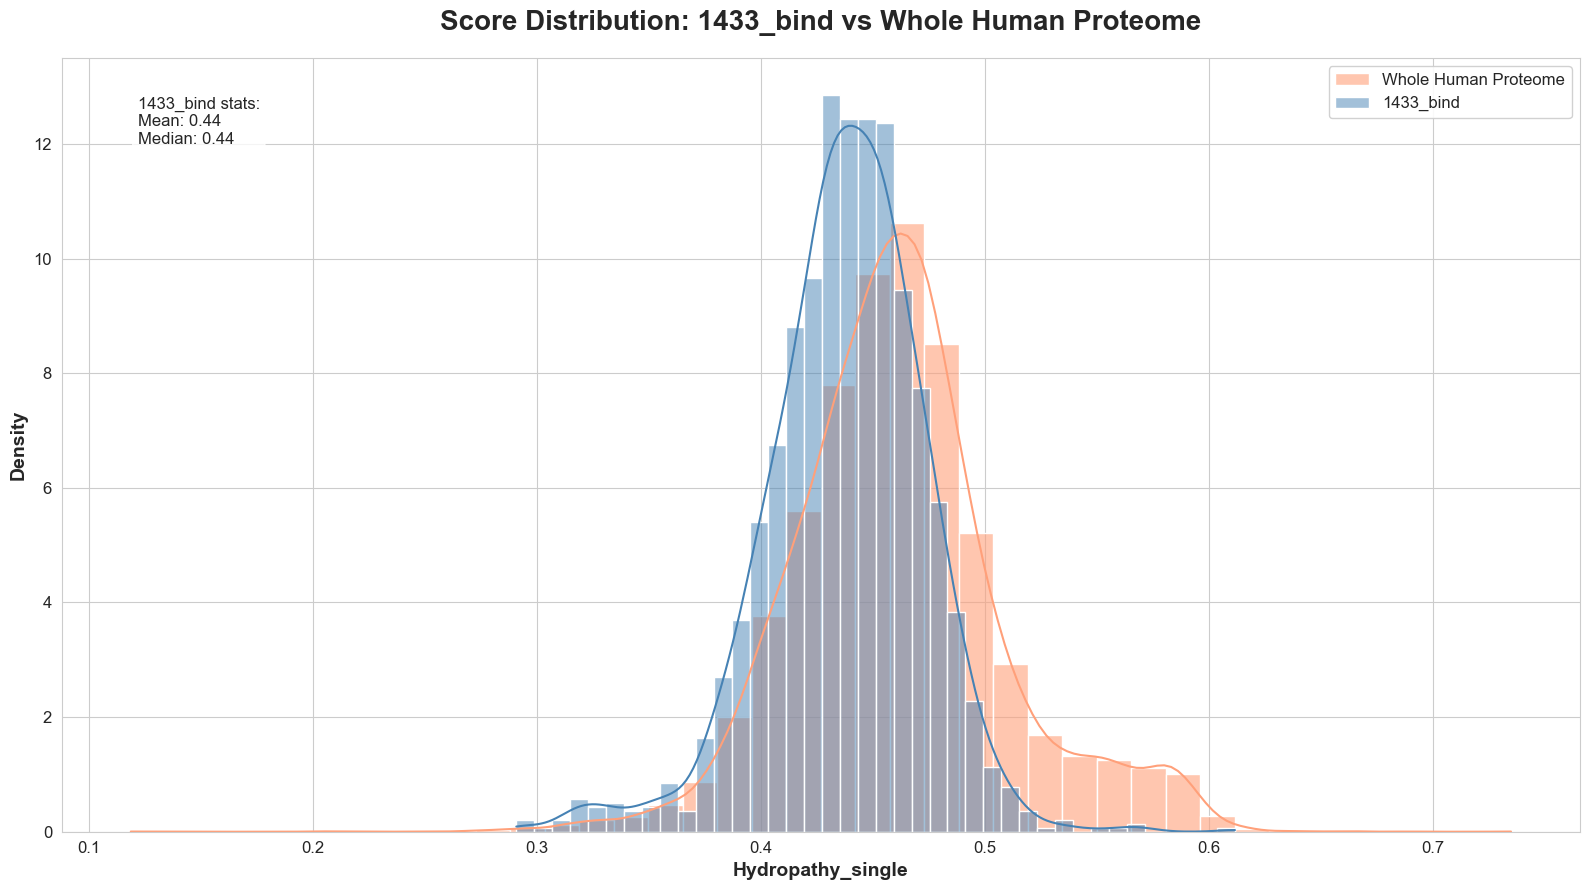

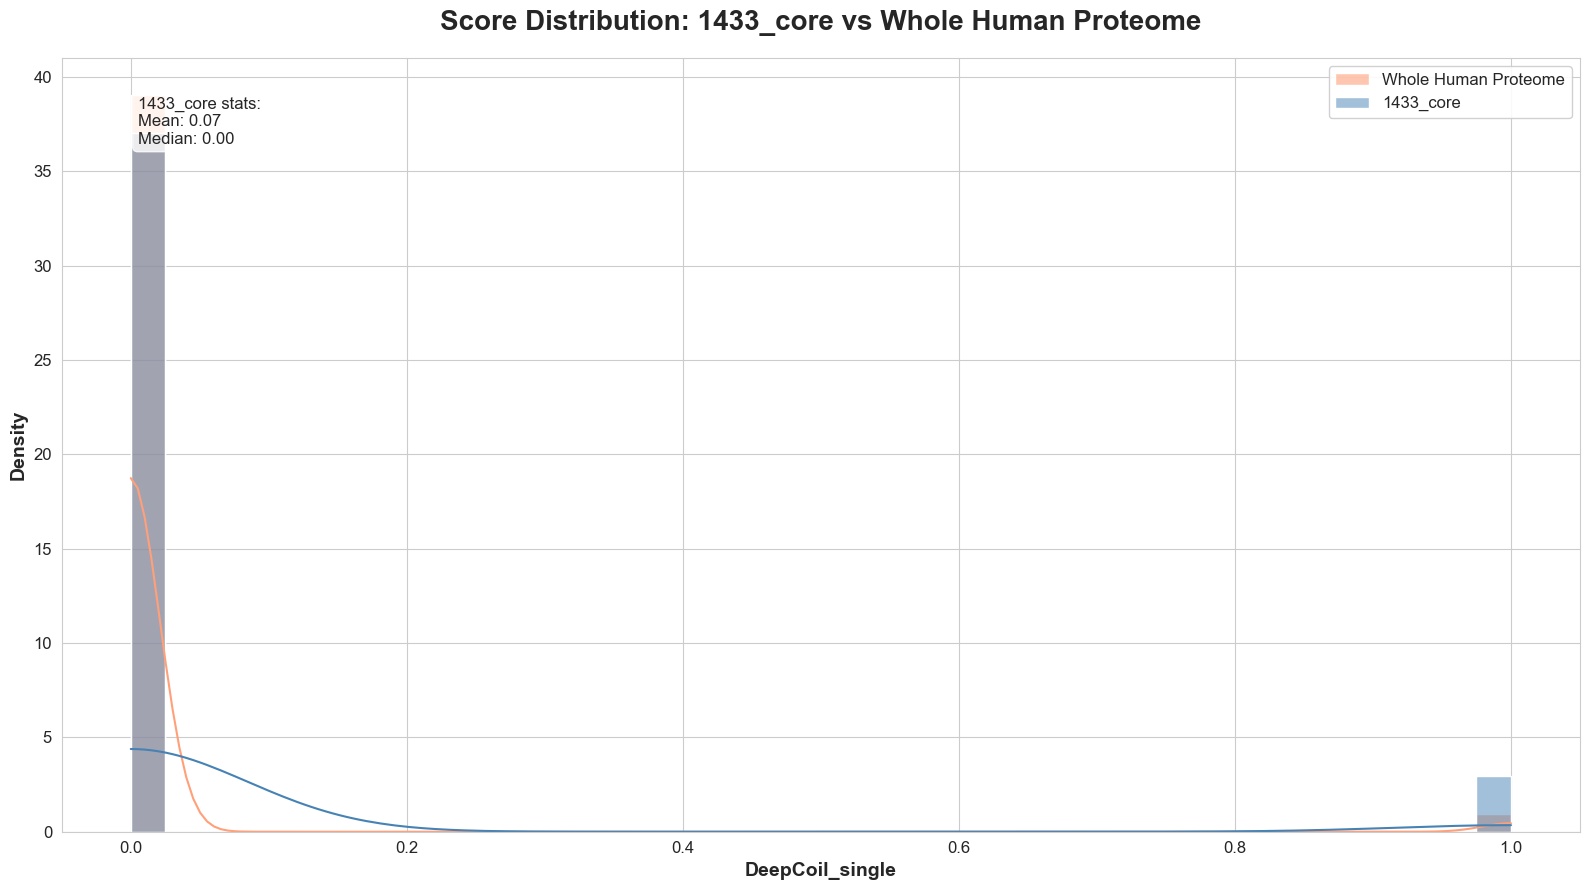

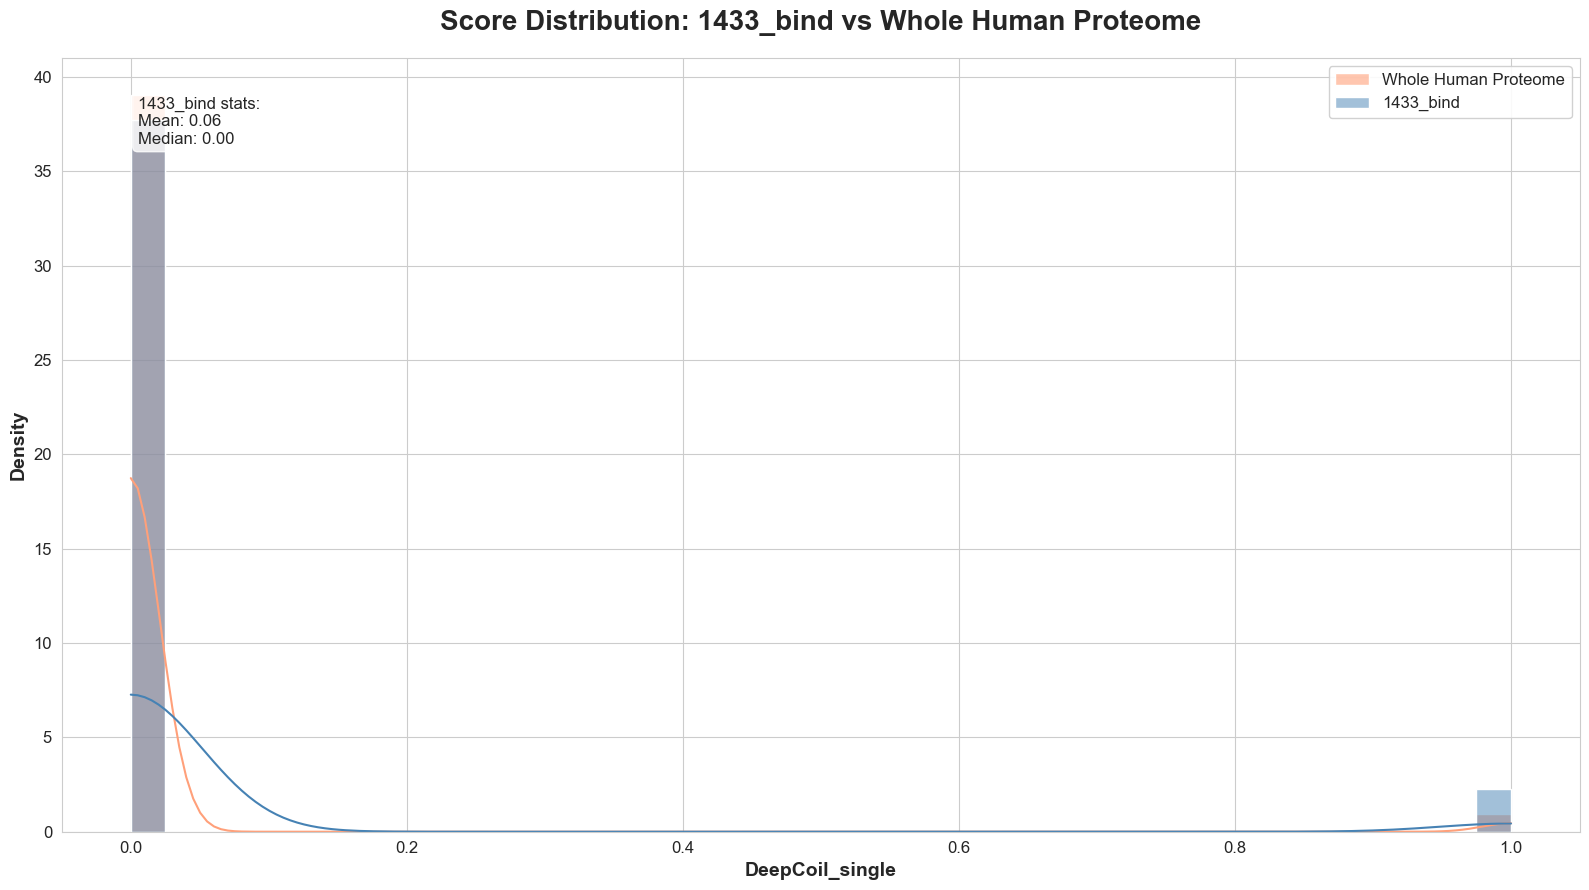

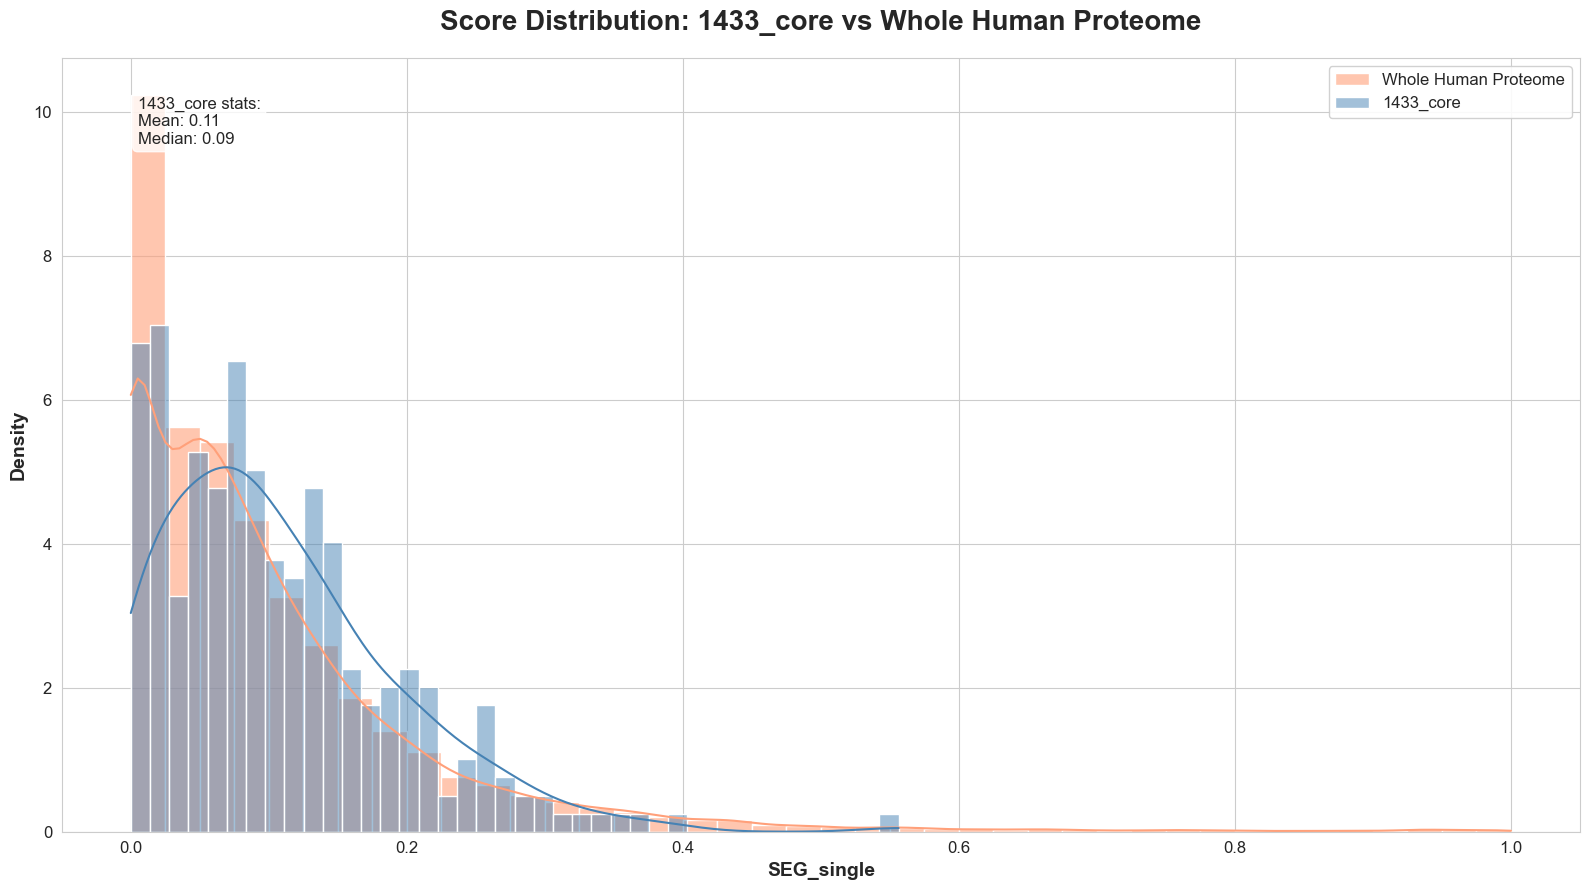

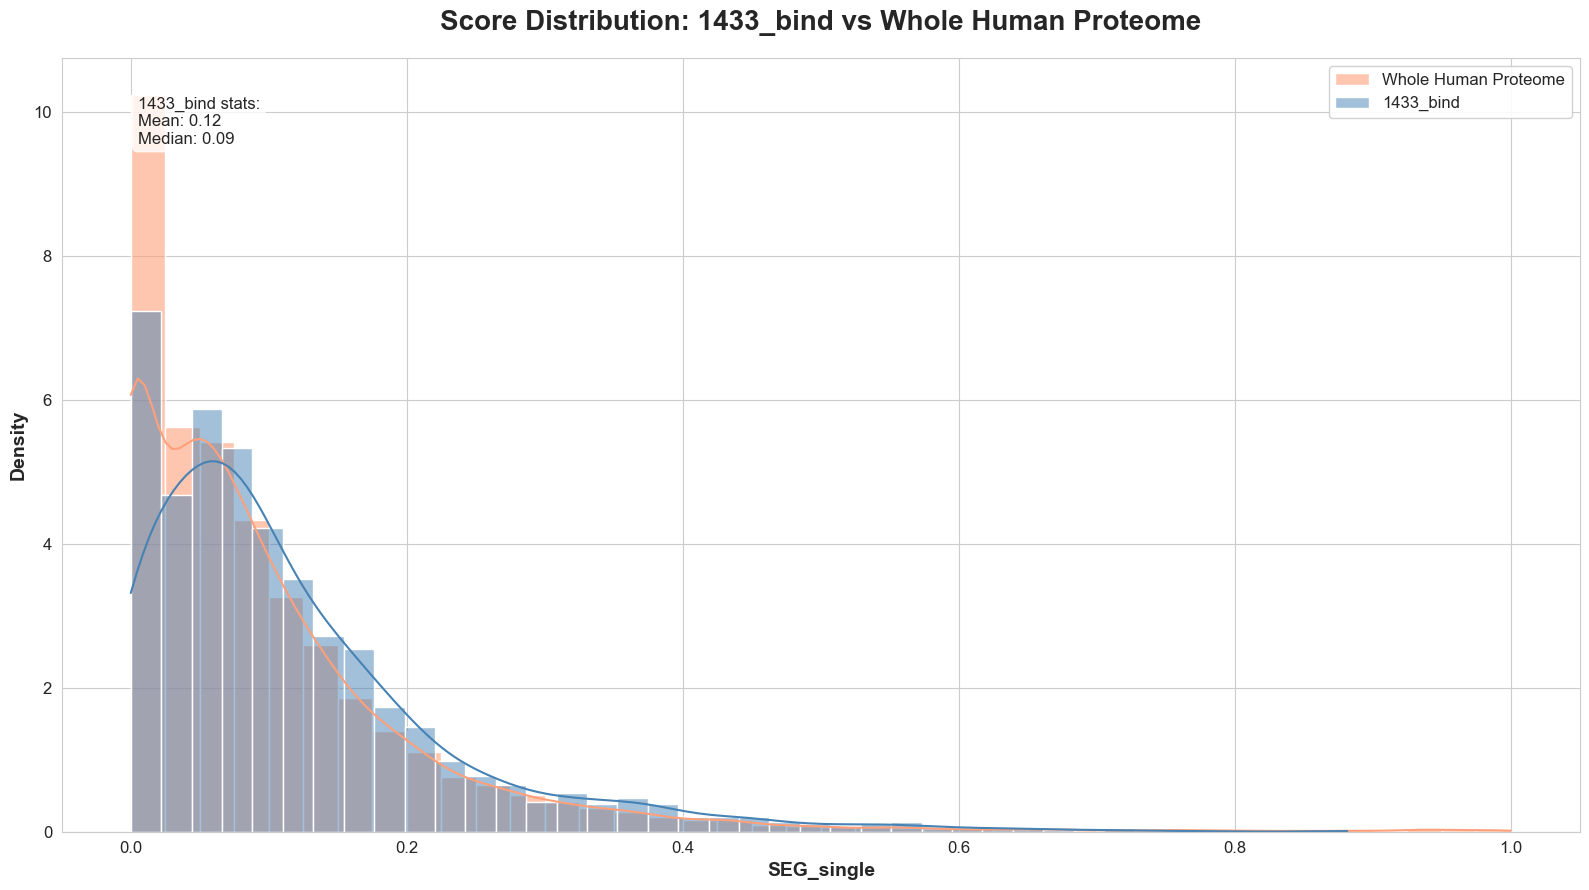

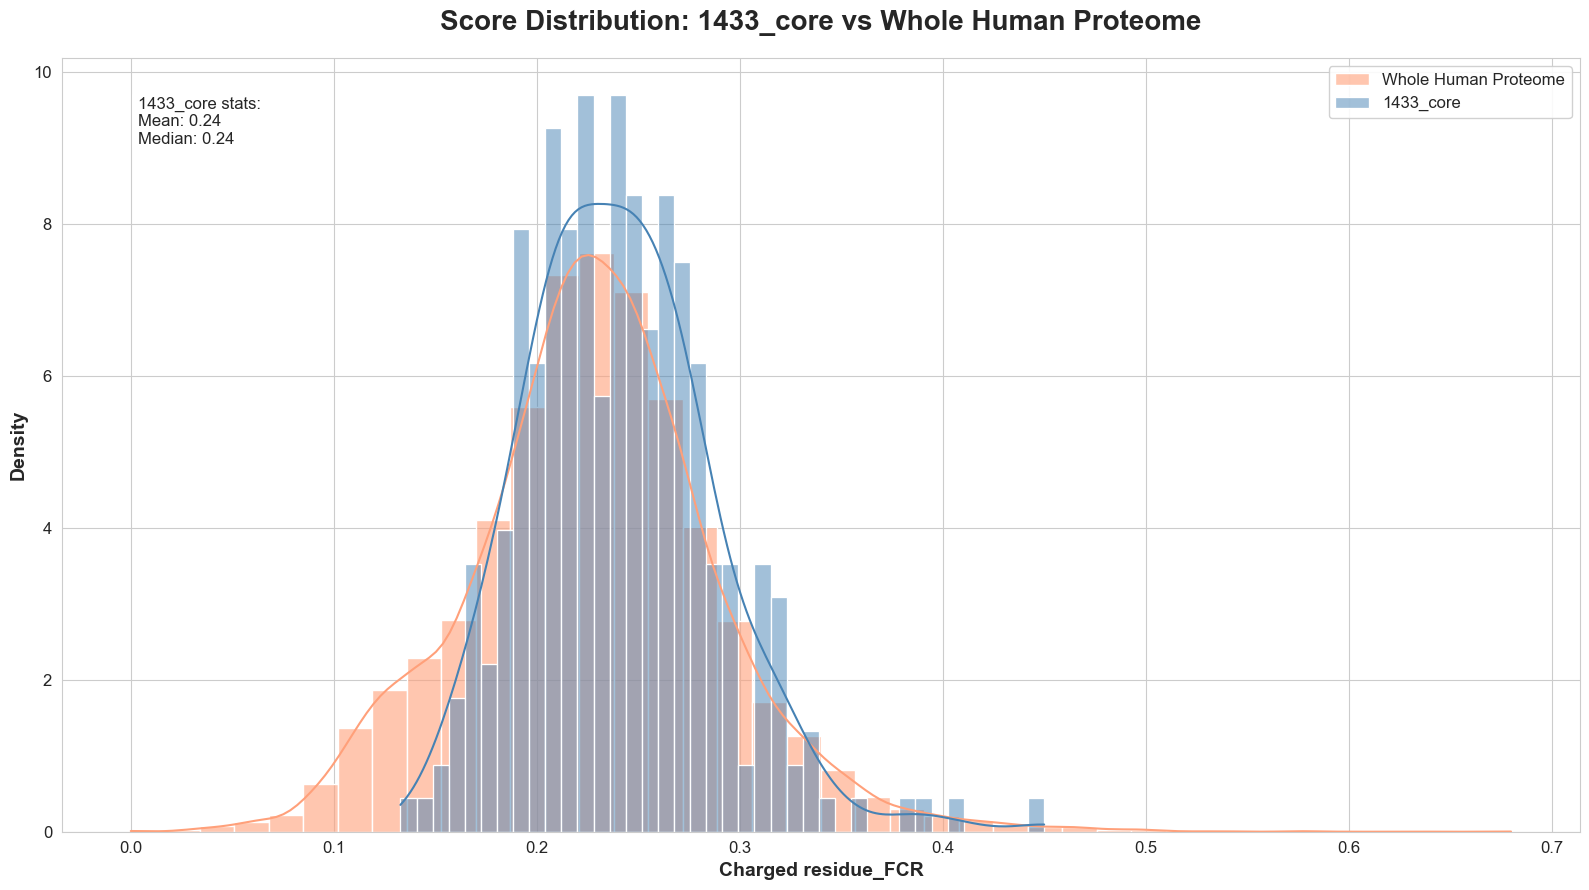

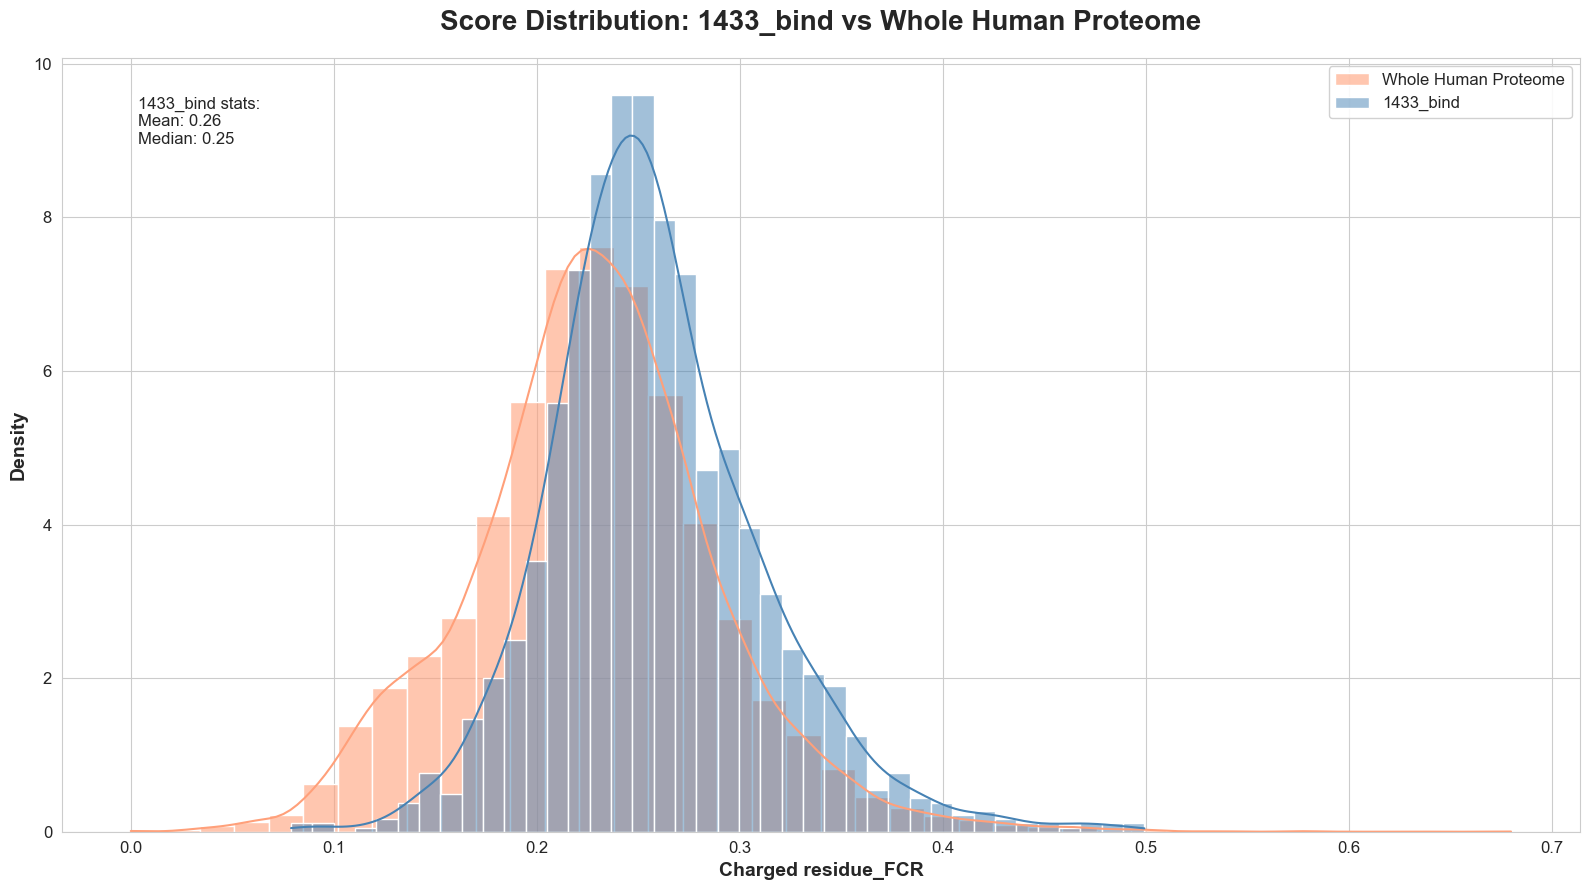

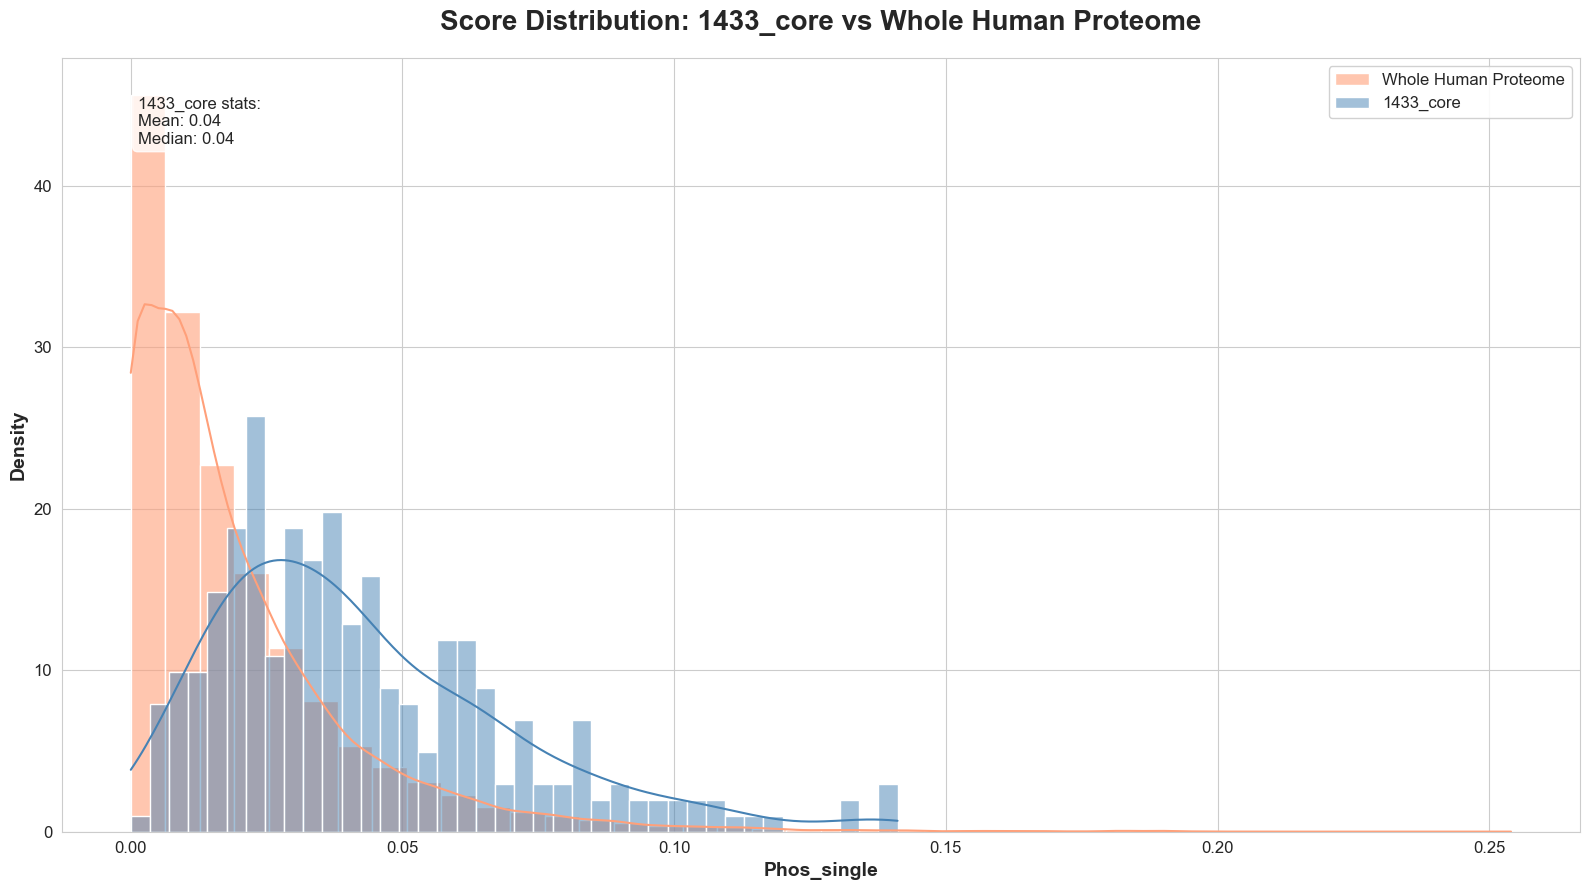

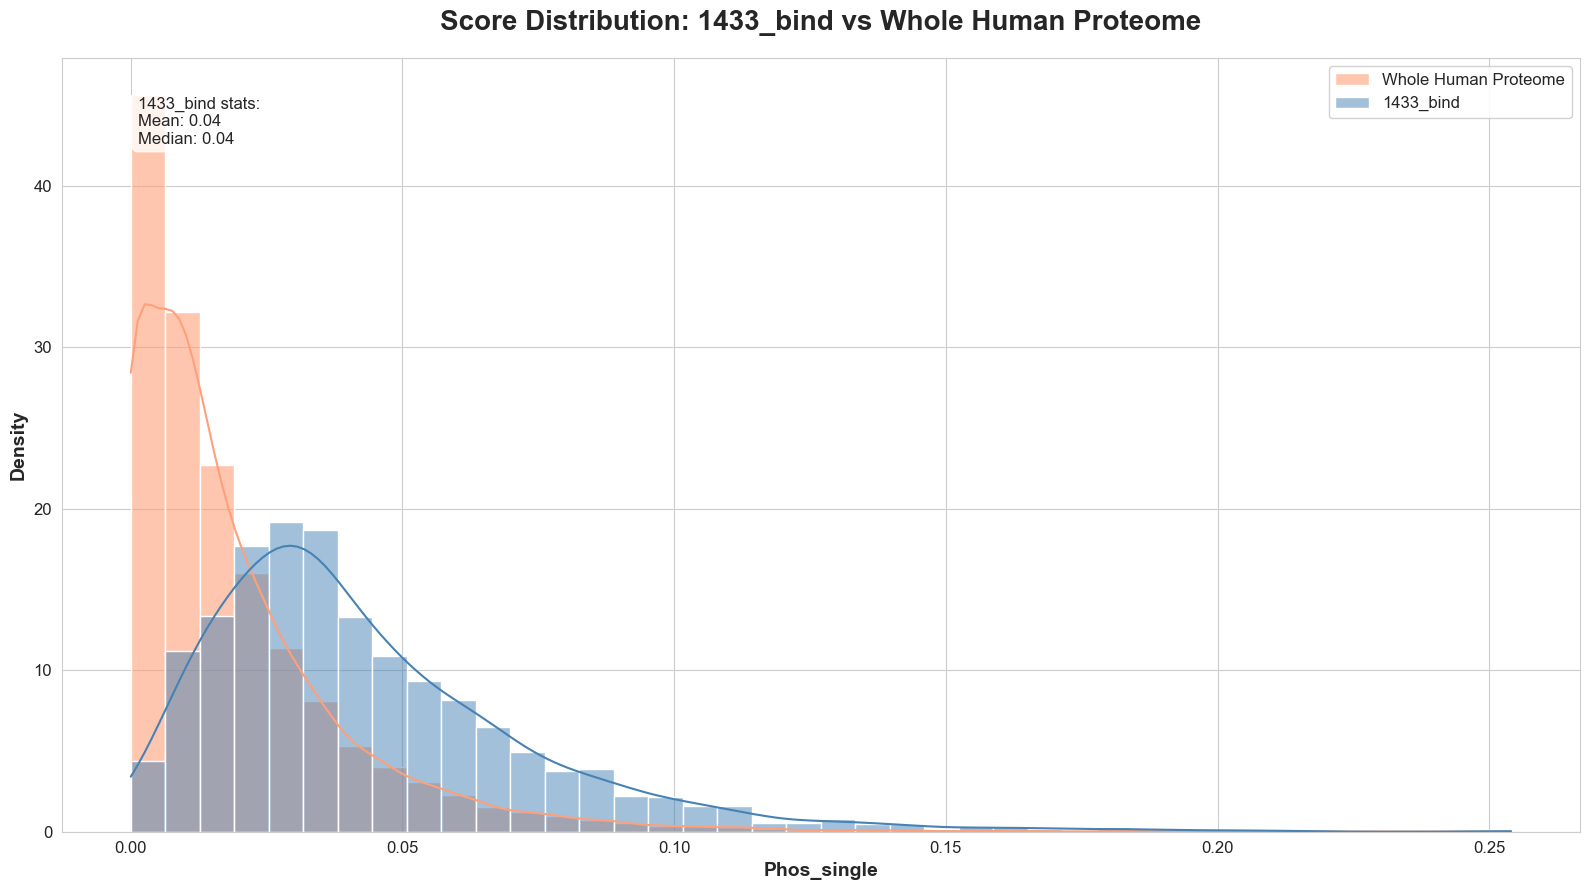

In [42]:
for column in score_columns:
    if column not in ['uniprot_id','Sequence']:
        if column not in phasepred_score_columns:
            distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_PhaSePred,column, 'uniprot_id')
            distribution_go(Protein_1433_interactome,"1433_bind", df_PhaSePred,column, 'uniprot_id')

In [43]:
# calculate the distribution of protein length of 14-3-3 binding protein

# write a code to iterate through the protein in uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# save into a csv file, for each uniprot id, save the length of the protein

import pandas as pd
from Bio import SeqIO

def calculate_protein_lengths(fasta_file, output_csv):
    data = []
    
    # Parsing the FASTA file
    for record in SeqIO.parse(fasta_file, "fasta"):
        if '|' in record.id:
            uniprot_id = record.id.split('|')[1]
        else:
            uniprot_id = record.id
        protein_length = len(record.seq)
        
        # Append the data to the list
        data.append([uniprot_id, protein_length])
    
    # Create a DataFrame from the list
    df = pd.DataFrame(data, columns=['UniProt ID', 'Protein Length'])
    
    # Save the DataFrame to a CSV file
    df.to_csv(output_csv, index=False)

# Define the input FASTA file and output CSV file
fasta_file = 'data/uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta'
output_csv = 'data/protein_lengths.csv'

# Call the function
calculate_protein_lengths(fasta_file, output_csv)

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compare_protein_length_distribution(uniprot_ids, protein_lengths_csv):
    # Load the protein lengths CSV into a DataFrame
    df = pd.read_csv(protein_lengths_csv)
    
    # Filter out proteins with length 10 or less
    df = df[(df['Protein Length'] > 100)&(df['Protein Length'] < 5000)]
    
    # Filter the DataFrame to get the lengths of the proteins specified in the list of UniProt IDs
    filtered_df = df[df['UniProt ID'].isin(uniprot_ids)]

    # Print the shortest and longest protein length in the whole dataset
    shortest_protein_length_whole = df['Protein Length'].min()
    longest_protein_length_whole = df['Protein Length'].max()
    print(f"Shortest protein length in the whole dataset: {shortest_protein_length_whole}")
    print(f"Longest protein length in the whole dataset: {longest_protein_length_whole}")

    # Print the shortest and longest protein length in the filtered dataset
    if not filtered_df.empty:
        shortest_protein_length_filtered = filtered_df['Protein Length'].min()
        longest_protein_length_filtered = filtered_df['Protein Length'].max()
        print(f"Shortest protein length in the filtered dataset: {shortest_protein_length_filtered}")
        print(f"Longest protein length in the filtered dataset: {longest_protein_length_filtered}")
        print(f"There are {len(filtered_df)} proteins in the dataset")
    else:
        print("No proteins found in the filtered dataset with length > 100.")
    
    # Set up the plots
    plt.figure(figsize=(12, 6))
    
    # Plot the distribution of the whole proteome
    sns.kdeplot(df['Protein Length'], label='Whole Proteome', shade=True)
    
    # Plot the distribution of the specified proteins' lengths
    sns.kdeplot(filtered_df['Protein Length'], label='Selected Proteins', shade=True)
    
    # Add titles and labels
    plt.title('Protein Length Distribution Comparison')
    plt.xlabel('Protein Length')
    plt.ylabel('Density')
    plt.legend()
    
    # Show the plot
    plt.show()

# Define the path to the protein lengths CSV file
protein_lengths_csv = 'data/protein_lengths.csv'

Shortest protein length in the whole dataset: 101
Longest protein length in the whole dataset: 4981
Shortest protein length in the filtered dataset: 126
Longest protein length in the filtered dataset: 3926
There are 285 proteins in the dataset


/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/329077515.py:35: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Protein Length'], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/329077515.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_df['Protein Length'], label='Selected Proteins', shade=True)


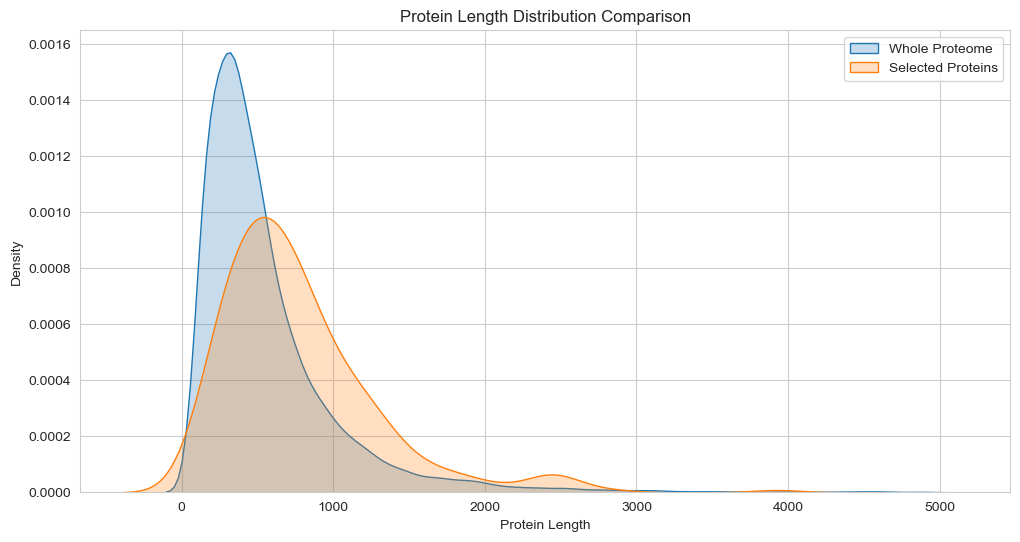

Shortest protein length in the whole dataset: 101
Longest protein length in the whole dataset: 4981
Shortest protein length in the filtered dataset: 103
Longest protein length in the filtered dataset: 4861
There are 1733 proteins in the dataset


/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/329077515.py:35: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Protein Length'], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/329077515.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_df['Protein Length'], label='Selected Proteins', shade=True)


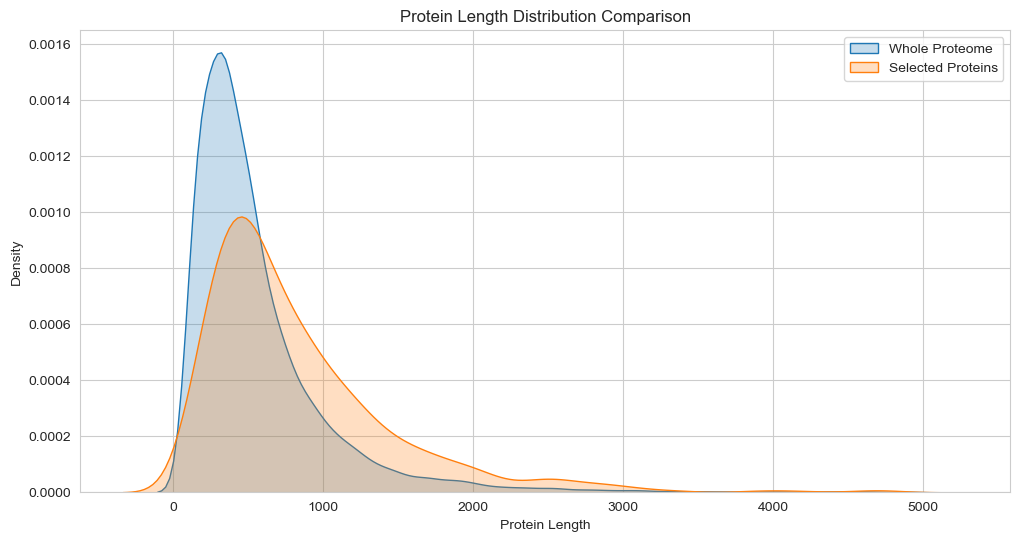

In [45]:
compare_protein_length_distribution(Protein_1433_interactome_known_motif, protein_lengths_csv)
compare_protein_length_distribution(Protein_1433_interactome, protein_lengths_csv)

## PLM for condensation

task 12: employed protein language models ESM2 to extract the protein level embeddings for each protein in the human proteome

In [ ]:
# 服务器

task 13: download the known condensation proteins dataset, we annotated the embeddings for known condensation proteins dataset (ref) from XXX experimentally validated PS proteins from PhaSepDB, LLPSDB, and PhaSePro

In [46]:
# PhaSepDB
# http://db.phasep.pro/

In [47]:
# LLPSDB
# http://www.bio-comp.org.cn/llpsdb/home.html

In [48]:
# PhaSePro
# https://phasepro.elte.hu/

task 14: protein level embeddings for each protein in the human proteome clustering using UMAP to visualize protein-wide sequence characteristics, mapping 14-3-3 binding proteins and also mapping known condensation proteins

In [ ]:
# 服务器

# 2	Intrinsically Disordered Regions Define the Context of 14-3-3 Binding Sites

2.1	Characterization of IDR Properties Around Binding Sites

task 14: predict IDR score of 14-3-3 binding sites using IUPred2A

In [49]:
# https://iupred2a.elte.hu/
# download IUPred2A package and put into src/files folder 

In [50]:
# uniprot download all the human reviewed protein sequence uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# https://www.uniprot.org/uniprotkb?query=reviewed%3Atrue&facets=model_organism%3A9606

In [51]:
# write a code to iterate through the protein in uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# import iupred2a_lib 
# Predict using 'iupred2a_lib.iupred(sequence)'. Using the optional arg 'mode' it can be selected whether to predict long or short disorder. 
# iterate the fasta file, for each sequence, then predict it with iupred2a using 'iupred2a_lib.iupred(sequence)'
# predict anchor2 using (iupred2a_lib.anchor2(sequence) ) 
# save the each prediction result (iupred and anchor score) as a csv file, using uniprotid as the csv file name

In [52]:
# !pip install biopython

In [53]:
fasta_file = "data/uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta"
if not os.path.isfile(fasta_file):
    print(f"FASTA file '{fasta_file}' not found.")
    sys.exit(1)

In [54]:
import os
import sys
import pandas as pd
import numpy as np
import src.files.iupred2a.iupred2a_lib as iupred2a_lib
from Bio import SeqIO

def process_sequence(uniprot_id, sequence, iupred_type, path, anchor):
    try:
        # Create the directory if it doesn't exist
        if not os.path.exists(path):
            os.makedirs(path)
        # Predict disorder using iupred2a_lib
        iupred_scores = iupred2a_lib.iupred(sequence, iupred_type)[0]

        # Predict anchor regions using iupred2a_lib if anchor is enabled
        anchor_scores = iupred2a_lib.anchor2(sequence)[0] if anchor else [None] * len(sequence)

        # Prepare the data for saving into a CSV file
        data = {
            "position": list(range(1, len(sequence) + 1)),
            "amino_acid": list(sequence),
            "iupred_score": iupred_scores,
            "anchor_score": anchor_scores,
        }

        # Create a DataFrame from the data
        df = pd.DataFrame(data)

        # Save the DataFrame to a CSV file named by the UniProt ID
        csv_filename = os.path.join(path, f"{uniprot_id}.csv")
        df.to_csv(csv_filename, index=False)
        print(f"Results saved for {uniprot_id} in {csv_filename}")
    except ImportError:
        sys.exit("ERROR: The import of iupred2a_lib failed! Most likely the PYTHONPATH has not been set correctly according to the README file.")


def human_proteome_disorder_cal(fasta_file):
    # Parsing the FASTA file
    for record in SeqIO.parse(fasta_file, "fasta"):
        uniprot_id = record.id.split('|')[1] if '|' in record.id else record.id
        sequence = str(record.seq)
        process_sequence(uniprot_id, sequence, "long", "data/human_proteome_discorder_anchor_score", 1)

In [55]:
# human_proteome_disorder_cal(fasta_file)

task 15: figure we confirm that 14-3-3 binding sites are predicted to have higher IDR score than all s/t sites (Figure 2A)

In [56]:
# # aggregate the calculated IDR and anchor score for all the S/T sites in the human proteome
# import pandas as pd
# import os

# def collect_st_amino_acids(folder_path):
#     # Initialize an empty DataFrame to hold the collected data
#     collected_data = pd.DataFrame()

#     # Iterate through each file in the folder
#     for filename in os.listdir(folder_path):
#         if filename.endswith('.csv'):
#             file_path = os.path.join(folder_path, filename)
#             df = pd.read_csv(file_path)
#             # Filter the DataFrame for rows where amino_acid is 'S' or 'T'
#             filtered_df = df[df['amino_acid'].isin(['S', 'T'])]

#             filename_pre = filename.split('.')[0]
#             # Rename the index to match the format filename_amino_acid_position
#             filtered_df.index = [f"{filename_pre}_{row['amino_acid']}_{row['position']}" for _, row in filtered_df.iterrows()]

#             # Append the filtered data to the collected_data DataFrame
#             collected_data = pd.concat([collected_data, filtered_df])

#     return collected_data

# # Define the folder path
# folder_path = 'data/human_proteome_discorder_anchor_score'

# # Collect the data
# st_amino_acids_df = collect_st_amino_acids(folder_path)

# # Print the collected DataFrame
# # print(st_amino_acids_df)

# # Optionally, save the collected DataFrame to a CSV file
# st_amino_acids_df.to_csv('data/collected_st_amino_acids_idrscore_anchorscore.csv')

In [57]:
# download phosphorylation dataset from phosphorysite
# name as Phosphorylation_site_dataset.xlsx
def process_mod_rsd(mod_rsd):
    """
    Process the MOD_RSD value to replace a pattern like S119-p with S_119.
    
    Parameters:
    mod_rsd (str): The original MOD_RSD value.
    
    Returns:
    str: The processed MOD_RSD value.
    """
    if '-' in mod_rsd:
        parts = mod_rsd.split('-')
        return f"{parts[0][0]}_{parts[0][1:]}"
    return mod_rsd


def collect_human_sites(df):
    """
    Collects all human dataset entries from the provided DataFrame where the 8th position letter 
    in the SITE_+/-7_AA column is lowercase 's' or 't'. Each row in the returned DataFrame is 
    named using the format ACC_ID_MOD_RSD with processed MOD_RSD.
    
    Parameters:
    df (pd.DataFrame): Input DataFrame with the protein modification data.
    
    Returns:
    pd.DataFrame: Filtered and indexed DataFrame.
    """
    
    # Filter the DataFrame for human datasets
    human_df = df[df['ORGANISM'] == 'human']

    # Further filter the DataFrame where the 8th position letter in the SITE_+/-7_AA column is lowercase 's' or 't'
    filtered_human_df = human_df[human_df['SITE_+/-7_AA'].str[7].isin(['s', 't'])]

    # Process the MOD_RSD values
    filtered_human_df['MOD_RSD'] = filtered_human_df['MOD_RSD'].apply(process_mod_rsd)

    # Set the index using the format ACC_ID_MOD_RSD
    filtered_human_df.index = filtered_human_df.apply(lambda row: f"{row['ACC_ID']}_{row['MOD_RSD']}", axis=1)

    return filtered_human_df

phosphodata_path = "data/Phosphorylation_site_dataset.xlsx"

df = pd.read_excel(phosphodata_path, skiprows=3)

# Apply the function
filtered_human_df = collect_human_sites(df)

# # Print the filtered DataFrame
# print(filtered_human_df)

# Optionally, save the filtered DataFrame to a CSV file
filtered_human_df.to_csv('data/konwn_human_phosphorylated_site_from_phosphosite.csv')

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/709218120.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_human_df['MOD_RSD'] = filtered_human_df['MOD_RSD'].apply(process_mod_rsd)


In [58]:
filtered_human_df = pd.read_csv('data/konwn_human_phosphorylated_site_from_phosphosite.csv')
konwn_human_phosphorylated_site = set(filtered_human_df["Unnamed: 0"])
len(konwn_human_phosphorylated_site)

200611

In [59]:
# preprocess the collected 14-3-3 site into a uniprot_aminoacid_postion index

def process_string(value):
    # Split the value by '/' to handle scenarios with multiple modifications
    parts = value.split('/')
    for part in parts:
        # Check if the first and last characters of the part match the criteria
        if part[0].isupper() and part[-1].islower() and part[0].upper() == part[-1].upper():
            return f"{part[0].upper()}_{part[1:-1]}"
    
    # If none of the parts match the criteria, return None or handle accordingly
    return None


def collect_1433_sites(df):
    """
    Collects 14-3-3 dataset entries from the provided DataFrame. Each row in the returned DataFrame is 
    named using the format ACC_ID with amino acid and position.
    
    Parameters:
    df (pd.DataFrame): Input DataFrame with the protein modification data.
    
    Returns:
    pd.DataFrame: Filtered and indexed DataFrame.
    """
    
    # Filter the DataFrame for human datasets
    filtered_df = df[df['label'] == 1]

    # Process the MOD_RSD values
    filtered_df['human Site and Mutation'] = filtered_df['human Site and Mutation'].apply(process_string)

    # Set the index using the format ACC_ID_MOD_RSD
    filtered_df.index = filtered_df.apply(lambda row: f"{row['human homology accession']}_{row['human Site and Mutation']}", axis=1)

    return filtered_df

phosphodata_path = "data/Table 1.csv"

df = pd.read_csv(phosphodata_path)

# Apply the function
filtered_1433_df = collect_1433_sites(df)

# # Print the filtered DataFrame
# print(filtered_1433_df)

# Optionally, save the filtered DataFrame to a CSV file
filtered_1433_df.to_csv('data/1433_phosphorylated_site.csv')

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/7348465.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['human Site and Mutation'] = filtered_df['human Site and Mutation'].apply(process_string)


In [60]:
filtered_1433_df = pd.read_csv('data/1433_phosphorylated_site.csv')
konwn_1433_site = set(filtered_1433_df["Unnamed: 0"])
len(konwn_1433_site)

428

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compare_protein_feature_distribution(uniprot_ids_1433, uniprot_ids_known_phospho, protein_lengths_csv, columnname):
    # Load the protein lengths CSV into a DataFrame
    df = pd.read_csv(protein_lengths_csv)
    
    # Filter the DataFrame to get the lengths of the proteins specified in the list of UniProt IDs
    filtered_1433_df = df[df["Unnamed: 0"].isin(uniprot_ids_1433)]
    filtered_known_phospho_df = df[df["Unnamed: 0"].isin(uniprot_ids_known_phospho)]    
    # Set up the plots
    plt.figure(figsize=(12, 6))
    
    # Plot the distribution of the whole proteome
    sns.kdeplot(df[columnname], label='Whole Proteome', shade=True)
    
    # Plot the distribution of the 1433 site
    sns.kdeplot(filtered_1433_df[columnname], label='1433 site', shade=True)

    # Plot the distribution of the phospho site
    sns.kdeplot(filtered_known_phospho_df[columnname], label='phospho site', shade=True)
    
    # Add titles and labels
    plt.title(f'{columnname} Distribution Comparison')
    plt.xlabel(f'{columnname}')
    plt.ylabel('Density')
    plt.legend()
    
    # Show the plot
    plt.show()

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/779504648.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[columnname], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/779504648.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_1433_df[columnname], label='1433 site', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/779504648.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_known_phospho_df[columnname], label='phospho site', shade=True)


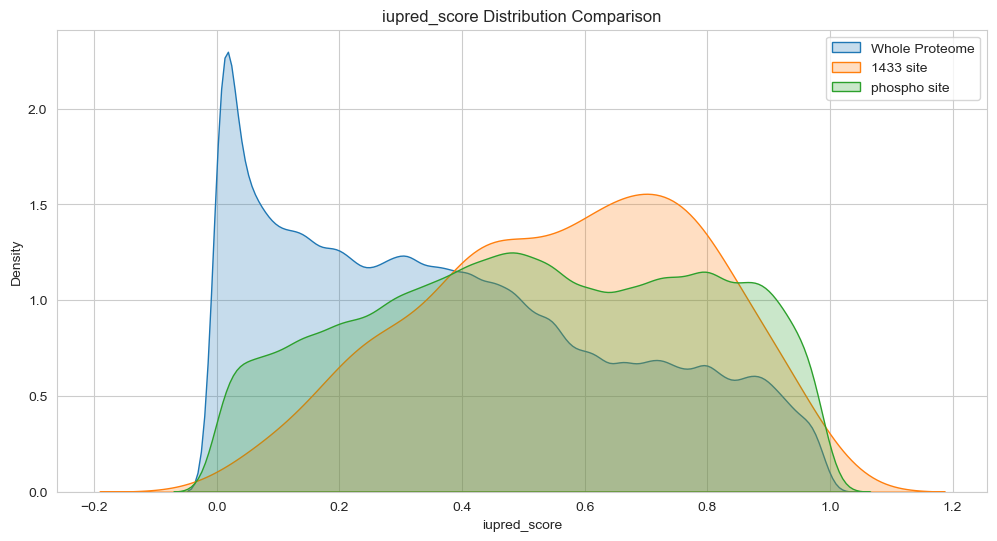

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/779504648.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[columnname], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/779504648.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_1433_df[columnname], label='1433 site', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/779504648.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_known_phospho_df[columnname], label='phospho site', shade=True)


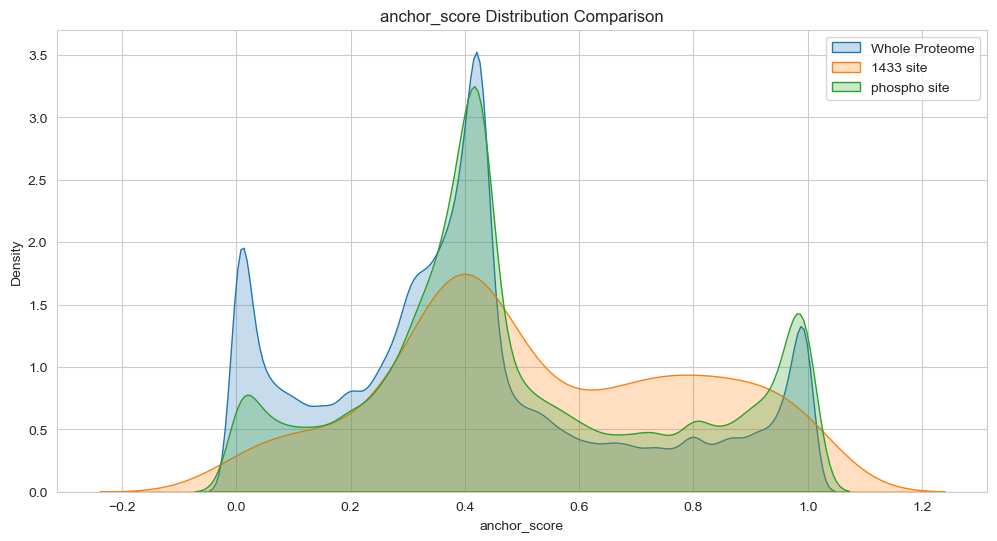

In [62]:
st_idrscore_anchorscore_path = 'data/collected_st_amino_acids_idrscore_anchorscore.csv'
compare_protein_feature_distribution(konwn_1433_site, konwn_human_phosphorylated_site, st_idrscore_anchorscore_path, "iupred_score")
compare_protein_feature_distribution(konwn_1433_site, konwn_human_phosphorylated_site, st_idrscore_anchorscore_path, "anchor_score")

2.2 Analysis of IDR Compactness and Flexibility

task 16: We used _2023_Tesei_IDRome to extract the 14-3-3 binding protein IDR properties and compare it with the all other human IDRs.
task 17: We found that 14-3-3 binding IDR have higher XX and lower XX (Figure 2B).We compared the v of IDRs containing 14-3-3 binding sites with all IDRs in humans, and found that 14-3-3 binding sites preferentially located in relatively compact IDRs with lower ν value (Figure 2C).

In [63]:
## download the IDRome dataset from
# https://github.com/KULL-Centre/_2023_Tesei_IDRome/blob/main/IDRome_DB.csv

In [64]:
df_1433 = pd.read_csv("data/Table 1.csv")
df_1433
# select positive human sample to see the distribution
df_pos_human = df_1433[(df_1433["label"] == 1)]
df_pos_human

,human homology accession,human homology site without letter,human Site and Mutation,label,PMID
0,P43681,467,S467s,1,20141511
1,P11362,779,S779s,1,23564461
2,P98177,32,T32t,1,20141511
3,P14136,8,S8s,1,20141511
4,P08151,640,S640s,1,20141511
...,...,...,...,...,...
782,Q53ET0,368,S368s,1,18626018
783,Q05086-2,485,T485t,1,28835500
784,P40818,718,S718s/S716A,1,17720156
785,P40818,718,S718s,1,17720156


In [65]:
df_idr = pd.read_csv("data/IDRome_DB.csv")
df_idr

,seq_name,UniProt_ID,N,nu,SPR,ete2_Rg2,S,Delta,Rg/nm,Ree/nm,...,gene_name,QCDpred,z_delta_+-,z_omega_pi,z_omega_+,z_omega_-,z_omega_h,fdomain,nu_svr,SPR_svr
0,A0A024RBG1_145_181,A0A024RBG1,37,0.558,10.284649,6.304027,0.933961,0.225950,1.606561,3.843011,...,NUDT4B,0.254463,0.000000,0.000000,0.000000,0.000000,-0.531910,0.000000,0.565,10.288
1,A0A075B6T7_1_32,A0A075B6T7,32,0.525,10.092351,6.114494,0.901807,0.212670,1.448141,3.390487,...,TRAV6,0.659342,0.000000,0.054230,-0.043142,0.000000,0.061436,0.000000,0.532,10.107
2,A0A087WTH1_1_67,A0A087WTH1,67,0.532,10.160125,6.069995,0.822738,0.199126,2.243991,5.283533,...,TMEM265,0.661272,-1.094918,0.000000,0.384885,2.281943,1.092688,0.298507,0.537,10.167
3,A0A087WTH5_1_132,A0A087WTH5,132,0.496,10.049124,6.150972,0.798438,0.188978,3.034005,7.119714,...,KCNE1B,0.445861,0.000000,-0.463316,0.799692,0.000000,0.627563,0.000000,0.509,10.018
4,A0A087WV53_1_46,A0A087WV53,46,0.567,10.212765,6.439589,0.882210,0.214786,1.882622,4.607908,...,SPEGNB,0.313998,0.000000,0.000000,1.947253,0.000000,0.090132,0.369565,0.578,10.316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28053,Q9Y6Z4_1_181,Q9Y6Z4,181,0.493,10.006512,5.748098,0.799905,0.210890,3.791956,8.607822,...,KIF25-AS1,0.396007,0.000000,0.000000,-1.319891,0.000000,0.163169,0.000000,0.520,9.993
28054,Q9Y6Z5_1_254,Q9Y6Z5,254,0.528,9.830710,6.153759,0.896173,0.221422,4.586832,10.808776,...,AFDN-DT,0.374082,0.000000,0.000000,-2.182869,0.000000,2.214949,0.000000,0.537,9.984
28055,Q9Y6Z7_1_109,Q9Y6Z7,109,0.546,10.025622,6.175505,0.935857,0.216970,3.011145,7.113405,...,COLEC10,0.232155,0.106768,0.000000,0.451957,2.132808,1.114749,0.513761,0.513,10.072
28056,W6CW81_1_113,W6CW81,113,0.519,10.084249,6.191149,0.843169,0.193880,2.943990,6.975229,...,PYDC5,0.310500,0.404828,0.000000,0.554013,2.234693,-1.942090,0.451327,0.512,10.063


In [66]:
df_idr["start_site"] = df_idr["seq_name"].apply(lambda x: int(x.split('_')[1]))
df_idr["end_site"] = df_idr["seq_name"].apply(lambda x: int(x.split('_')[2]))

In [67]:
uniprot_set = set(df_pos_human["human homology accession"])
mask_uniprot = df_idr["UniProt_ID"].isin(uniprot_set)
df_idr_uniprot = df_idr.loc[mask_uniprot]

In [68]:
df_idr_uniprot_position = pd.DataFrame()

In [69]:
for index, row in df_idr_uniprot.iterrows():
    uniprot_id = row["UniProt_ID"]
    start = row["start_site"]
    end = row["end_site"]
    df_filter = df_pos_human[df_pos_human["human homology accession"] == uniprot_id]
    for i, r in df_filter.iterrows():
        position = int(r["human homology site without letter"])
        if position >= start and position <= end:
            df_tmp = row.to_frame().T
            df_tmp["position"] = position
            # print(df_tmp.columns)
            if len(df_idr_uniprot_position)<1:
                df_idr_uniprot_position = df_tmp
            else:
                df_idr_uniprot_position = pd.concat([df_idr_uniprot_position, df_tmp], join="inner", axis=0, ignore_index=True)

df_idr_uniprot_position = df_idr_uniprot_position.drop_duplicates()
df_idr_uniprot_position

,seq_name,UniProt_ID,N,nu,SPR,ete2_Rg2,S,Delta,Rg/nm,Ree/nm,...,z_omega_pi,z_omega_+,z_omega_-,z_omega_h,fdomain,nu_svr,SPR_svr,start_site,end_site,position
0,A0AVK6_339_867,A0AVK6,529,0.523,9.947836,6.01185,0.998467,0.224419,7.182813,16.68367,...,0.0,0.0,0.0,1.683024,0.0,0.51,9.963,339,867,396
1,A2RUS2_428_518,A2RUS2,91,0.515,10.144514,5.862947,0.917746,0.218117,2.674128,6.14078,...,0.0,0.247884,0.0,1.322073,0.0,0.523,10.115,428,518,472
2,A2RUS2_428_518,A2RUS2,91,0.515,10.144514,5.862947,0.917746,0.218117,2.674128,6.14078,...,0.0,0.247884,0.0,1.322073,0.0,0.523,10.115,428,518,490
3,O14558_1_70,O14558,70,0.535,10.102454,6.303353,0.924807,0.217909,2.246745,5.36746,...,0.0,0.0,0.0,-1.909216,0.214286,0.533,10.123,1,70,16
4,O14757_267_380,O14757,114,0.511,10.098739,5.832574,0.873191,0.214094,2.982306,6.892582,...,0.0,1.773948,0.0,-0.058386,0.0,0.519,10.059,267,380,296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,Q9Y4L5_1_200,Q9Y4L5,200,0.493,9.940396,6.617169,0.762973,0.187911,3.506595,8.574748,...,2.033237,0.0,-1.622998,0.08923,0.0,0.492,9.939,1,200,133
371,Q9Y580_94_266,Q9Y580,173,0.477,10.038347,5.785446,0.854602,0.193765,3.409178,7.791729,...,-1.75063,1.080551,1.281864,0.0,0.0,0.493,9.957,94,266,136
372,Q9Y580_94_266,Q9Y580,173,0.477,10.038347,5.785446,0.854602,0.193765,3.409178,7.791729,...,-1.75063,1.080551,1.281864,0.0,0.0,0.493,9.957,94,266,204
373,Q9Y6R0_214_609,Q9Y6R0,396,0.516,9.937861,6.199867,0.898182,0.210087,5.876164,13.868035,...,0.0,0.0,0.0,0.098674,0.0,0.518,9.983,214,609,324


In [70]:
feature = df_idr_uniprot_position.columns
feature
feature = feature.drop(['seq_name', 'UniProt_ID', 'start_site', 'end_site', 'position','N',"fasta", "is_btw_folded", "is_nterm",	"is_cterm",	"is_idp", "first", "last",	"N_FL",	"protein_name",	"gene_name"])

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot(column):
    bins=20
    df1_name = "1433_core"
    df2_name = "Whole Human IDR"
    df1 = df_idr_uniprot_position
    df2 = df_idr

    # Set the style for the plot
    # plt.style.use('seaborn')
    
    # Create the figure and axis objects
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot the histograms
    sns.histplot(data=df1, x=column, bins=bins, alpha=0.6, label=df1_name, kde=True, ax=ax, stat='density', color='#FFA07A',)
    sns.histplot(data=df2, x=column, bins=bins, alpha=0.6, label=df2_name, kde=True, ax=ax, stat='density', color='#4682B4')
    
    # Customize the plot
    ax.set_xlabel(column.capitalize(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribution of {column.capitalize()} in {df1_name} and {df2_name}', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    
    # Add a grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Customize the tick labels
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Add a text box with summary statistics
    stats_text = f"Summary Statistics:\n\n{df1_name}:\nMean: {df1[column].mean():.2f}\nMedian: {df1[column].median():.2f}\n\n{df2_name}:\nMean: {df2[column].mean():.2f}\nMedian: {df2[column].median():.2f}"
    plt.text(0.2, 0.95, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()

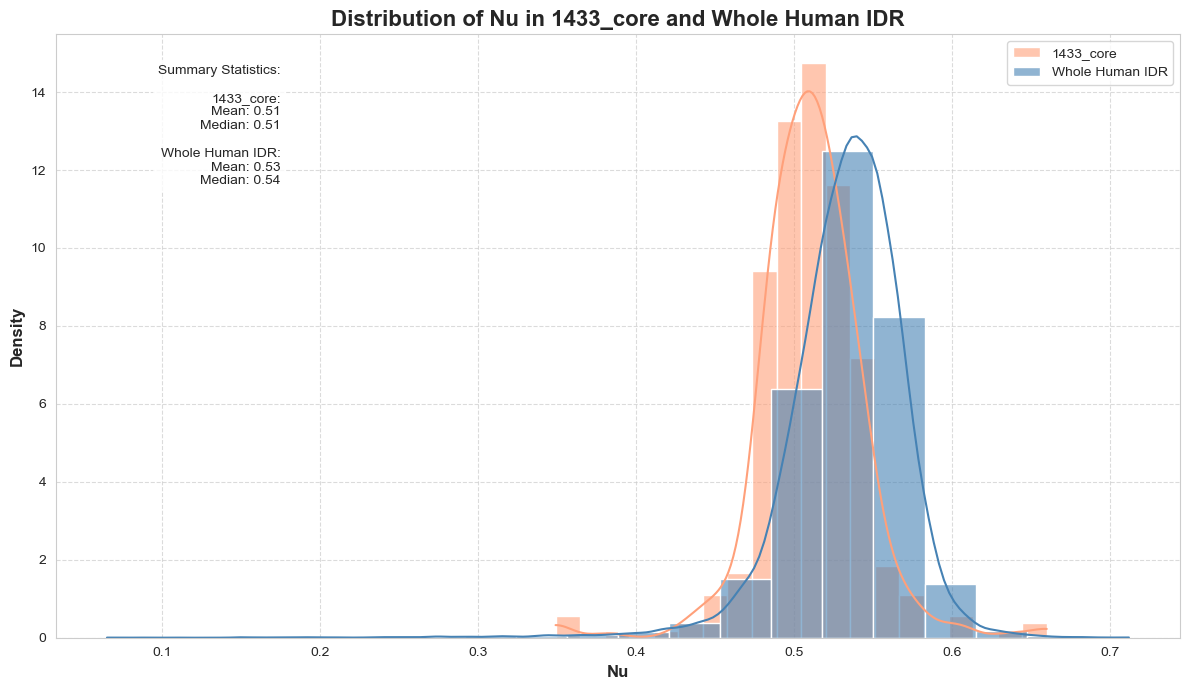

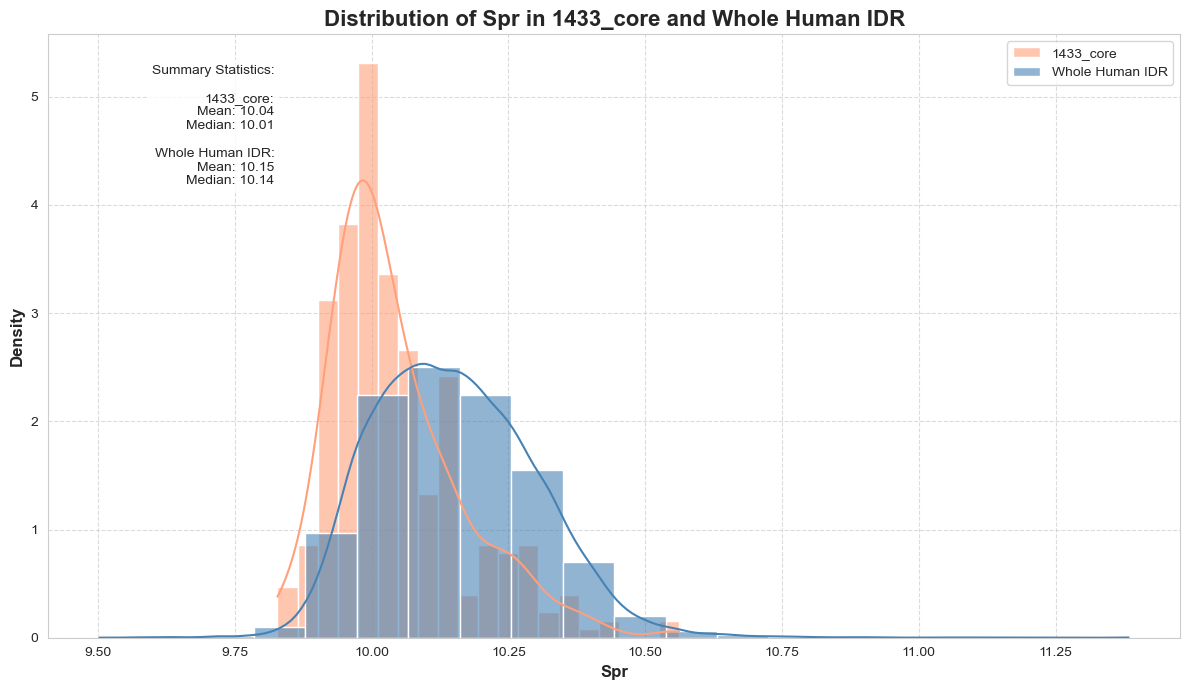

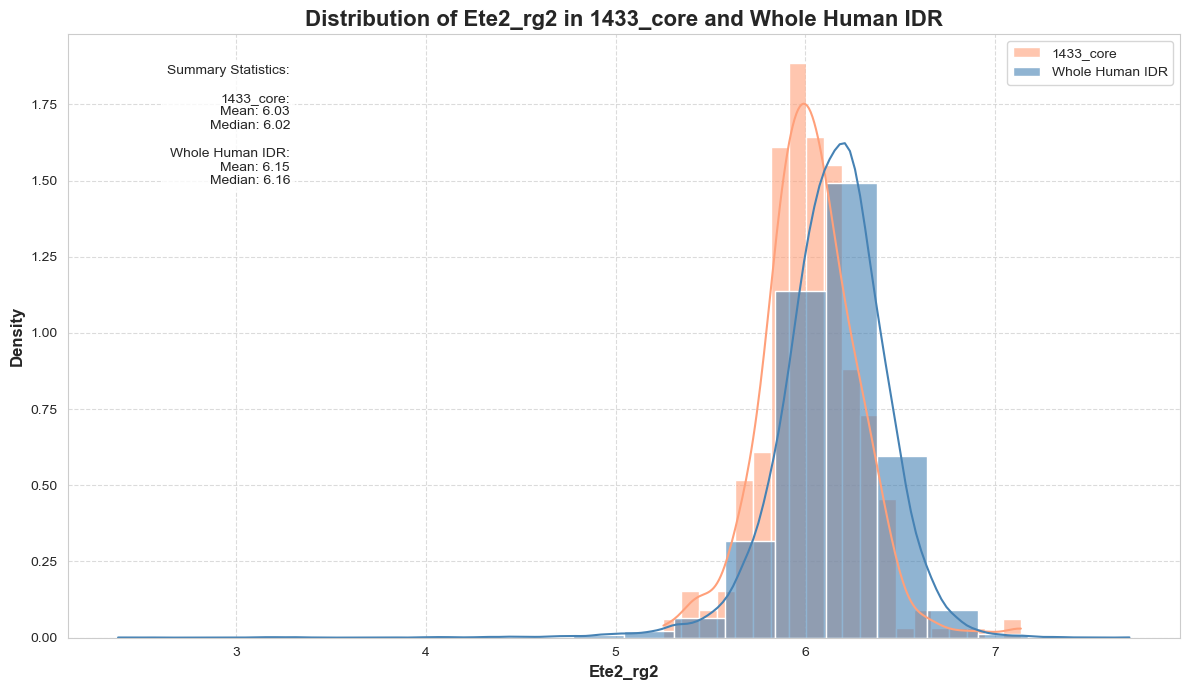

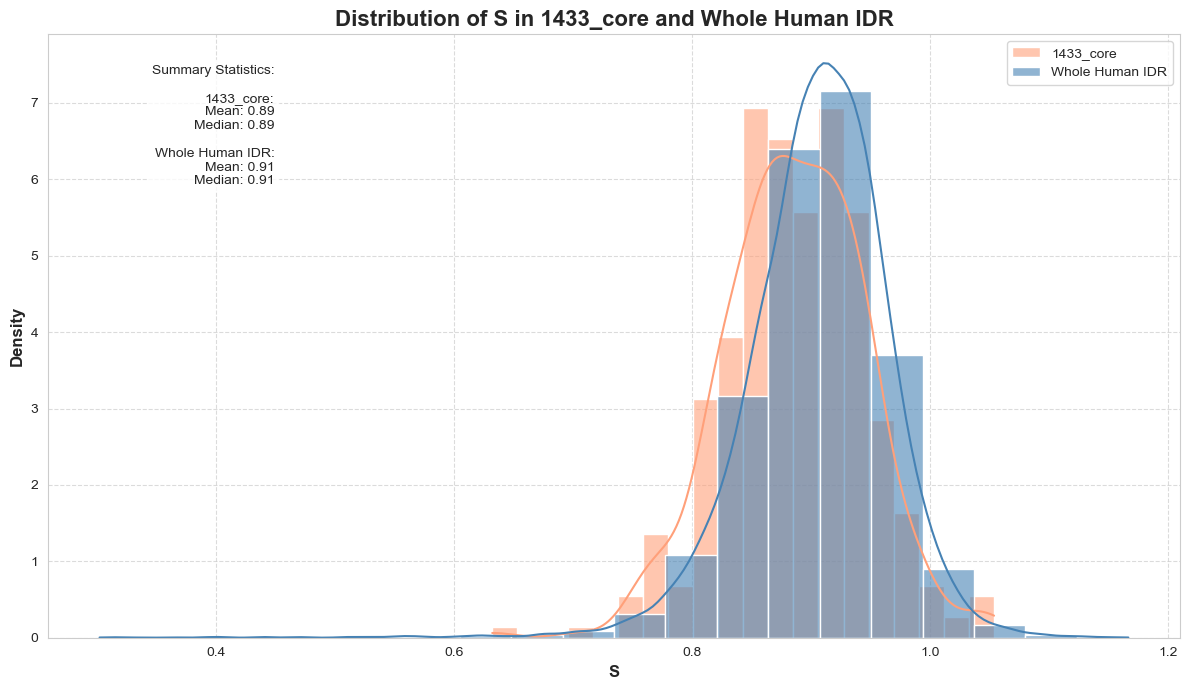

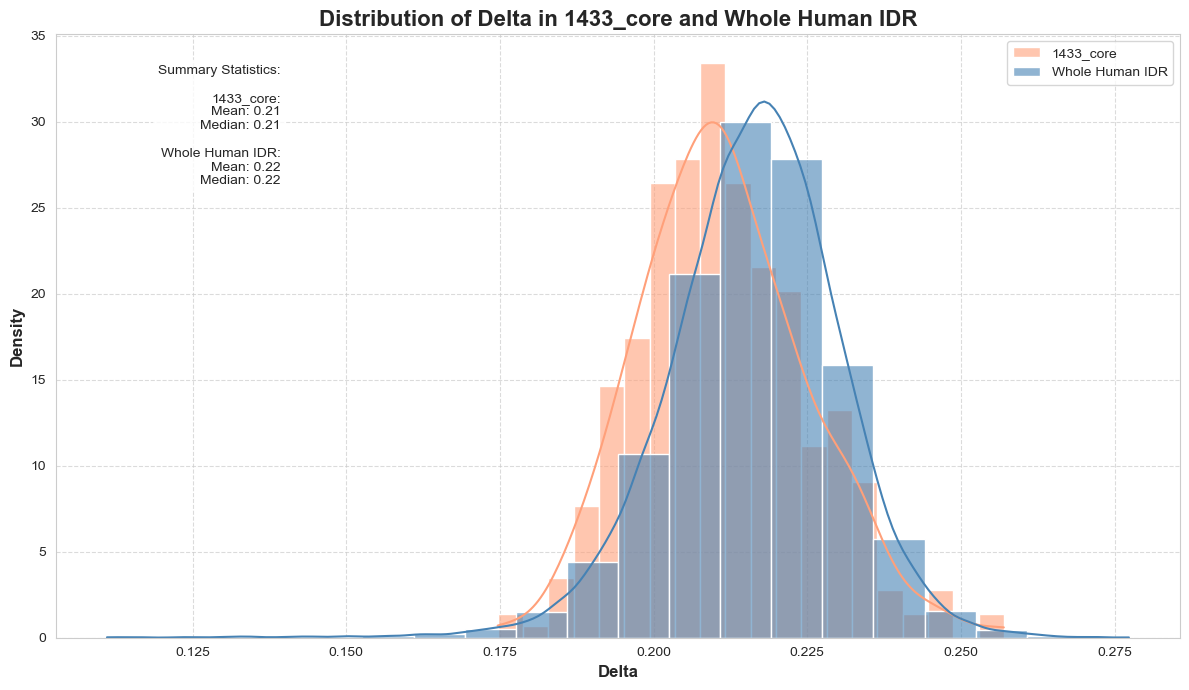

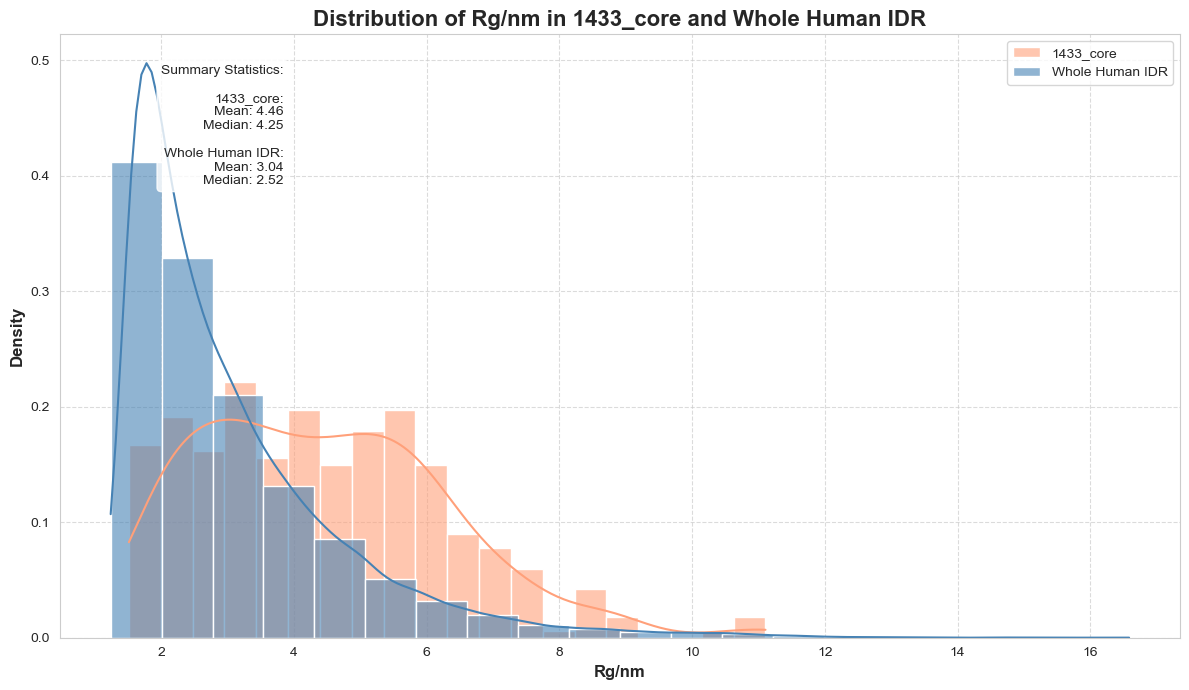

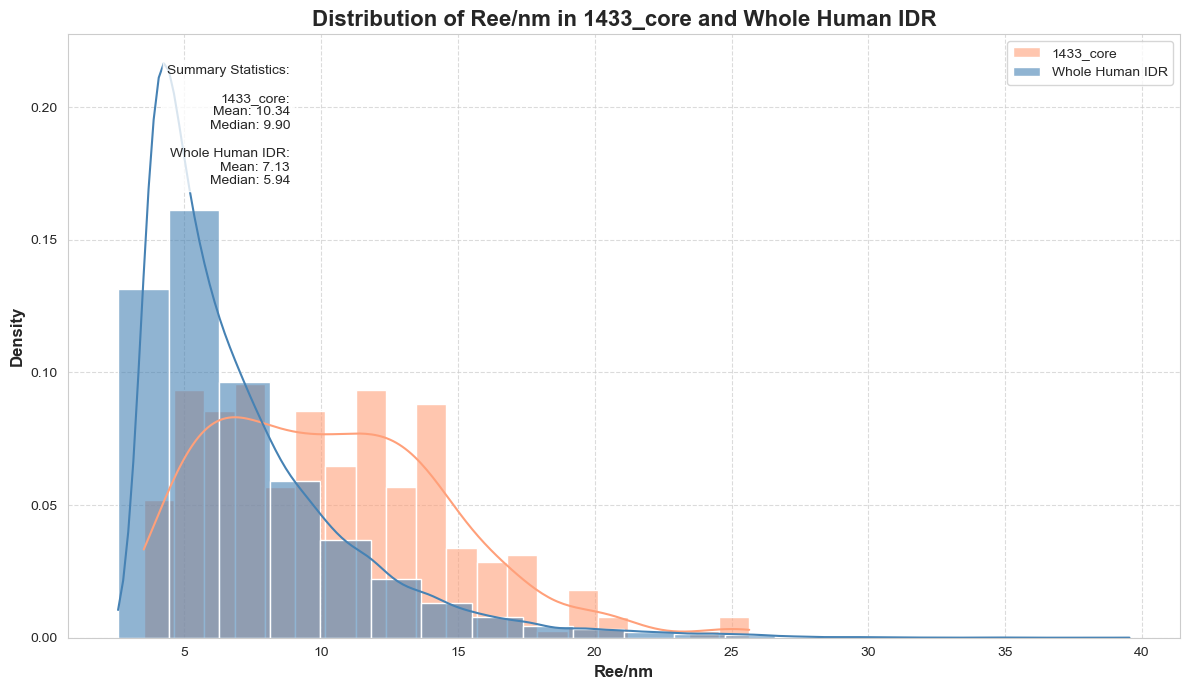

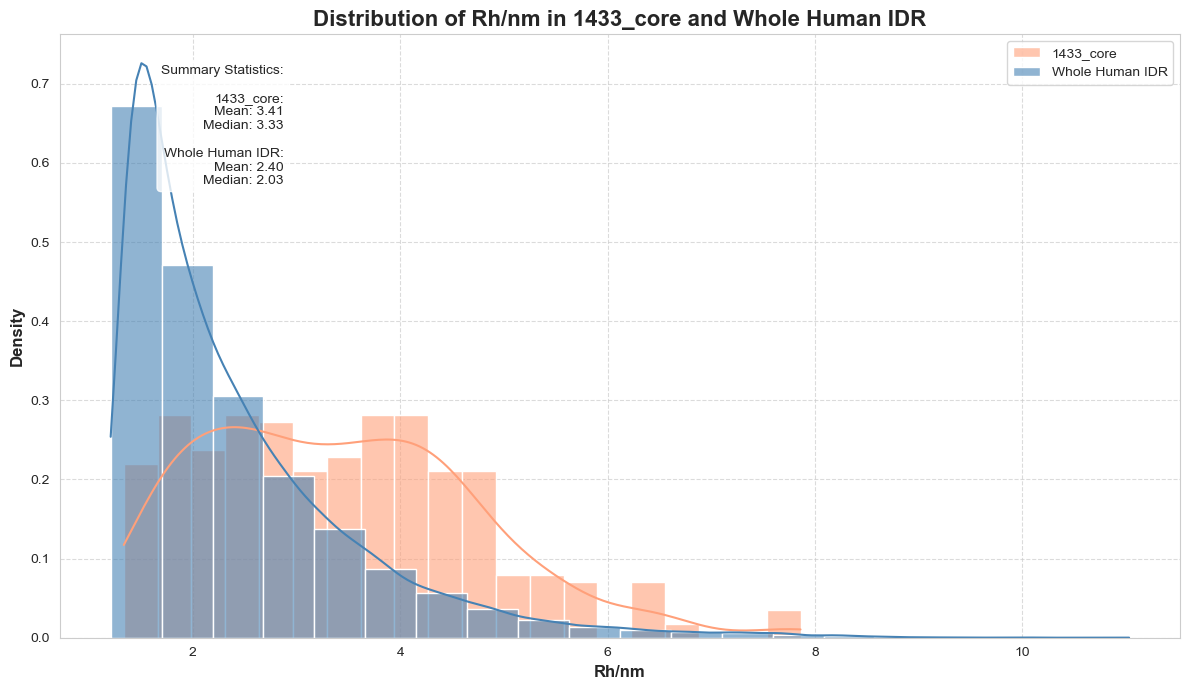

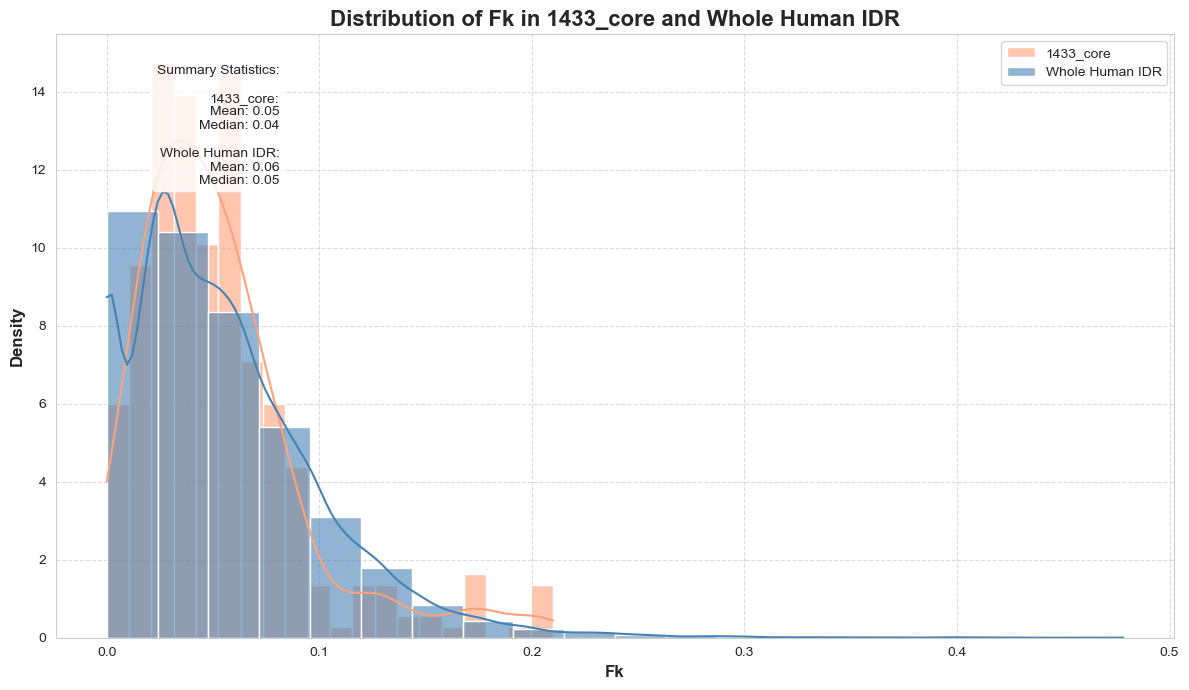

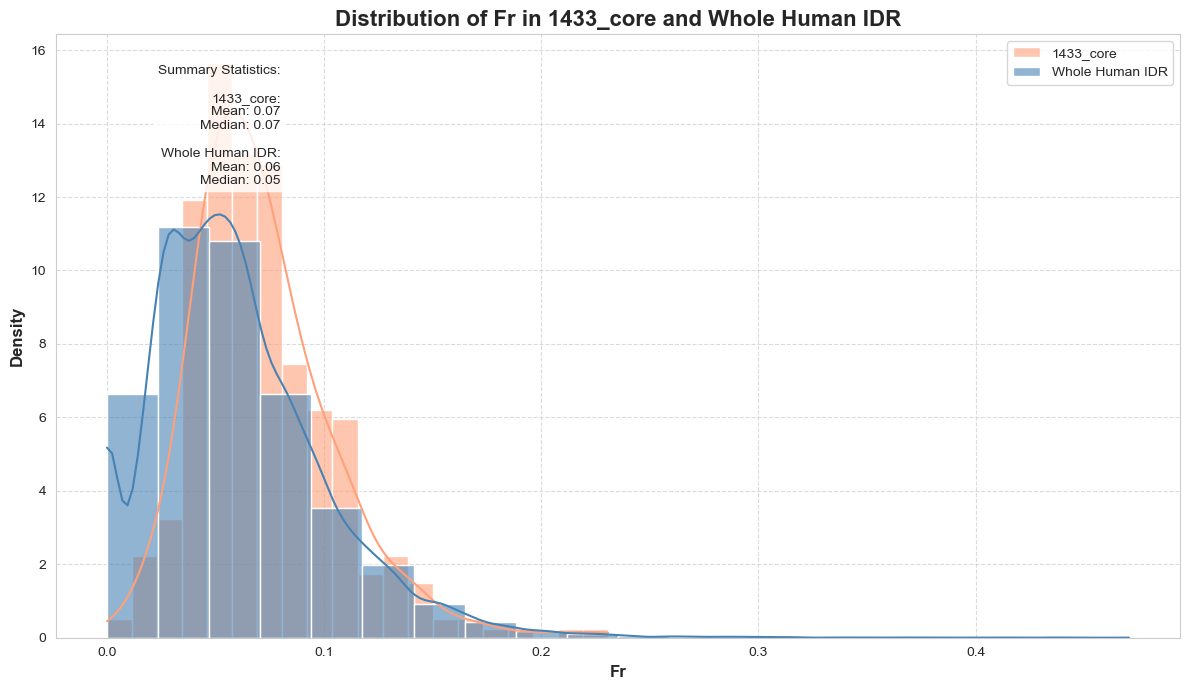

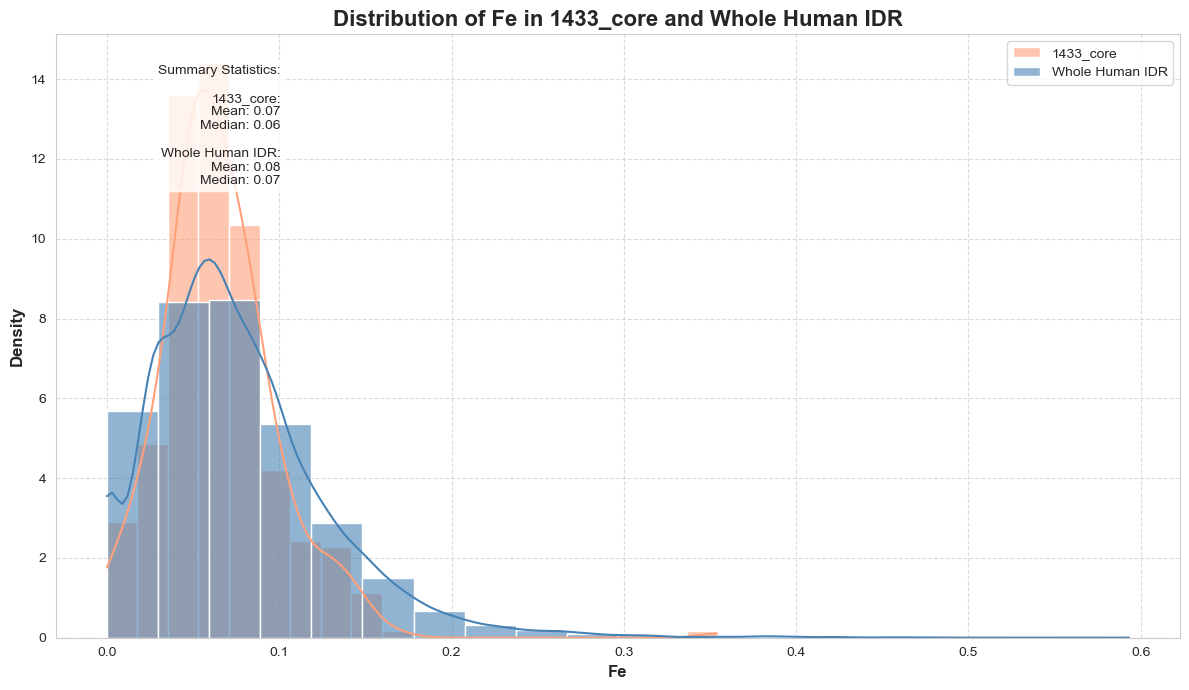

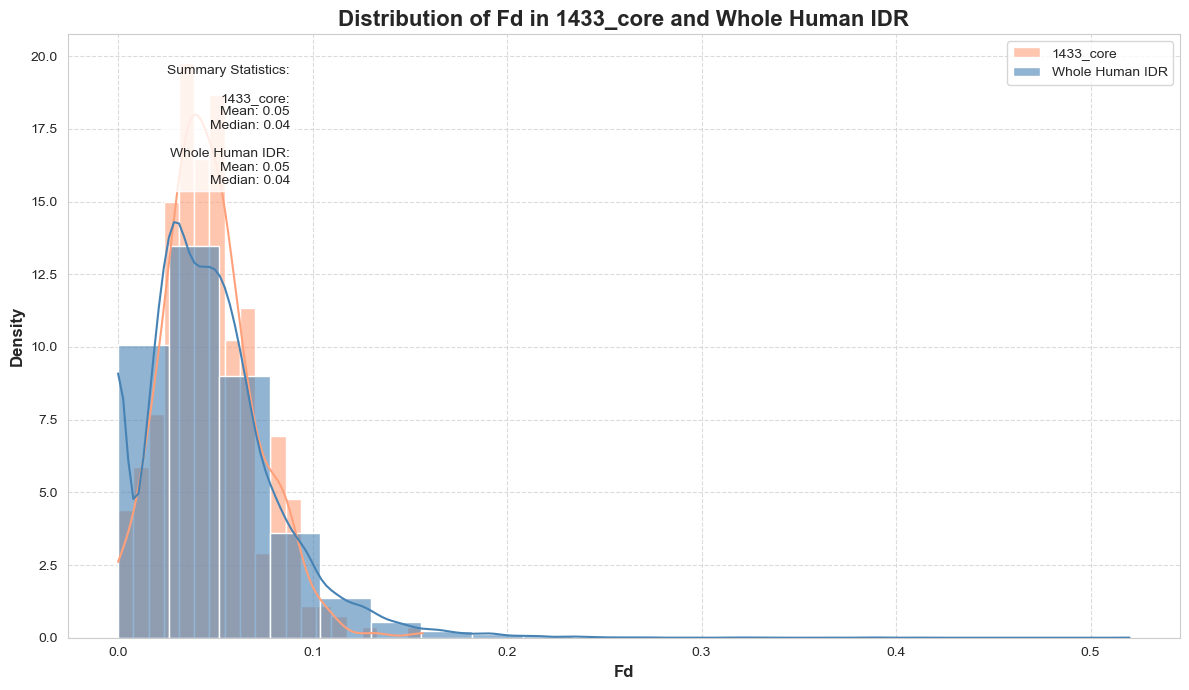

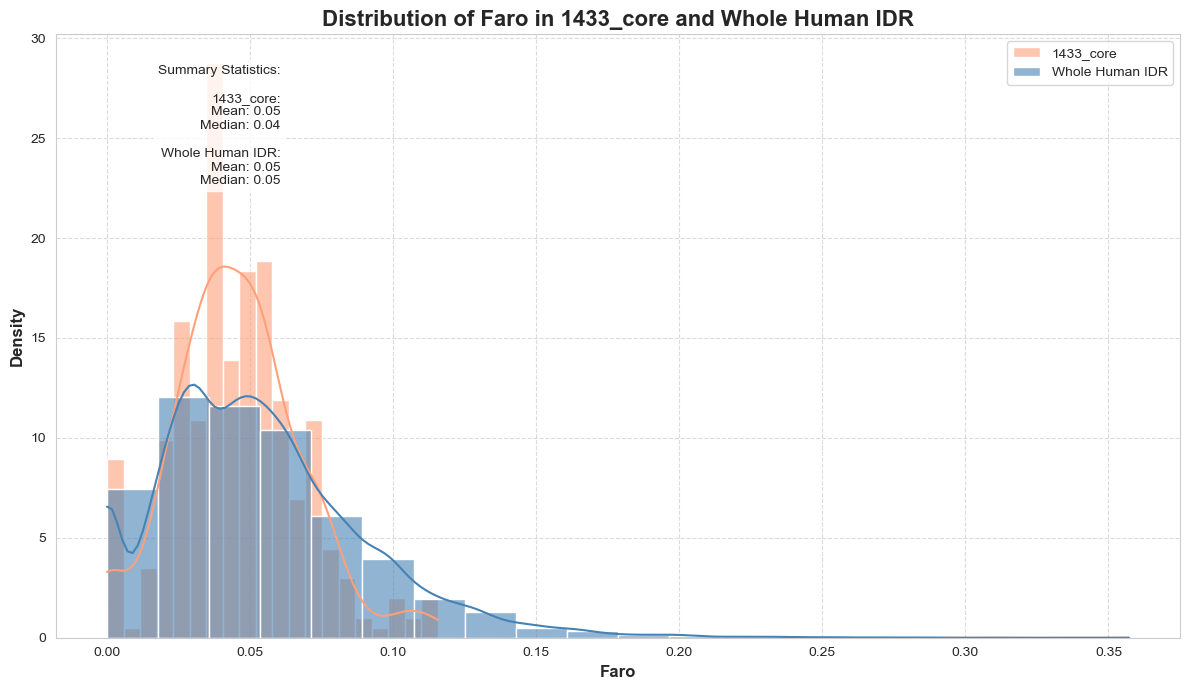

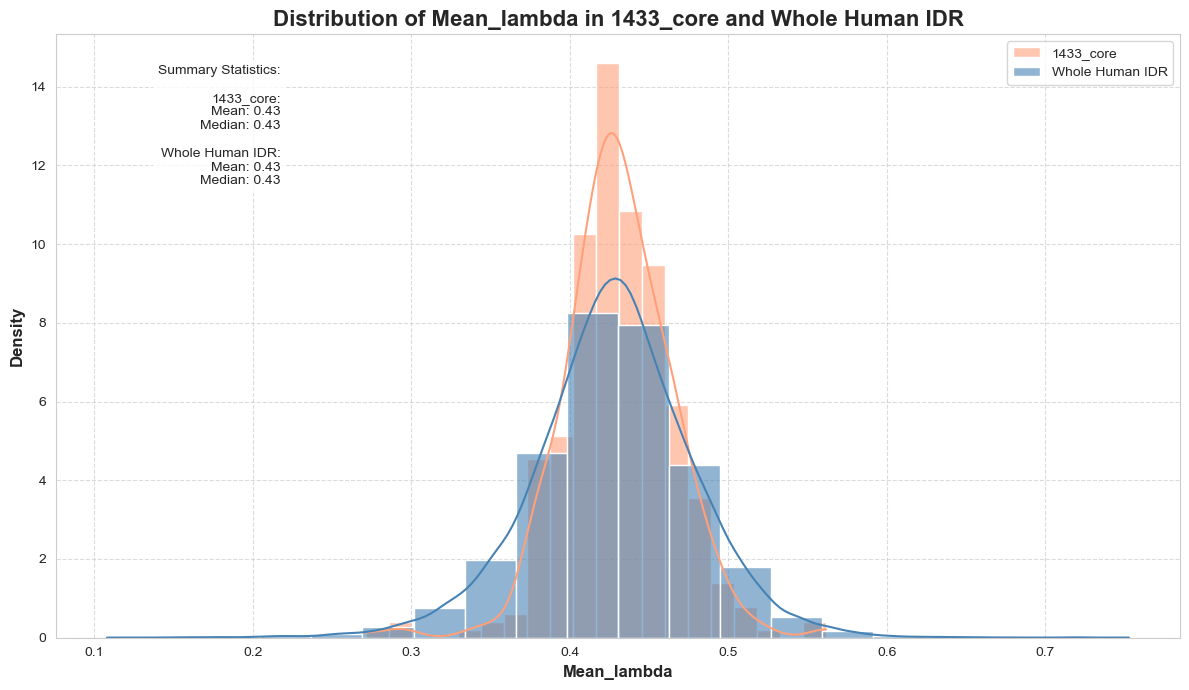

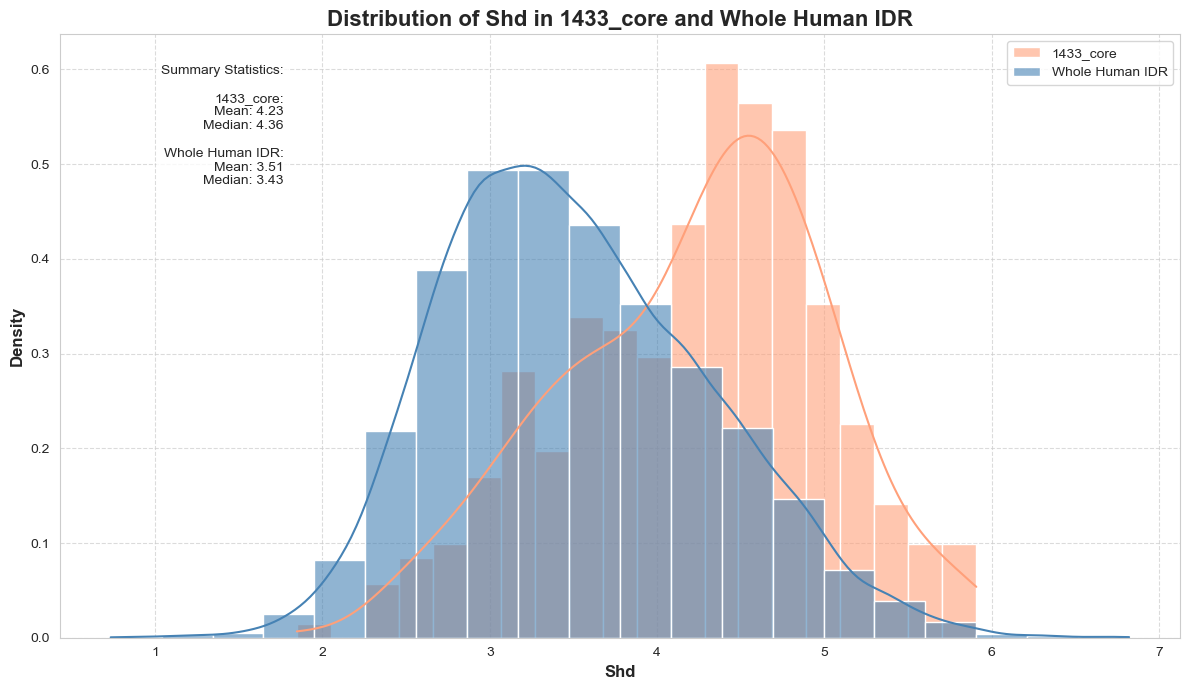

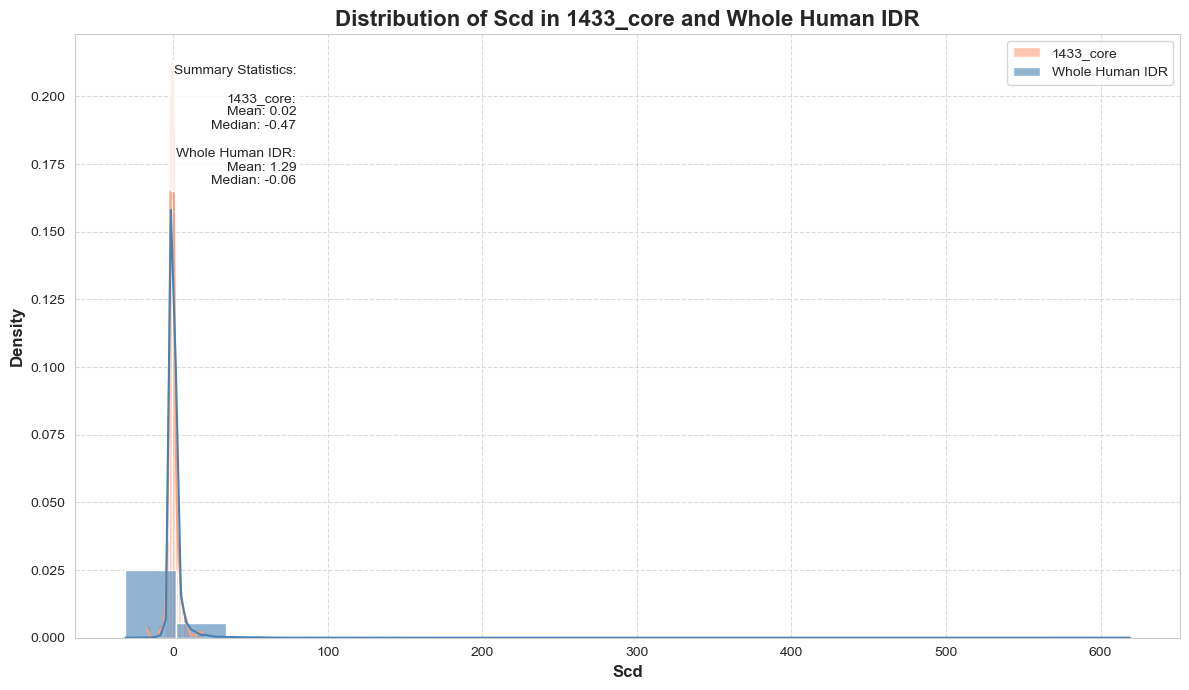

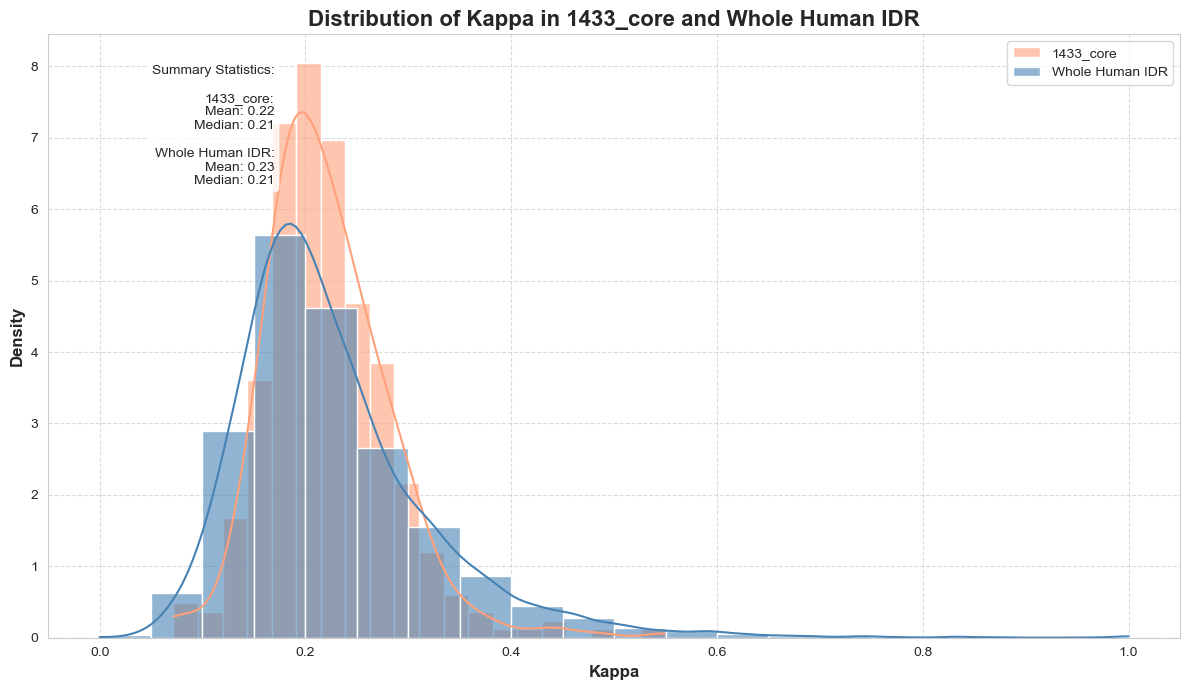

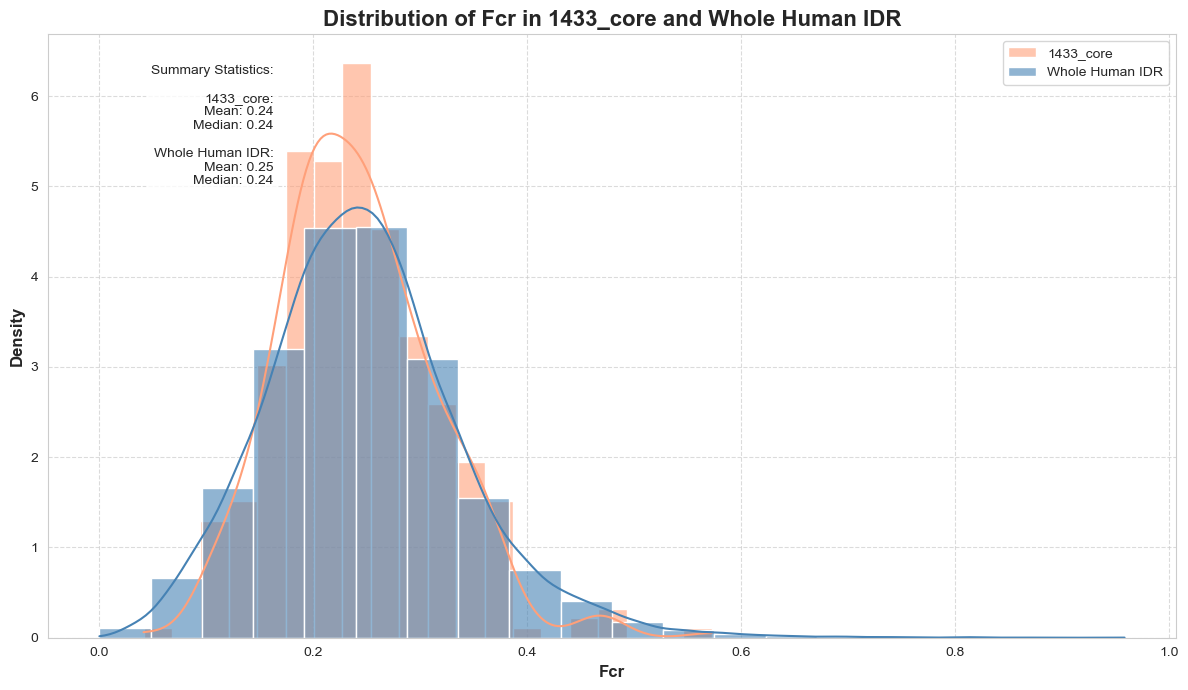

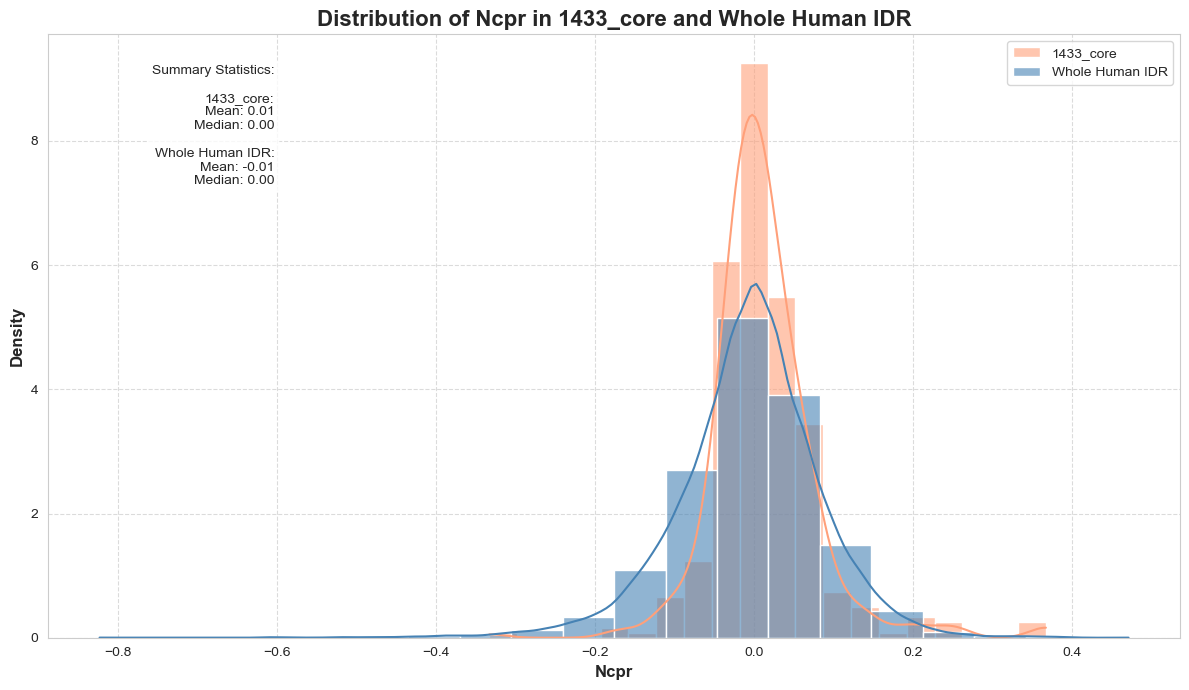

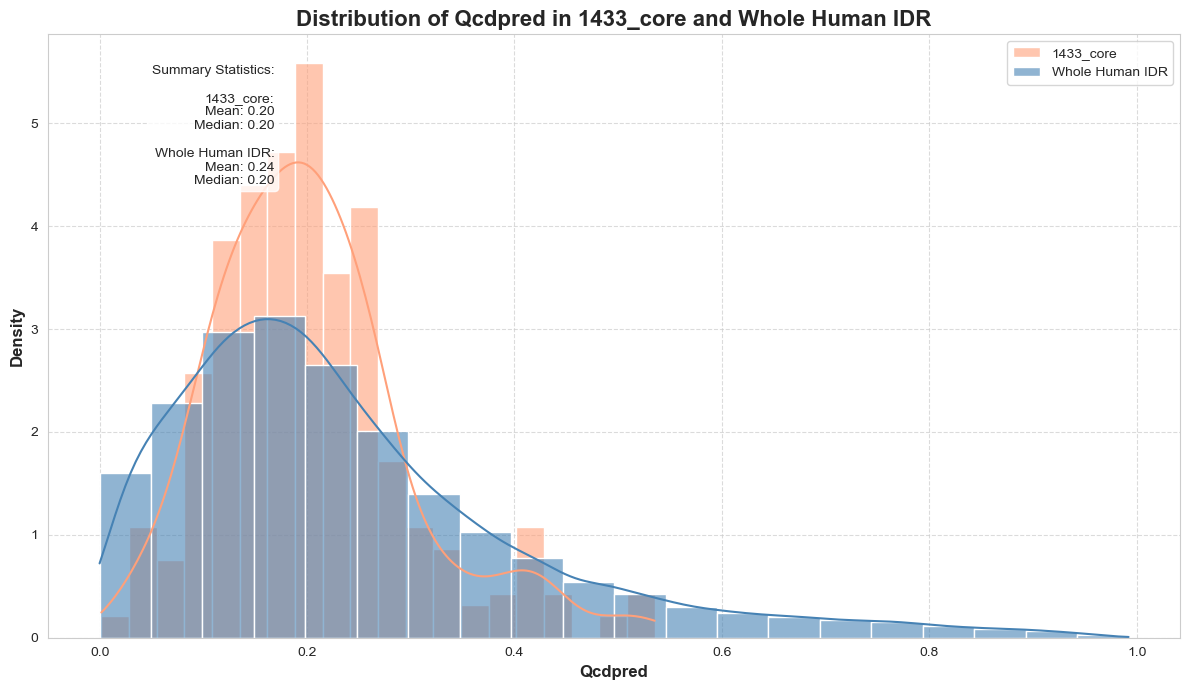

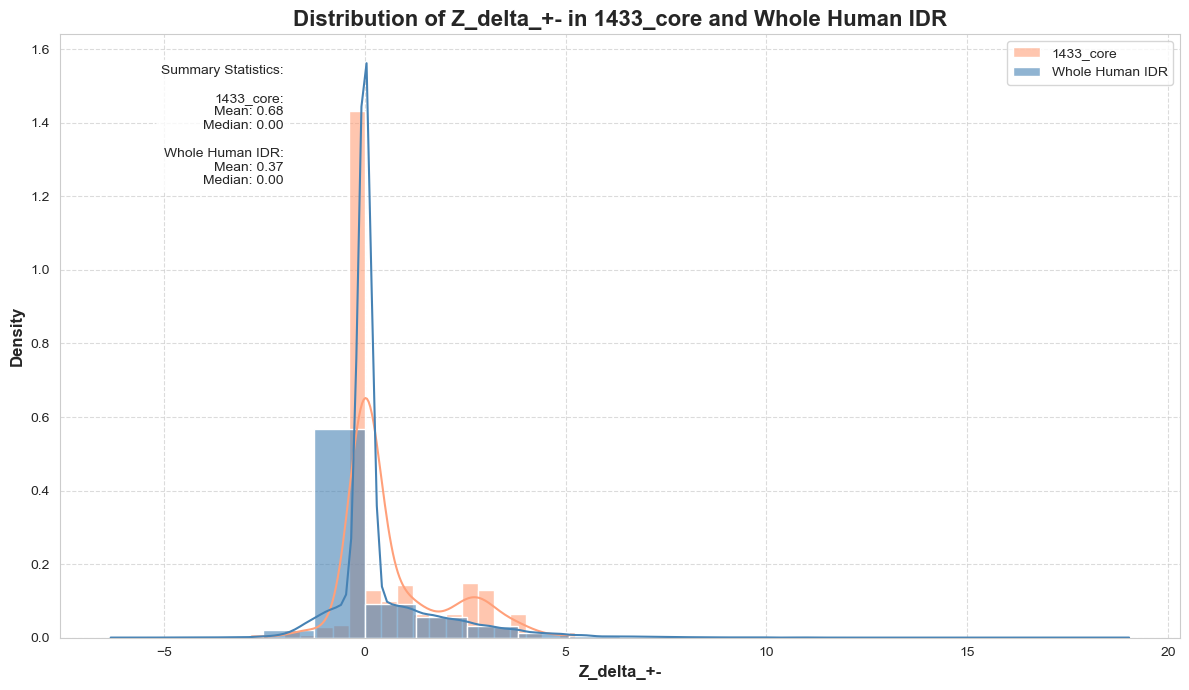

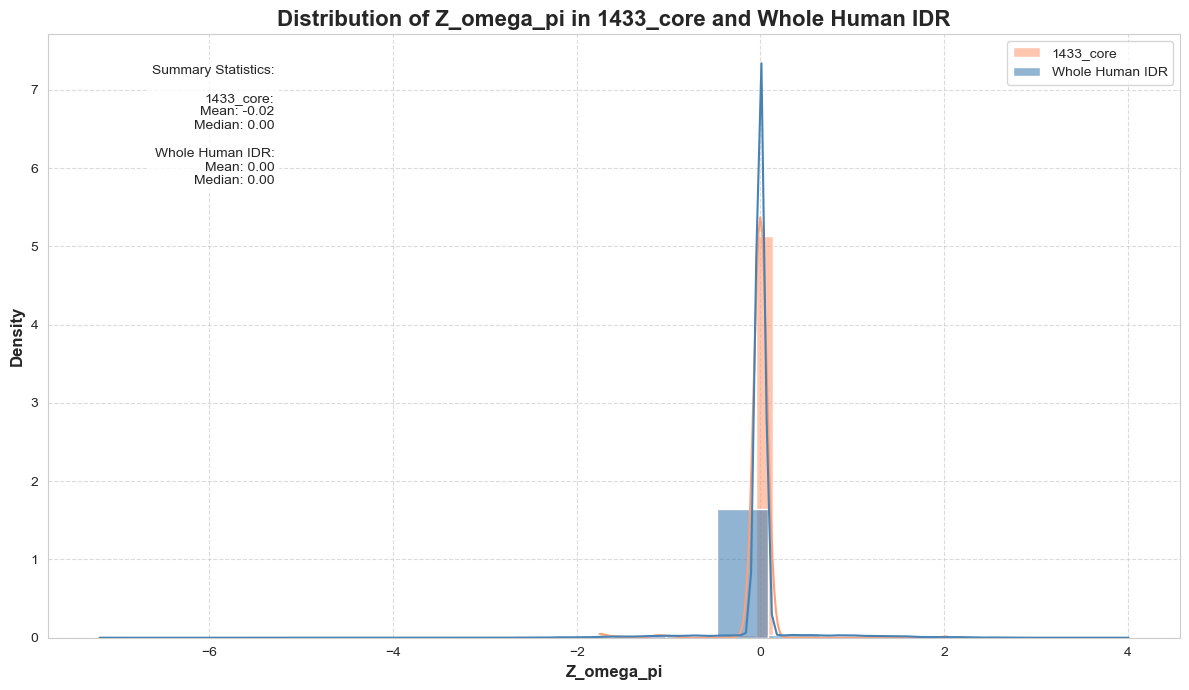

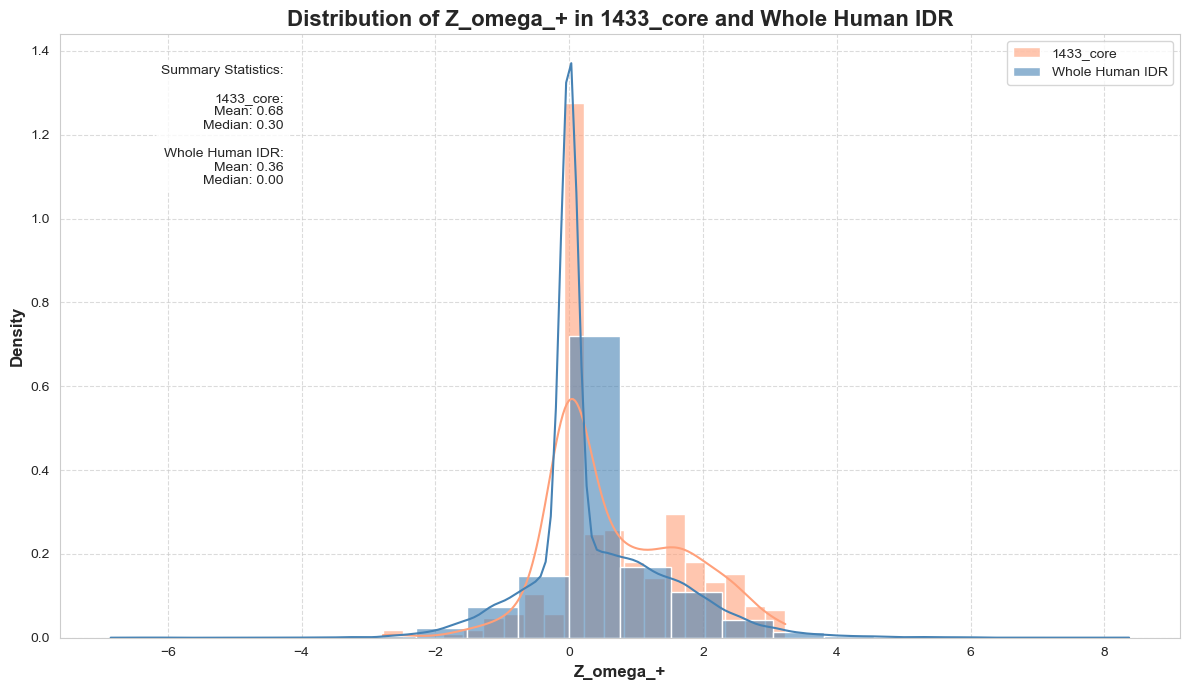

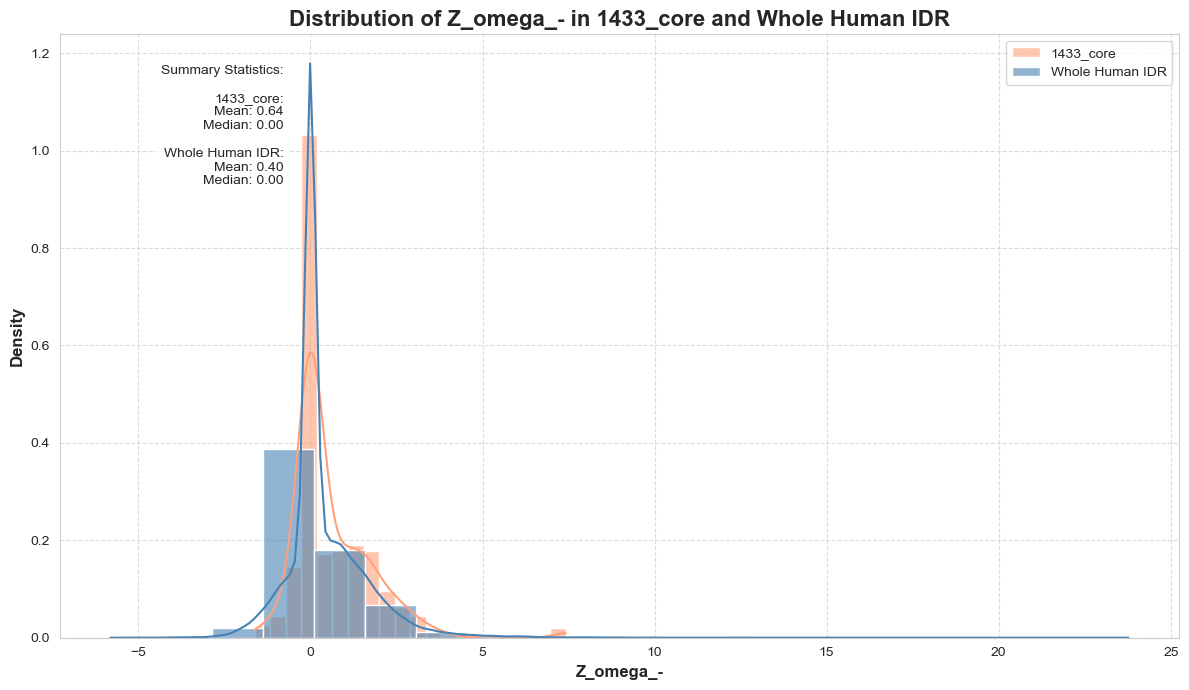

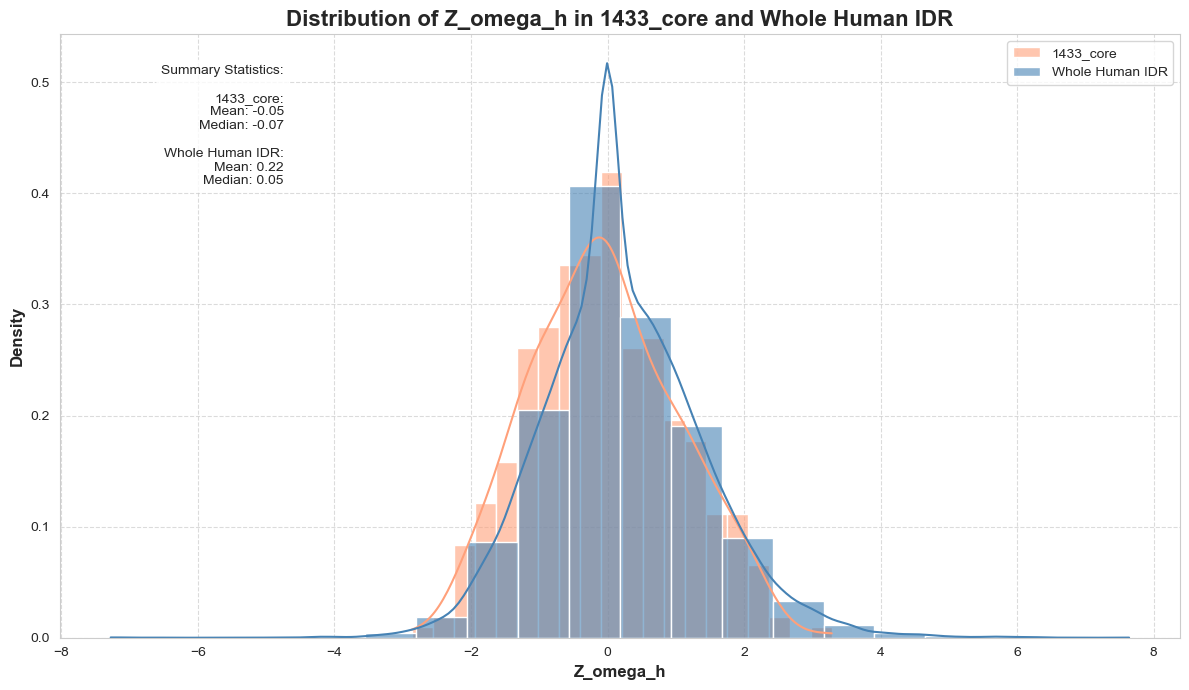

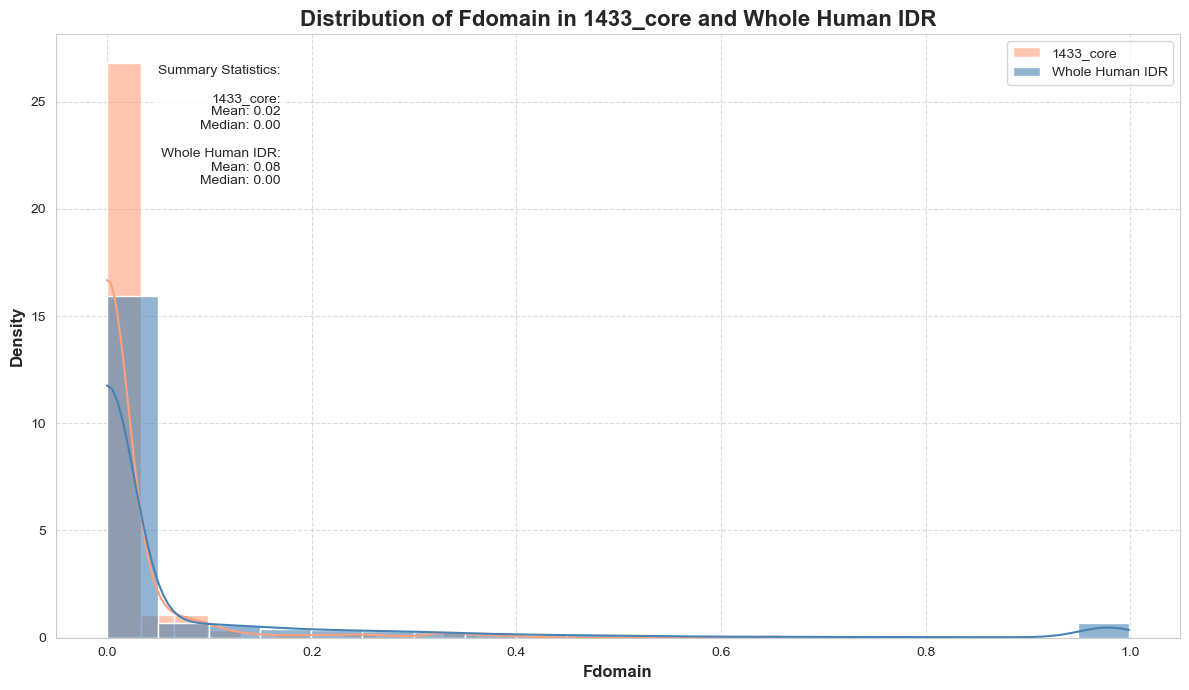

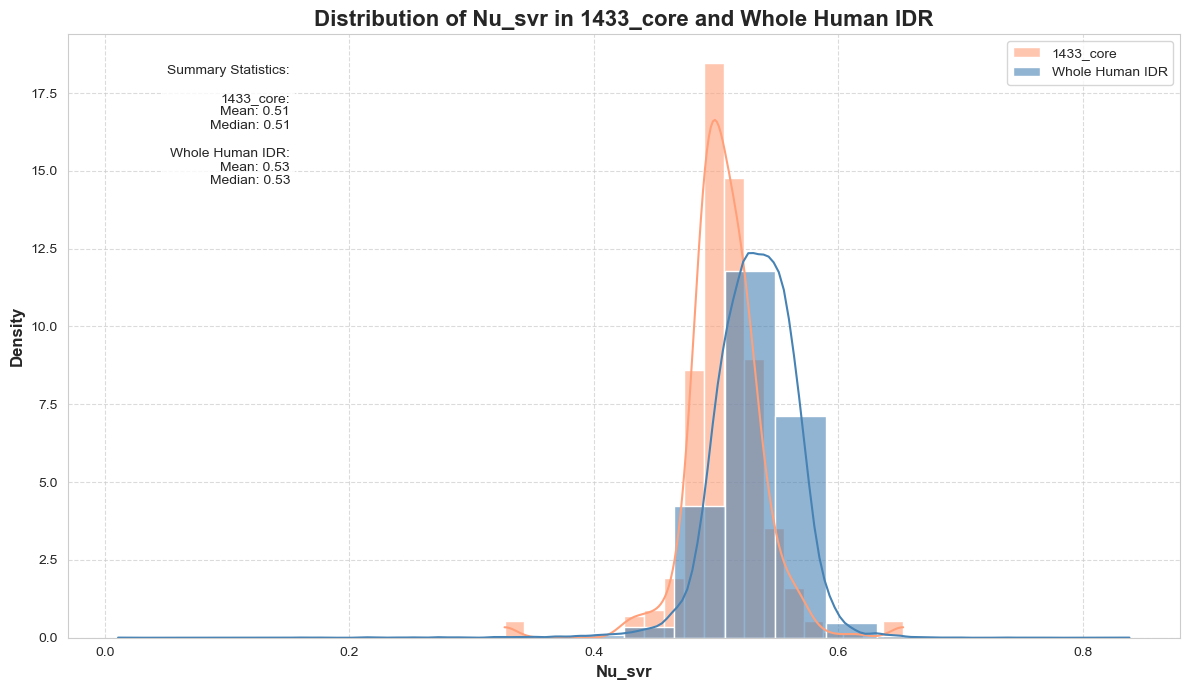

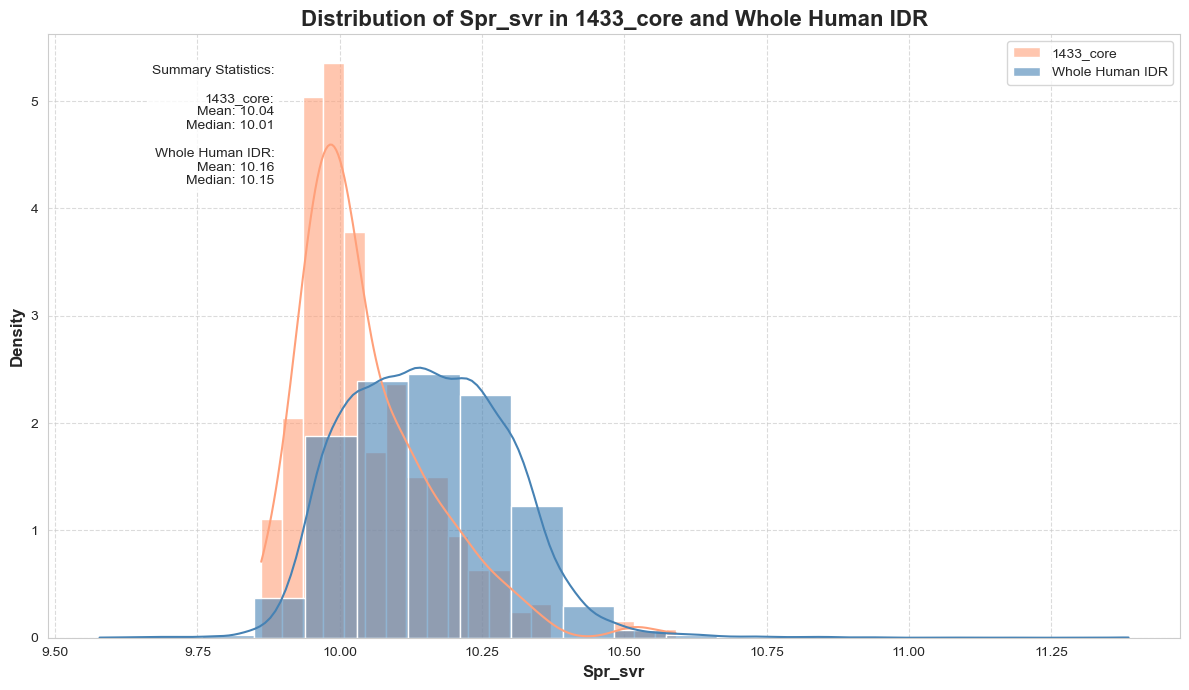

In [74]:
for column in feature:
    plot(column)

In [76]:
from scipy.stats import ks_2samp

def ks_test(column):
    # Perform Kolmogorov-Smirnov test
    statistic, p_value = ks_2samp(df_idr_uniprot_position[column], df_idr[column])
    
    # Interpret the result
    alpha = 0.05  # significance level
    print(f"KS statistic: {statistic}")
    print(f"P-value: {p_value}")
    if p_value < alpha:
        pass
        print(f"The distributions are significantly different in column: {column}.")
    else:
        # pass
        print(f"No significant difference found between the distributions in column: {column}.")

for column in feature:
    ks_test(column)

KS statistic: 0.35792365017122735
P-value: 4.52092344346049e-40
The distributions are significantly different in column: nu.
KS statistic: 0.37329377684906073
P-value: 1.1486124316673657e-43
The distributions are significantly different in column: SPR.
KS statistic: 0.26648422291851037
P-value: 4.0459515898329506e-22
The distributions are significantly different in column: ete2_Rg2.
KS statistic: 0.17594489596968704
P-value: 8.208098796418306e-10
The distributions are significantly different in column: S.
KS statistic: 0.21913960051232395
P-value: 4.989535789464341e-15
The distributions are significantly different in column: Delta.
KS statistic: 0.371384101822647
P-value: 3.2827127717602355e-43
The distributions are significantly different in column: Rg/nm.
KS statistic: 0.3749696953976423
P-value: 4.54704118397478e-44
The distributions are significantly different in column: Ree/nm.
KS statistic: 0.3745561026780179
P-value: 5.717928324355829e-44
The distributions are significantly diff

task 18: employed protein language models ESM2 to extract the IDR level embeddings for each protein in the human proteome

task 19: We then performed clustering using UMAP to visualize protein-wide sequence characteristics (Figure 2D). By plotting the 14-3-3 binding proteins on the UMAP

# 3	Domain and motif-level analysis Captures Higher-Order Features

task 20: DisoFLAG for prediction

In [ ]:
# 需要服务器处理数据

task 21: DisoFLAG for prediction compare 14-3-3 binding site with whole human protemo

In [ ]:
# 需要服务器处理数据

task 24: ANCHOR2 for prediction compare 14-3-3 binding site with whole human protemo through IUPred2A web

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/779504648.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[columnname], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/779504648.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_1433_df[columnname], label='1433 site', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/779504648.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_known_phospho_df[columnname], label='phospho site', shade=True)


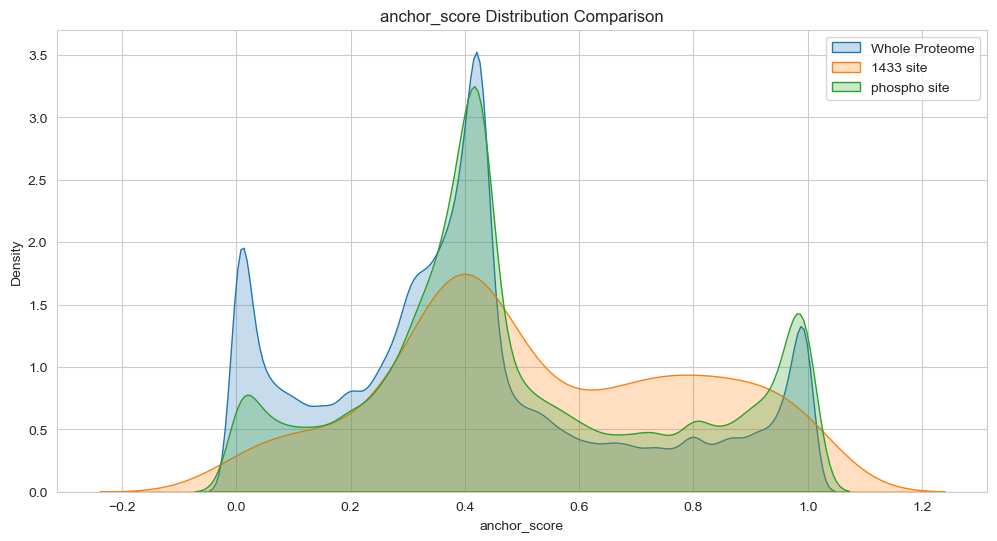

In [107]:
compare_protein_feature_distribution(konwn_1433_site, konwn_human_phosphorylated_site, st_idrscore_anchorscore_path, "anchor_score")

<p style="color:brown;">task 25: we analysis the of sequence composition of 14-3-3 binding site.using window of various lengths, a window size of 51 (n=25) can maximize the performance in the prediction of aforementioned PTM sites</p>

In [ ]:
12/27 号完成

<p style="color:brown;"> task 26: We therefore also extra the related feature using this domain size. ( 这里试试sequence-based features, physic-
ochemical property-based features and spatial mapping
information-based features,看irice的文章)用ifeature</p>

In [ ]:
def transfer_csv_data_into_fasta(csv_name, fasta_name, name_colum, sequence_column, left_flank_length=7, right_flank_length=7):
    # transfer_csv_data_into_fasta, the protein sequence contains from the left_flank to the right_flank with the 
    # phosphorylation site as center. The nomal amino acid are write in capital letter, the phosphorylation s/t are written in 
    # lower case
    df = pd.read_csv(csv_name)
    with open(fasta_name+"_"+str(left_flank_length)+"_"+str(right_flank_length)+".txt", 'w') as f:
        for index, row in df.iterrows():
            for i, char in enumerate(row[sequence_column]):
                if char == 's' or char == 't':
                    positions_st = i
                    break
            motif_sequence = row[sequence_column][positions_st-left_flank_length:positions_st+right_flank_length+1]                              
            f.write(">"+ f"{row[name_colum]}\n{motif_sequence}\n")

In [ ]:
import iFeatureOmegaCLI
import re
import sys

def amino_acid_feature_extraction(fasta_file_name, output_filename, feature_list):
    # using iFeatureOmegaCLI extract feature in the protein, in defined feature_list
    protein = iFeatureOmegaCLI.iProtein(fasta_file_name)
    concatenated_df = None
    for feature in feature_list:
        protein.get_descriptor(feature)
        result=protein.encodings
        result.set_index(result.columns[0])
        if concatenated_df is None:
            concatenated_df = result
            print(feature, concatenated_df.shape)
        else:
            length=concatenated_df.shape[1]
            concatenated_df = pd.concat([concatenated_df, result],axis=1)
            print(feature, concatenated_df.shape, concatenated_df.shape[1]-length)
            
    concatenated_df.to_csv(output_filename)

In [ ]:
import iFeatureOmegaCLI
import re
import sys

feature_list=['EAAC',
 'CKSAAP type 1','DDE', 'binary', 'AESNN3','EGAAC','CKSAAGP type 1','AAIndex','ZScale','BLOSUM62','NMBroto',
'Moran','Geary','CTDC','CTDT','CTDD','CTriad','SOCNumber','QSOrder','PAAC','APAAC','OPF_10bit','ASDC','DistancePair','ACC','PseKRAAC type 1','KNN']
amino_acid_feature_extraction("fastatraningdata_6_4.txt", "aminoacid_feature_6_4.csv", feature_list)

In [ ]:
task 27: Phospholingo predicted score download, we found 14-3-3 binding sites have higher phosphorylation ability compared with both all the known phosphorylation site and all S or T in the proteome.

In [93]:
# load 14-3-3 binding dataset
df_1433 = pd.read_csv("data/Table 1.csv")
df_1433
# select positive human sample to see the distribution
df_positive_human = df_1433[(df_1433["label"] == 1)]
df_positive_human["prot_id_position"] = df_positive_human["human homology accession"] + "_" + df_positive_human['human homology site without letter'].astype(str)
df_positive_human

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_30060/3483180552.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_positive_human["prot_id_position"] = df_positive_human["human homology accession"] + "_" + df_positive_human['human homology site without letter'].astype(str)


,human homology accession,human homology site without letter,human Site and Mutation,label,PMID,prot_id_position
0,P43681,467,S467s,1,20141511,P43681_467
1,P11362,779,S779s,1,23564461,P11362_779
2,P98177,32,T32t,1,20141511,P98177_32
3,P14136,8,S8s,1,20141511,P14136_8
4,P08151,640,S640s,1,20141511,P08151_640
...,...,...,...,...,...,...
782,Q53ET0,368,S368s,1,18626018,Q53ET0_368
783,Q05086-2,485,T485t,1,28835500,Q05086-2_485
784,P40818,718,S718s/S716A,1,17720156,P40818_718
785,P40818,718,S718s,1,17720156,P40818_718


In [97]:
# load known phosphorylation binding dataset
df_known_phospho_sites = pd.read_csv("data/konwn_human_phosphorylated_site_from_phosphosite.csv")

# Function to transform values
def transform_value(value):
    parts = value.split('_')
    if len(parts) == 3:
        return f"{parts[0]}_{parts[2]}"
    return value
    
df_known_phospho_sites["prot_id_position"] = df_known_phospho_sites["Unnamed: 0"].apply(transform_value)

df_known_phospho_sites

,Unnamed: 0,GENE,PROTEIN,ACC_ID,HU_CHR_LOC,MOD_RSD,SITE_GRP_ID,ORGANISM,MW_kD,DOMAIN,SITE_+/-7_AA,LT_LIT,MS_LIT,MS_CST,CST_CAT#,Ambiguous_Site,prot_id_position
0,P31946_T_2,YWHAB,14-3-3 beta,P31946,20q13.12,T_2,15718712,human,28.08,NaN,______MtMDksELV,NaN,3.0,1.0,NaN,0,P31946_2
1,P31946_S_6,YWHAB,14-3-3 beta,P31946,20q13.12,S_6,15718709,human,28.08,NaN,__MtMDksELVQkAk,NaN,8.0,NaN,NaN,0,P31946_6
2,P31946_T_32,YWHAB,14-3-3 beta,P31946,20q13.12,T_32,23077803,human,28.08,14-3-3,AAAMkAVtEQGHELs,NaN,NaN,1.0,NaN,0,P31946_32
3,P31946_S_39,YWHAB,14-3-3 beta,P31946,20q13.12,S_39,27442700,human,28.08,14-3-3,tEQGHELsNEERNLL,NaN,4.0,NaN,NaN,0,P31946_39
4,P31946_S_47,YWHAB,14-3-3 beta,P31946,20q13.12,S_47,4773271,human,28.08,14-3-3,NEERNLLsVAykNVV,NaN,18.0,NaN,NaN,0,P31946_47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200607,Q8IYH5_S_468,ZZZ3,ZZZ3,Q8IYH5,1p31.1,S_468,56663137,human,102.02,NaN,LNIGHLPsAKESAsQ,NaN,1.0,NaN,NaN,0,Q8IYH5_468
200608,Q8IYH5_S_474,ZZZ3,ZZZ3,Q8IYH5,1p31.1,S_474,482028,human,102.02,NaN,PsAKESAsQHITEEE,NaN,1.0,NaN,NaN,0,Q8IYH5_474
200609,Q8IYH5_S_606,ZZZ3,ZZZ3,Q8IYH5,1p31.1,S_606,23077718,human,102.02,NaN,GLPARPksPLDPKKD,NaN,6.0,4.0,NaN,0,Q8IYH5_606
200610,Q8IYH5_S_677,ZZZ3,ZZZ3,Q8IYH5,1p31.1,S_677,23077721,human,102.02,Myb_DNA-binding,yPPEEVEsRRWQKIA,NaN,NaN,1.0,NaN,0,Q8IYH5_677


In [87]:
# download the predicted score of whole human proteome from PhosphoLingo
# https://github.com/jasperzuallaert/PhosphoLingo/blob/master/predictions/preds_swissprot_ST.csv

In [94]:
phospholingo_file_path = "data/preds_swissprot_ST.csv"
current_directory = os.getcwd()
full_path = os.path.join(current_directory, phospholingo_file_path)
df_phospholingo_score = pd.read_csv(full_path)
df_phospholingo_score["prot_id_position"] = df_phospholingo_score["prot_id"] + "_" + df_phospholingo_score["position"].astype(str)
df_phospholingo_score

,prot_id,position,pred,prot_id_position
0,A0A087X1C5,54,0.051,A0A087X1C5_54
1,A0A087X1C5,70,0.039,A0A087X1C5_70
2,A0A087X1C5,76,0.252,A0A087X1C5_76
3,A0A087X1C5,93,0.020,A0A087X1C5_93
4,A0A087X1C5,98,0.061,A0A087X1C5_98
...,...,...,...,...
1230476,O60522,764,0.047,O60522_764
1230477,O60522,772,0.017,O60522_772
1230478,O60522,773,0.006,O60522_773
1230479,O60522,779,0.003,O60522_779


In [98]:
# Filter rows in df_phospholingo_score_human based on the common Uniprot IDs
common_1433_phospholingo = df_phospholingo_score[df_phospholingo_score["prot_id_position"].isin(df_positive_human["prot_id_position"])]
common_known_phospho_sites_phospholingo = df_phospholingo_score[df_phospholingo_score["prot_id_position"].isin(df_known_phospho_sites["prot_id_position"])]

In [101]:
common_1433_phospholingo

,prot_id,position,pred,prot_id_position
660,A0AVK6,396,0.966,A0AVK6_396
12472,A7KAX9,1796,0.895,A7KAX9_1796
17633,O00159,736,0.363,O00159_736
31024,O14558,16,0.814,O14558_16
35064,O14727,268,0.043,O14727_268
...,...,...,...,...
1200704,Q9Y580,204,0.932,Q9Y580_204
1214298,Q9Y6R0,305,0.983,Q9Y6R0_305
1214301,Q9Y6R0,324,0.982,Q9Y6R0_324
1220174,A2RUS2,472,0.885,A2RUS2_472


In [102]:
common_known_phospho_sites_phospholingo

,prot_id,position,pred,prot_id_position
136,A0A0B4J2F2,575,0.954,A0A0B4J2F2_575
370,A0AV02,99,0.007,A0AV02_99
417,A0AV02,469,0.088,A0AV02_469
420,A0AV02,485,0.800,A0AV02_485
421,A0AV02,488,0.454,A0AV02_488
...,...,...,...,...
1230376,O60516,69,0.897,O60516_69
1230424,O60522,373,0.010,O60522_373
1230425,O60522,389,0.038,O60522_389
1230426,O60522,391,0.153,O60522_391


In [103]:
from scipy.stats import ks_2samp


# Extract the phospho Score data from both DataFrames
phospholingo_score_1433 = common_1433_phospholingo['pred']
phospholingo_score_known_phosphosites = common_known_phospho_sites_phospholingo["pred"]

# Perform the two-sample Kolmogorov-Smirnov test
ks_statistic, p_value = ks_2samp(phospholingo_score_1433, phospholingo_score_known_phosphosites)

# Define a significance level (alpha)
alpha = 0.05

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Compare p-value to the significance level
if p_value < alpha:
    print("Reject the null hypothesis: The two distributions are significantly different.")
else:
    print("Fail to reject the null hypothesis: The two distributions are not significantly different.")

KS Statistic: 0.42419886097778114
P-value: 9.048760445898394e-68
Reject the null hypothesis: The two distributions are significantly different.


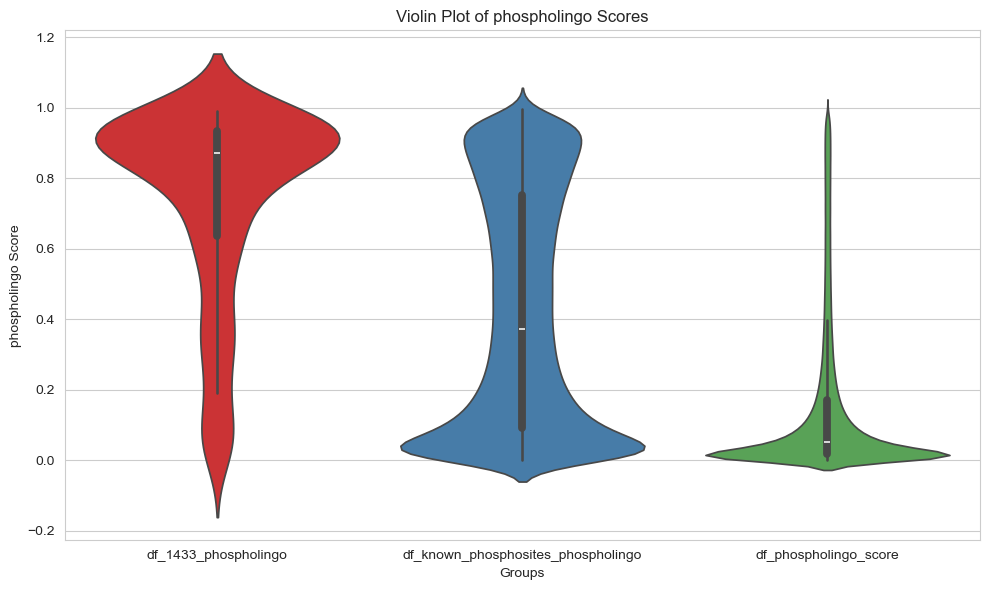

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have df_1433_picnic and df_picnic_score_human DataFrames already loaded

# Create a combined DataFrame for the violin plot
combined_data = pd.concat([common_1433_phospholingo['pred'], common_known_phospho_sites_phospholingo['pred'], df_phospholingo_score["pred"]], axis=1)
combined_data.columns = ['df_1433_phospholingo', 'df_known_phosphosites_phospholingo', 'df_phospholingo_score']

# Create a violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=combined_data, palette='Set1')
plt.title('Violin Plot of phospholingo Scores')
plt.ylabel('phospholingo Score')
plt.xlabel('Groups')

# Show the plot
plt.tight_layout()
plt.show()

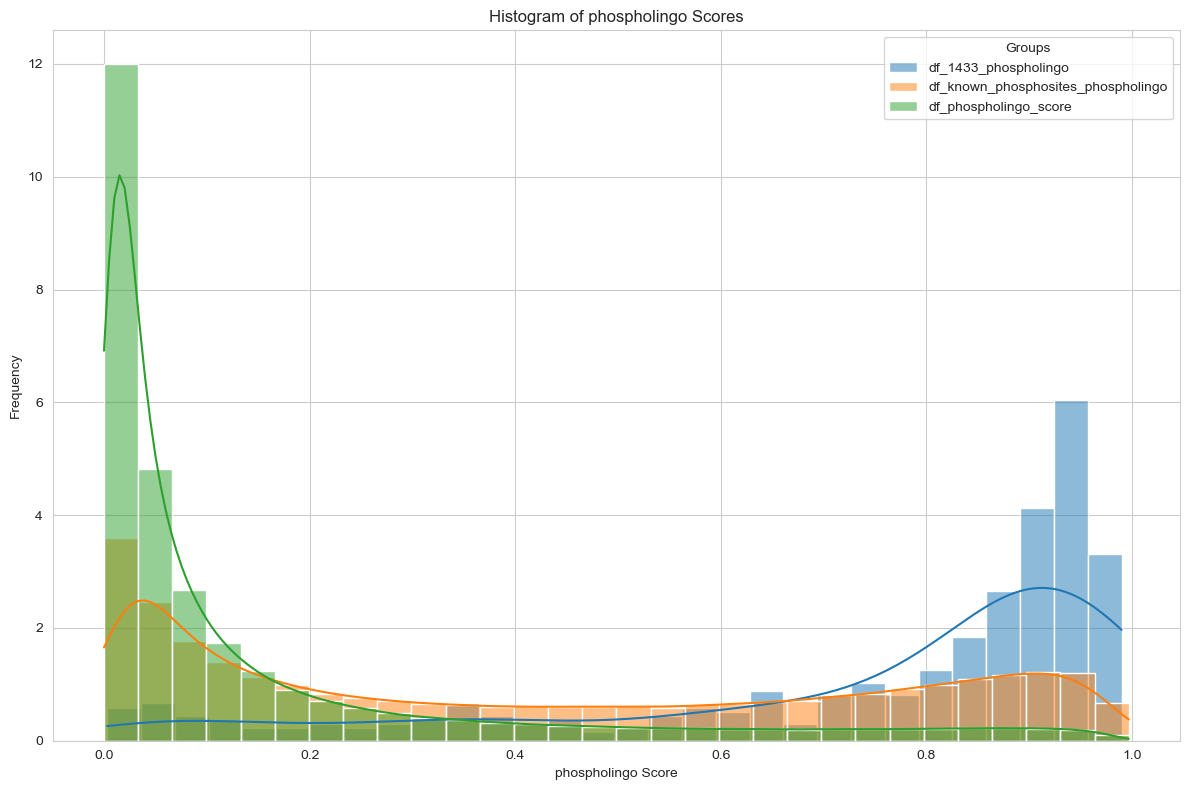

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have df_1433_picnic and df_picnic_score_human DataFrames already loaded

# Create a combined DataFrame for the histogram plot
combined_data = pd.concat([common_1433_phospholingo['pred'], common_known_phospho_sites_phospholingo['pred'], df_phospholingo_score["pred"]], axis=1)
combined_data.columns = ['df_1433_phospholingo', 'df_known_phosphosites_phospholingo', 'df_phospholingo_score']

# Create a histogram plot for each group
plt.figure(figsize=(12, 8))

# Plot histograms for each column in the combined DataFrame
for column in combined_data.columns:
    sns.histplot(combined_data[column], label=column, kde=True, bins=30, stat='density')

# Adding labels and title
plt.title('Histogram of phospholingo Scores')
plt.ylabel('Frequency')
plt.xlabel('phospholingo Score')
plt.legend(title='Groups')

# Show the plot
plt.tight_layout()
plt.show()

task 28: predict all the resident embedding of human proteome using PTM-mamba 

In [ ]:
#需要服务器

task 29: We first extract resident level of embedding in 15 aa and 100 aa of the 14-3-3 binding motif to represent the motif and domain level information, and performed clustering using UMAP to visualize characteristics of them compared with the embedding of all the other phosphorylated motif and domains. 

In [ ]:
#需要服务器

task 30: We also extract the residue embedding of 14-3-3 binding site and compare it with all S or T in the proteome and found that XXX (Figure 3B).

In [ ]:
#需要服务器